# Geometry Working Memory

https://www.biorxiv.org/content/10.64898/2026.08.31.748237v1

In [6]:
# libraries

import os
import matplotlib.pyplot as plt
import numpy as np
import pickle
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import fdrcorrection
from matplotlib.ticker import MultipleLocator, FormatStrFormatter


In [ ]:
### set paths and settings

path_root = '/path_to_local'

# settings

subjects = [f'sub_{i:02d}' for i in range(1, 50)]

time_windows = ['encode', 'maint', 's2']
pca_aligned_folder = 'pca_aligned'
surrogate_pca_aligned_folder = 'surrogate_pca_aligned'
conditions = ['update', 'inhibition']

k_start, k_end = 0, 2       # 0,2 means leading three PCs

### settings figures

yaxis_labels = 2
# if yaxis_labels = 1, labels in y-axis in encode panel
# if yaxis_labels = 2, labels in y-axis in encode and maintenance panels

xaxis_labels = True
# if True, labels in x-axis
# if False, no labels in x-axis

# CORRECT TRIALS

In [8]:
trial_type = 'correct_trials'

# Pool features (polygons, gratings) and pool loads (1, 2)


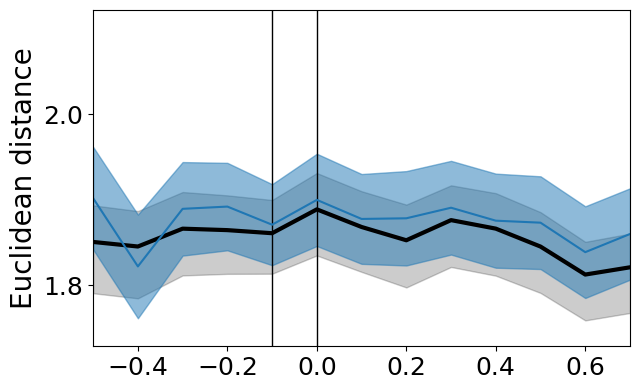

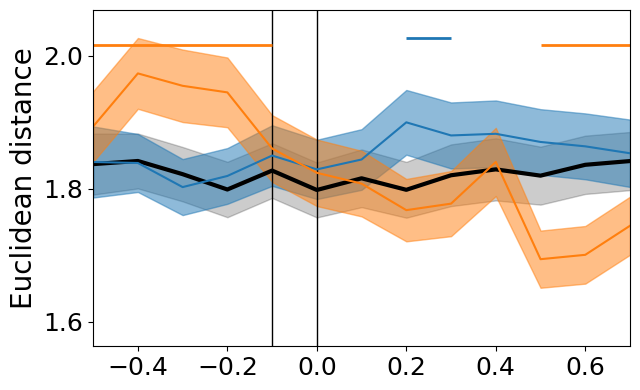

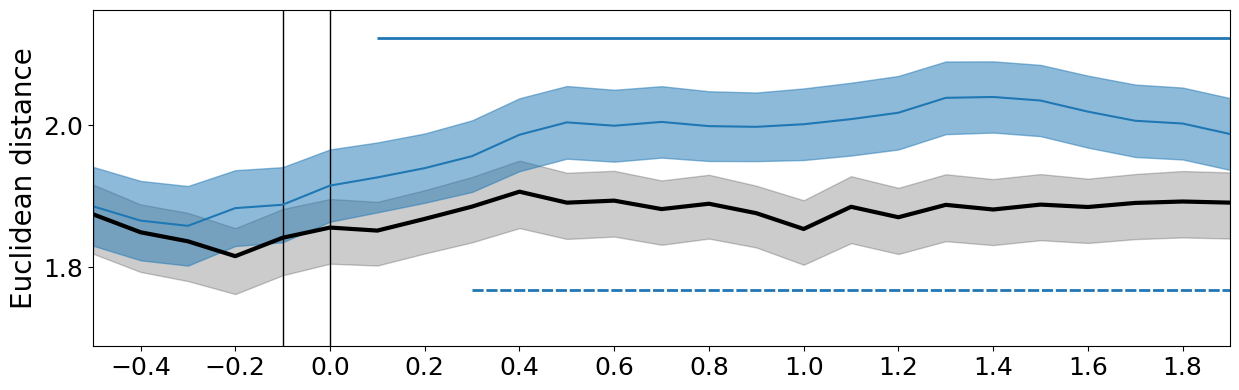

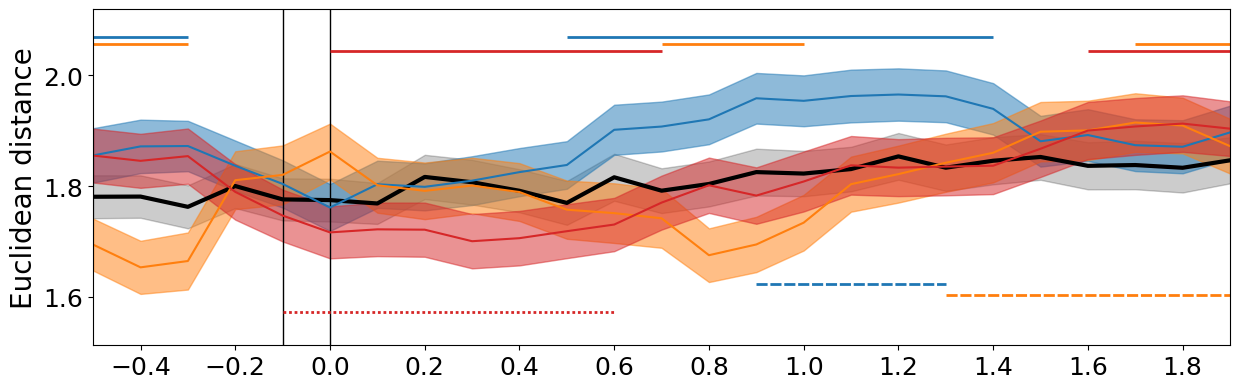

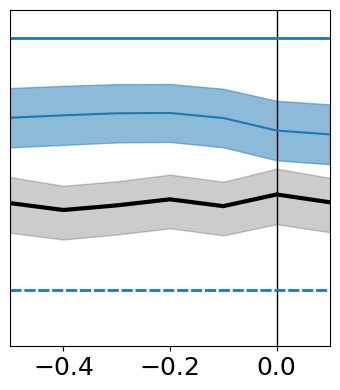

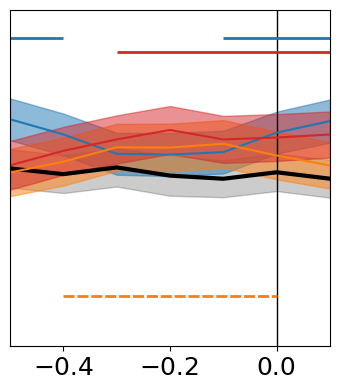

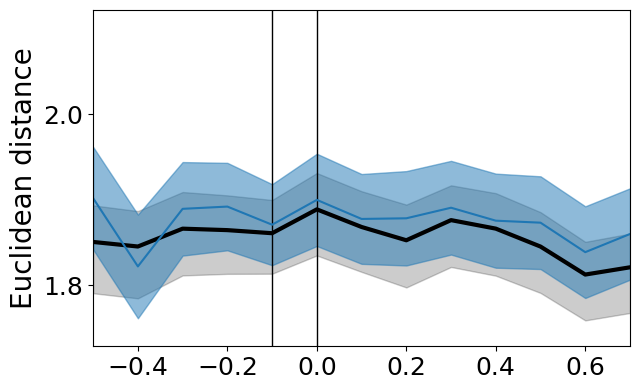

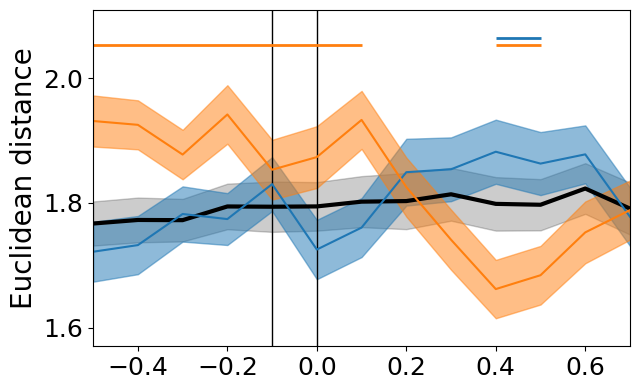

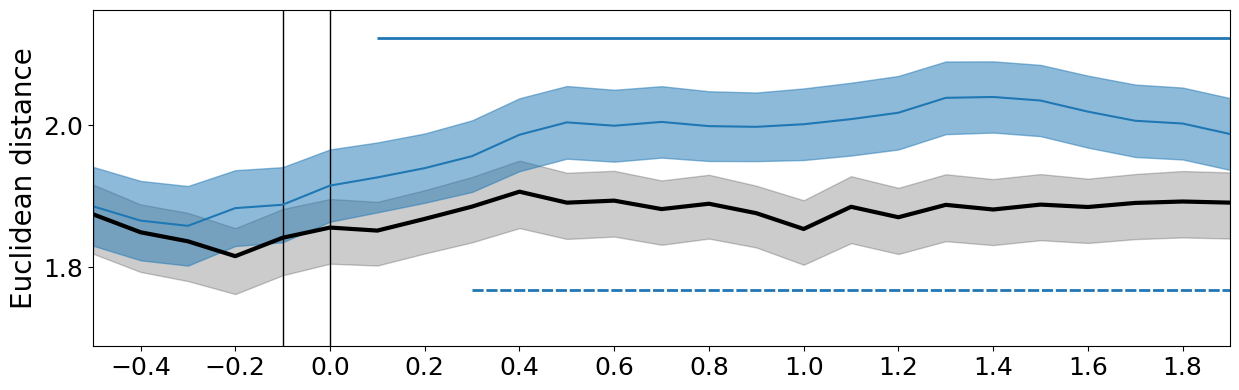

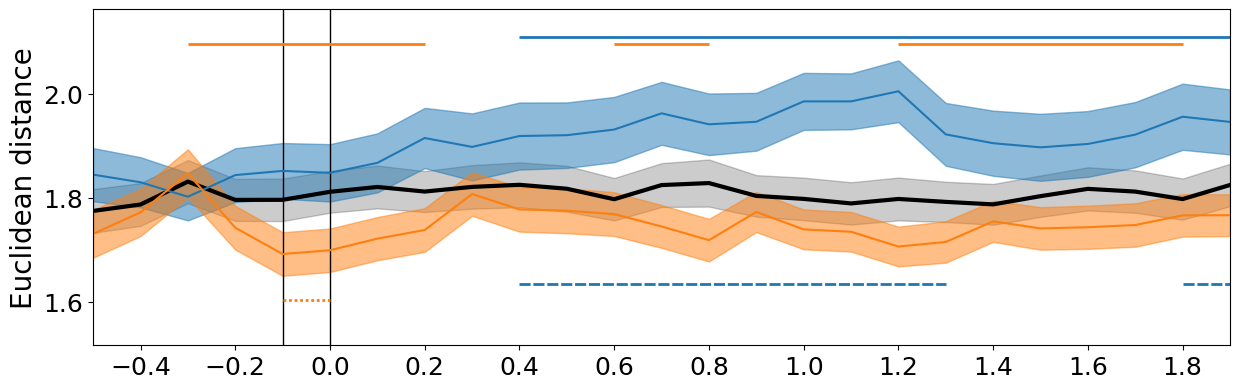

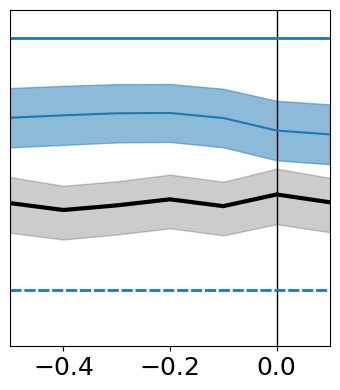

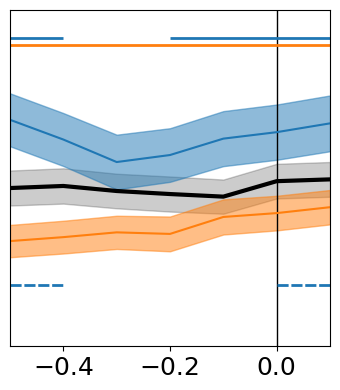

In [9]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'separability_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_01_pool_features_loads')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

### apply FDR to all the concatenated p_values (separately for each contrast)

p_values_uncorrected_list_surrogate_relevant = {}
p_values_uncorrected_list_surrogate_nonrelevant = {}
p_values_uncorrected_list_surrogate_control = {}
p_values_uncorrected_list_surrogate_nolonger = {}

p_values_uncorrected_list_cue_relevant = {}
p_values_uncorrected_list_cue_nonrelevant = {}
p_values_uncorrected_list_cue_control = {}
p_values_uncorrected_list_cue_nolonger = {}

p_values_corrected_list_surrogate_relevant = {}
p_values_corrected_list_surrogate_nonrelevant = {}
p_values_corrected_list_surrogate_control = {}
p_values_corrected_list_surrogate_nolonger = {}

p_values_corrected_list_cue_relevant = {}
p_values_corrected_list_cue_nonrelevant = {}
p_values_corrected_list_cue_control = {}
p_values_corrected_list_cue_nolonger = {}

t_values_list_cue_relevant = {}
t_values_list_cue_nonrelevant = {}
t_values_list_cue_control = {}
t_values_list_cue_nolonger = {}

for condition_i in conditions:

    for load_i in [12]:

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            load_ii = 1
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_load1 = np.concat((data_control_orientation, data_control_shape), axis=0)
            load_ii = 2
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_load2 = np.concat((data_control_orientation, data_control_shape), axis=0)
            data_control = np.concat((data_load1, data_load2), axis=0)

            # relevant
            load_ii = 1
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_relevant_load1 = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)
            load_ii = 2
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_relevant_load2 = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)
            data_relevant = np.concat((data_relevant_load1, data_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_nonrelevant_load1 = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)
            load_ii = 2
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_nonrelevant_load2 = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)
            data_nonrelevant = np.concat((data_nonrelevant_load1, data_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                data_nolonger_load1 = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)
                load_ii = 2
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                data_nolonger_load2 = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)
                data_nolonger = np.concat((data_nolonger_load1, data_nolonger_load2), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            load_ii = 1
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_load1 = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)
            load_ii = 2
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_load2 = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)
            surrogate_control = np.concat((surrogate_load1, surrogate_load2), axis=0)

            # relevant
            load_ii = 1
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_relevant_load1 = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)
            load_ii = 2
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_relevant_load2 = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)
            surrogate_relevant = np.concat((surrogate_relevant_load1, surrogate_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_nonrelevant_load1 = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)
            load_ii = 2
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_nonrelevant_load2 = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_load1, surrogate_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                surrogate_nolonger_load1 = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)
                load_ii = 2
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                surrogate_nolonger_load2 = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)
                surrogate_nolonger = np.concat((surrogate_nolonger_load1, surrogate_nolonger_load2), axis=0)








            # -----------------------------------------
            # Run statistical tests - surrogate effect
            # -----------------------------------------
 
            ## control
            p_values = []
            for t in range(data_control.shape[1]):
                _, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## relevant
            p_values = []
            for t in range(data_relevant.shape[1]):
                _, p = ttest_rel(data_relevant[:, t], surrogate_relevant[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## nonrelevant
            p_values = []
            for t in range(data_nonrelevant.shape[1]):
                _, p = ttest_rel(data_nonrelevant[:, t], surrogate_nonrelevant[:, t])
                p_values.append(p)

            # pool p-values 
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            if condition_i == 'update':

                ## nolongerrelevant
                p_values = []
                for t in range(data_nolonger.shape[1]):
                    _, p = ttest_rel(data_nolonger[:, t], surrogate_nolonger[:, t])
                    p_values.append(p)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                p_values_uncorrected_list_surrogate_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values


            # -----------------------------------
            # Run statistical tests - cue effect
            # -----------------------------------

            if time_window == 'encode':

                data_encode_avg_control = data_control.copy()
                data_encode_avg_relevant = data_relevant.copy()
                data_encode_avg_nonrelevant = data_nonrelevant.copy()
                if condition_i == 'update':
                    data_encode_avg_nolonger = data_nolonger.copy()

            if time_window == 'maint':

                data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)
                data_encode_avg_control = np.mean(data_encode_avg_control[:,5:18], axis=1)

                data_encode_avg_relevant = np.concatenate((data_encode_avg_relevant, data_relevant), axis=1)
                data_encode_avg_nonrelevant = np.concatenate((data_encode_avg_nonrelevant, data_nonrelevant), axis=1)

                data_encode_avg_relevant = np.mean(data_encode_avg_relevant[:,5:18], axis=1)
                data_encode_avg_nonrelevant = np.mean(data_encode_avg_nonrelevant[:,5:18], axis=1)

                if condition_i == 'update':
                    data_encode_avg_nolonger = np.concatenate((data_encode_avg_nolonger, data_nolonger), axis=1)
                    data_encode_avg_nolonger = np.mean(data_encode_avg_nolonger[:,5:18], axis=1)

            if time_window != 'encode': # not used here

                ## control

                p_values = []
                t_values = []
                for t in range(data_control.shape[1]):
                    t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = t_values
                
                ## relevant

                p_values = []
                t_values = []
                for t in range(data_relevant.shape[1]):
                    t, p = ttest_rel(data_relevant[:, t], data_encode_avg_relevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values

                ## non-relevant

                p_values = []
                t_values = []
                for t in range(data_nonrelevant.shape[1]):
                    t, p = ttest_rel(data_nonrelevant[:, t], data_encode_avg_nonrelevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values


                ## nolonger

                if condition_i == 'update':

                    p_values = []
                    t_values = []
                    for t in range(data_nolonger.shape[1]):
                        t, p = ttest_rel(data_nolonger[:, t], data_encode_avg_nolonger)
                        p_values.append(p)
                        t_values.append(t)

                    # pool p-values
                    p_values = np.array(p_values)
                    p_values = np.nan_to_num(p_values, nan=1.0)

                    # pool t-values
                    t_values = np.array(t_values)
                    t_values = np.nan_to_num(t_values, nan=1.0)

                    p_values_uncorrected_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                    t_values_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = t_values





##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [12]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        for time_window in time_windows:

            base_key = f"{time_window}_{condition_i}_{load_i}"

            # control
            vals = p_values_uncorrected_list_surrogate_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))
                
            # relevant
            vals = p_values_uncorrected_list_surrogate_relevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("relevant", base_key, len(vals)))

            # nonrelevant
            vals = p_values_uncorrected_list_surrogate_nonrelevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("nonrelevant", base_key, len(vals)))


            # nolonger
            if condition_i == 'update':

                vals = p_values_uncorrected_list_surrogate_nolonger[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_surrogate_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_surrogate_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_surrogate_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_surrogate_nolonger[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [12]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        # vectorize uncorrected p_values
        for time_window in time_windows:

            if time_window != 'encode':

                base_key = f"{time_window}_{condition_i}_{load_i}"

                # control
                vals = p_values_uncorrected_list_cue_control[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("control", base_key, len(vals)))

                # relevant
                vals = p_values_uncorrected_list_cue_relevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("relevant", base_key, len(vals)))

                # nonrelevant
                vals = p_values_uncorrected_list_cue_nonrelevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nonrelevant", base_key, len(vals)))

                # nolonger
                if condition_i == 'update':

                    vals = p_values_uncorrected_list_cue_nolonger[base_key]
                    p_values_uncorrected.extend(vals)
                    keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_cue_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_cue_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_cue_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_cue_nolonger[key] = corrected_vals



















### plots

for condition_i in conditions:

    for load_i in [12]:

        # find common y-axis limits

        global_ymin = np.inf
        global_ymax = -np.inf

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            load_ii = 1
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_load1 = np.concat((data_control_orientation, data_control_shape), axis=0)
            load_ii = 2
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_load2 = np.concat((data_control_orientation, data_control_shape), axis=0)
            data_control = np.concat((data_load1, data_load2), axis=0)

            # relevant
            load_ii = 1
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_relevant_load1 = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)
            load_ii = 2
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_relevant_load2 = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)
            data_relevant = np.concat((data_relevant_load1, data_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_nonrelevant_load1 = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)
            load_ii = 2
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_nonrelevant_load2 = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)
            data_nonrelevant = np.concat((data_nonrelevant_load1, data_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                data_nolonger_load1 = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)
                load_ii = 2
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                data_nolonger_load2 = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)
                data_nolonger = np.concat((data_nolonger_load1, data_nolonger_load2), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            load_ii = 1
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_load1 = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)
            load_ii = 2
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_load2 = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)
            surrogate_control = np.concat((surrogate_load1, surrogate_load2), axis=0)

            # relevant
            load_ii = 1
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_relevant_load1 = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)
            load_ii = 2
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_relevant_load2 = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)
            surrogate_relevant = np.concat((surrogate_relevant_load1, surrogate_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_nonrelevant_load1 = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)
            load_ii = 2
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_nonrelevant_load2 = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_load1, surrogate_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                surrogate_nolonger_load1 = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)
                load_ii = 2
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                surrogate_nolonger_load2 = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)
                surrogate_nolonger = np.concat((surrogate_nolonger_load1, surrogate_nolonger_load2), axis=0)



            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])


            # control limits

            ymax = np.max(((mean_control + std_control).max(), (mean_control_surrogate + std_control_surrogate).max()))
            ymin = np.min(((mean_control - std_control).min(), (mean_control_surrogate - std_control_surrogate).min()))

            if time_window == 'encode':

                global_ymin_control = ymin
                global_ymax_control = ymax

            else:

                if ymax > global_ymax_control:
                    global_ymax_control = ymax
                if ymin < global_ymin_control:
                    global_ymin_control = ymin

            # experimental limits

            if condition_i == 'update':

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_nolonger + std_nolonger).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max(), (mean_nolonger_surrogate + std_nolonger_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_nolonger - std_nolonger).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min(), (mean_nolonger_surrogate - std_nolonger_surrogate).min()))

            else:

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min()))

            if time_window == 'encode':

                global_ymin = ymin
                global_ymax = ymax

            else:

                if ymax > global_ymax:
                    global_ymax = ymax
                if ymin < global_ymin:
                    global_ymin = ymin


        # now, pass the code to do the actual plots

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            load_ii = 1
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_load1 = np.concat((data_control_orientation, data_control_shape), axis=0)
            load_ii = 2
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_load2 = np.concat((data_control_orientation, data_control_shape), axis=0)
            data_control = np.concat((data_load1, data_load2), axis=0)

            # relevant
            load_ii = 1
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_relevant_load1 = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)
            load_ii = 2
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_relevant_load2 = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)
            data_relevant = np.concat((data_relevant_load1, data_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_nonrelevant_load1 = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)
            load_ii = 2
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_nonrelevant_load2 = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)
            data_nonrelevant = np.concat((data_nonrelevant_load1, data_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                data_nolonger_load1 = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)
                load_ii = 2
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                data_nolonger_load2 = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)
                data_nolonger = np.concat((data_nolonger_load1, data_nolonger_load2), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            load_ii = 1
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_load1 = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)
            load_ii = 2
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_load2 = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)
            surrogate_control = np.concat((surrogate_load1, surrogate_load2), axis=0)

            # relevant
            load_ii = 1
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_relevant_load1 = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)
            load_ii = 2
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_relevant_load2 = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)
            surrogate_relevant = np.concat((surrogate_relevant_load1, surrogate_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_nonrelevant_load1 = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)
            load_ii = 2
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_nonrelevant_load2 = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_load1, surrogate_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                surrogate_nolonger_load1 = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)
                load_ii = 2
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                surrogate_nolonger_load2 = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)
                surrogate_nolonger = np.concat((surrogate_nolonger_load1, surrogate_nolonger_load2), axis=0)


            # ------------------------------------------
            # FDR corrected p-values - surrogate effect
            # ------------------------------------------

            ## relevant

            p_values_corrected_list = p_values_corrected_list_surrogate_relevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_relevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## nonrelevant

            p_values_corrected_list = p_values_corrected_list_surrogate_nonrelevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_nonrelevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## control

            p_values_corrected_list = p_values_corrected_list_surrogate_control.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_control_surrogate = np.where(p_corrected < 0.025)[0]

            ## nolonger

            if condition_i == 'update':

                p_values_corrected_list = p_values_corrected_list_surrogate_nolonger.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]

                # Find significant timepoints
                significant_timepoints_nolonger_surrogate = np.where(p_corrected < 0.025)[0]







            # ------------------------------------
            # FDR corrected p-values - cue effect
            # ------------------------------------

            if time_window != 'encode':

                ## relevant 

                p_values_corrected_list = p_values_corrected_list_cue_relevant.copy()
                t_values_list = t_values_list_cue_relevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_relevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_relevant) > 0:

                    significant_timepoints_relevant_cue_positive = []
                    significant_timepoints_relevant_cue_negative = []

                    for p_i in significant_timepoints_relevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_relevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_relevant_cue_negative.append(p_i)

                    significant_timepoints_relevant_cue_positive = np.array(significant_timepoints_relevant_cue_positive)
                    significant_timepoints_relevant_cue_negative = np.array(significant_timepoints_relevant_cue_negative)

                else:

                    significant_timepoints_relevant_cue_positive = np.array([])
                    significant_timepoints_relevant_cue_negative = np.array([])

                ## non-relevant 

                p_values_corrected_list = p_values_corrected_list_cue_nonrelevant.copy()
                t_values_list = t_values_list_cue_nonrelevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_nonrelevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_nonrelevant) > 0:

                    significant_timepoints_nonrelevant_cue_positive = []
                    significant_timepoints_nonrelevant_cue_negative = []

                    for p_i in significant_timepoints_nonrelevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_nonrelevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_nonrelevant_cue_negative.append(p_i)

                    significant_timepoints_nonrelevant_cue_positive = np.array(significant_timepoints_nonrelevant_cue_positive)
                    significant_timepoints_nonrelevant_cue_negative = np.array(significant_timepoints_nonrelevant_cue_negative)

                else:

                    significant_timepoints_nonrelevant_cue_positive = np.array([])
                    significant_timepoints_nonrelevant_cue_negative = np.array([])

                ## control 

                p_values_corrected_list = p_values_corrected_list_cue_control.copy()
                t_values_list = t_values_list_cue_control.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_control = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_control) > 0:

                    significant_timepoints_control_cue_positive = []
                    significant_timepoints_control_cue_negative = []

                    for p_i in significant_timepoints_control:
                        if t_values[p_i] > 0:
                            significant_timepoints_control_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_control_cue_negative.append(p_i)

                    significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                    significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

                else:

                    significant_timepoints_control_cue_positive = np.array([])
                    significant_timepoints_control_cue_negative = np.array([])

                ## no-longer-relevant 

                if condition_i == 'update':

                    p_values_corrected_list = p_values_corrected_list_cue_nolonger.copy()
                    t_values_list = t_values_list_cue_nolonger.copy()

                    key = f"{time_window}_{condition_i}_{load_i}"
                    p_corrected = p_values_corrected_list[key]
                    t_values = t_values_list[key]

                    # set to one the p-values from timepoints before the cue
                    if time_window == 'maint':
                        p_corrected[0:4] = 1

                    # Find significant timepoints
                    significant_timepoints_nolonger = np.where(p_corrected < 0.025)[0]

                    # split positive and negative t-values
                    if len(significant_timepoints_nolonger) > 0:

                        significant_timepoints_nolonger_cue_positive = []
                        significant_timepoints_nolonger_cue_negative = []

                        for p_i in significant_timepoints_nolonger:
                            if t_values[p_i] > 0:
                                significant_timepoints_nolonger_cue_positive.append(p_i)
                            elif t_values[p_i] < 0:
                                significant_timepoints_nolonger_cue_negative.append(p_i)

                        significant_timepoints_nolonger_cue_positive = np.array(significant_timepoints_nolonger_cue_positive)
                        significant_timepoints_nolonger_cue_negative = np.array(significant_timepoints_nolonger_cue_negative)

                    else:

                        significant_timepoints_nolonger_cue_positive = np.array([])
                        significant_timepoints_nolonger_cue_negative = np.array([])




            # ---------------------
            # Time axis
            # ---------------------
            time = (np.arange(data_relevant.shape[1]) - index_of_zero)* 0.1 # sec

            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])








            # ---------------------
            # Plot - control
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)


            ## surrogate

            # control condition
            plt.plot(time, mean_control_surrogate, label='Control', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_control_surrogate - std_control, mean_control_surrogate + std_control_surrogate, alpha=0.2, color='black')

            ## observed

            # control condition
            plt.plot(time, mean_control, label='Control', color='tab:blue')
            plt.fill_between(time, mean_control - std_control, mean_control + std_control, alpha=0.5, color='tab:blue')


            # y-axis limits
            padding = 0.1 * (global_ymax_control - global_ymin_control)
            global_ymin_control -= padding
            global_ymax_control += padding
            plt.ylim(global_ymin_control, global_ymax_control)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # control

            if significant_timepoints_control_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax_control - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # control positive

                if significant_timepoints_control_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  

                # control negative

                if significant_timepoints_control_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  

            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)

            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_control_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()





            # ---------------------
            # Plot - experimental conditions (inhibition or update)
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)

            ## surrogate

            # Relevant
            plt.plot(time, mean_rel_surrogate, label='Relevant', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_rel_surrogate - std_rel_surrogate, mean_rel_surrogate + std_rel_surrogate, alpha=0.2, color='black')

            ## observed

            # Relevant
            plt.plot(time, mean_rel, label='Relevant', color='tab:blue')
            plt.fill_between(time, mean_rel - std_rel, mean_rel + std_rel, alpha=0.5, color='tab:blue')

            # Nonrelevant
            plt.plot(time, mean_nonrel, label='Nonrelevant', color='tab:orange')
            plt.fill_between(time, mean_nonrel - std_nonrel, mean_nonrel + std_nonrel, alpha=0.5, color='tab:orange')

            if condition_i == 'update' and time_window != 'encode':

                # no-longer-relevant
                plt.plot(time, mean_nolonger, label='Nolonger', color="tab:red")
                plt.fill_between(time, mean_nolonger - std_nolonger, mean_nolonger + std_nolonger, alpha=0.5, color="tab:red")



            # y-axis limits
            padding = 0.1 * (global_ymax - global_ymin)
            global_ymin -= padding
            global_ymax += padding
            plt.ylim(global_ymin, global_ymax)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # relevant

            if significant_timepoints_relevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_relevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            # nonrelevant

            if significant_timepoints_nonrelevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding - (padding * 0.25)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_nonrelevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2)

            # nolonger

            if condition_i == 'update' and time_window != 'encode':

                if significant_timepoints_nolonger_surrogate.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymax - padding - (padding * 0.5)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nolonger_surrogate), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # relevant - positive

                if significant_timepoints_relevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

                # relevant - negative

                if significant_timepoints_relevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  


                # non-relevant positive

                if significant_timepoints_nonrelevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.8)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (4, 1)))  

                # non-relevant negative

                if significant_timepoints_nonrelevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.6)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (1, 1)))  


                # nolonger positive

                if condition_i == 'update':

                    if significant_timepoints_nolonger_cue_positive.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.4)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_positive), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  

                    # nolonger negative

                    if significant_timepoints_nolonger_cue_negative.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.2)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_negative), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  




            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)


            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_' + condition_i + '_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()




# Polygons - pool loads 

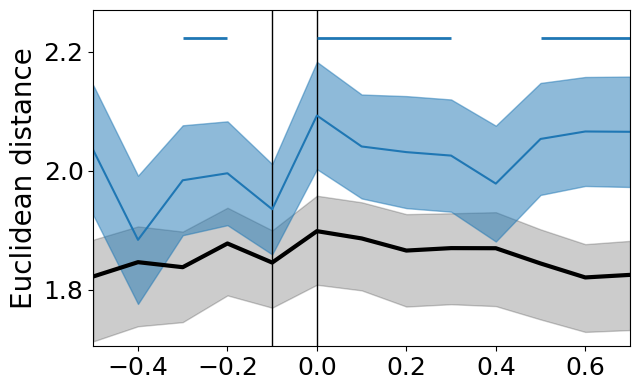

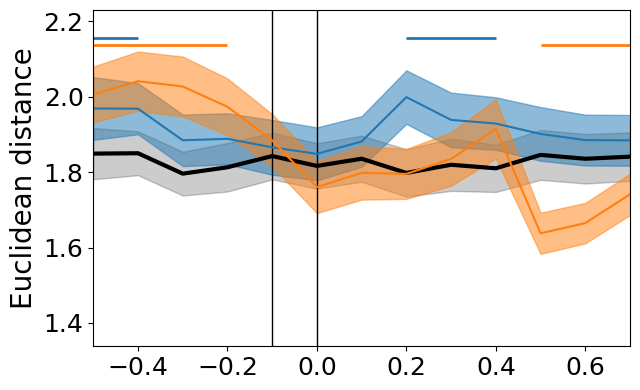

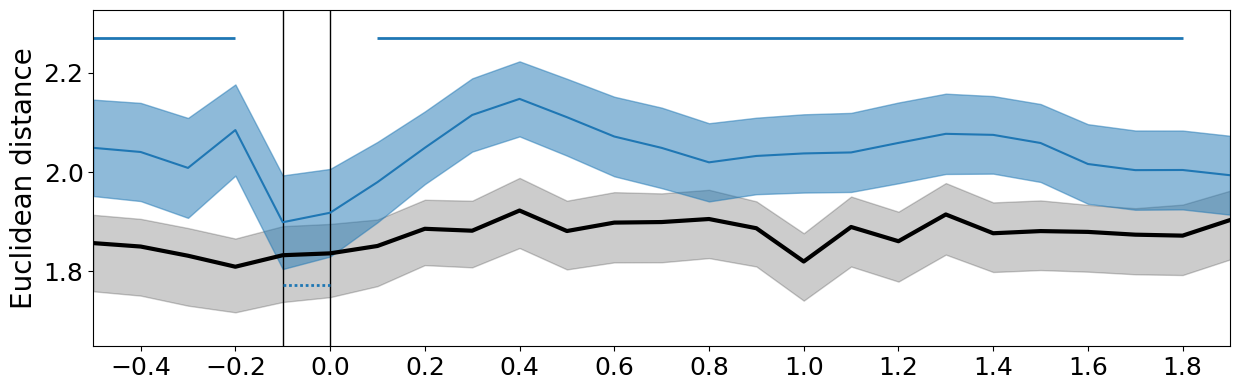

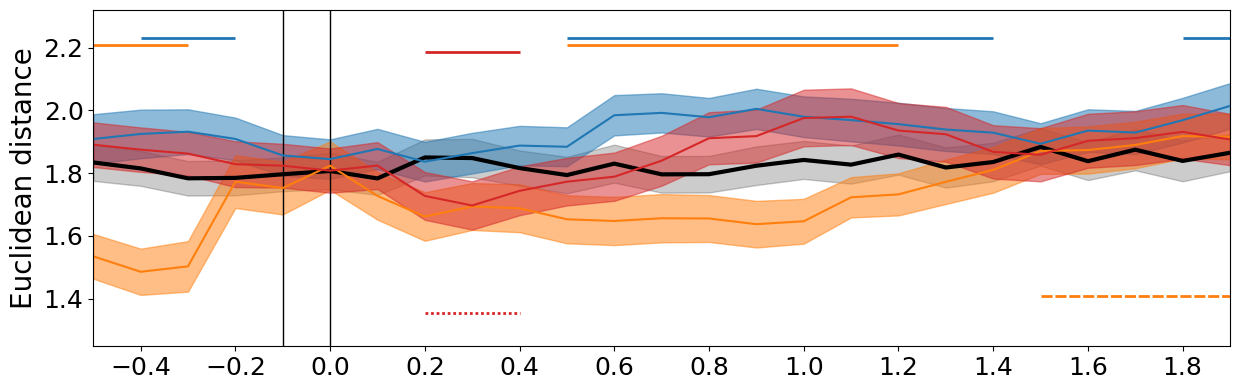

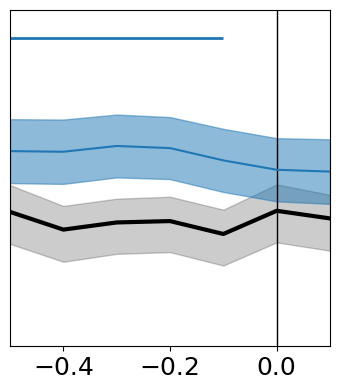

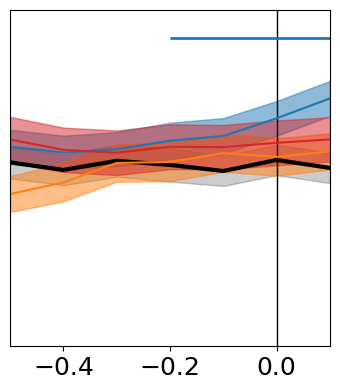

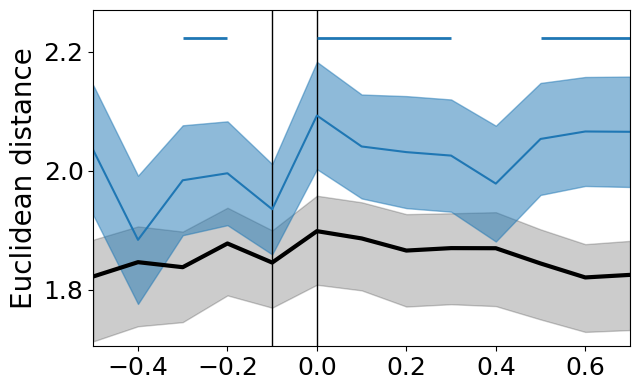

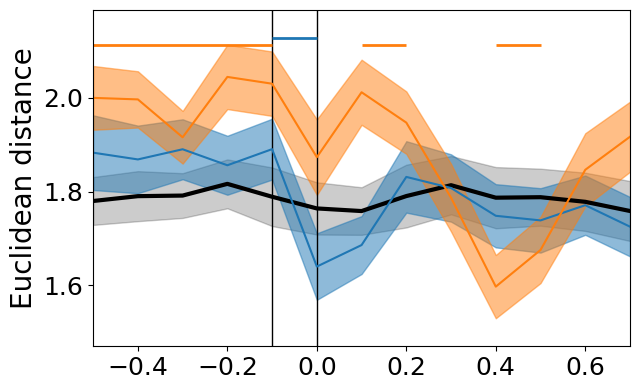

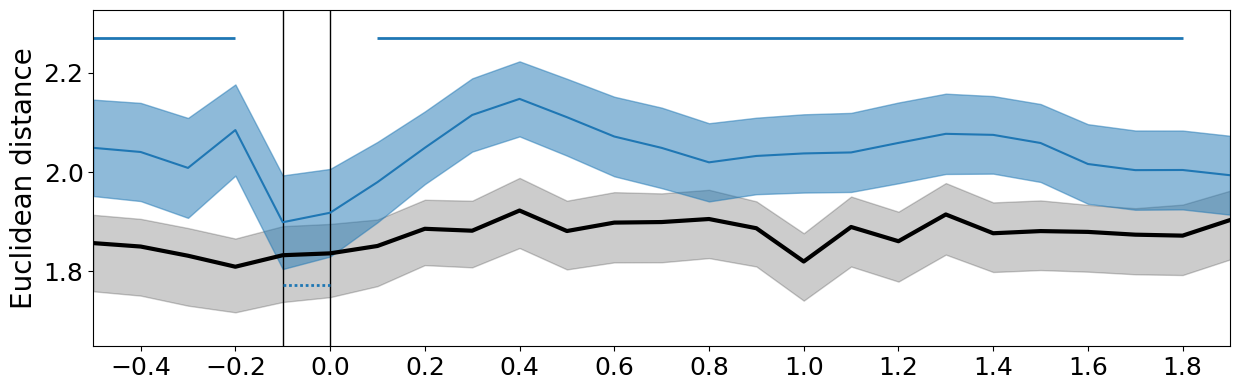

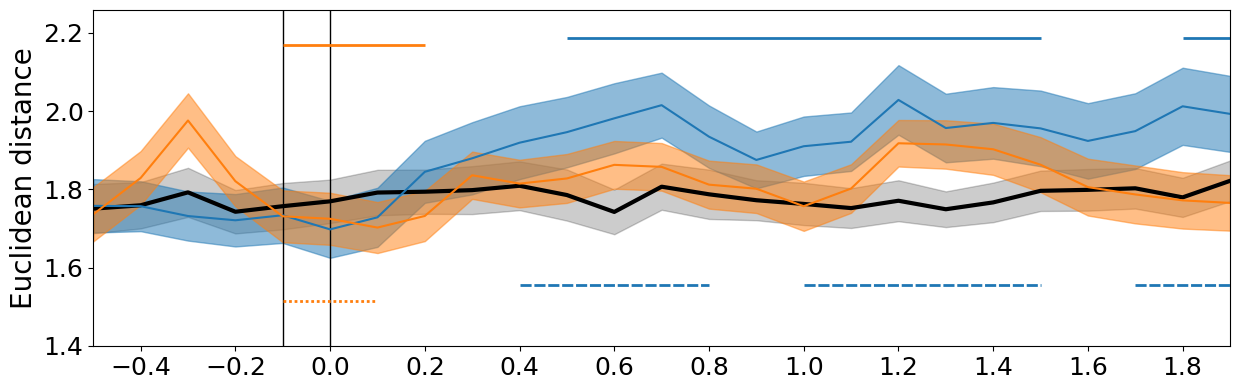

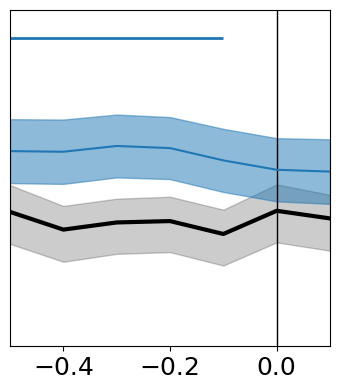

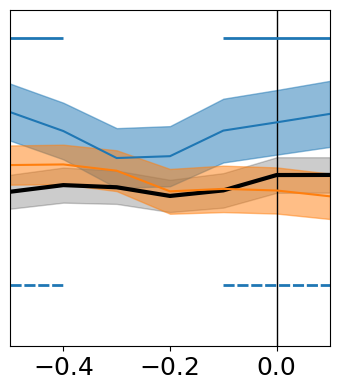

In [10]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'separability_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_02_polygons_pool_loads')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

### apply FDR to all the concatenated p_values (separately for each contrast)

p_values_uncorrected_list_surrogate_relevant = {}
p_values_uncorrected_list_surrogate_nonrelevant = {}
p_values_uncorrected_list_surrogate_control = {}
p_values_uncorrected_list_surrogate_nolonger = {}

p_values_uncorrected_list_cue_relevant = {}
p_values_uncorrected_list_cue_nonrelevant = {}
p_values_uncorrected_list_cue_control = {}
p_values_uncorrected_list_cue_nolonger = {}

p_values_corrected_list_surrogate_relevant = {}
p_values_corrected_list_surrogate_nonrelevant = {}
p_values_corrected_list_surrogate_control = {}
p_values_corrected_list_surrogate_nolonger = {}

p_values_corrected_list_cue_relevant = {}
p_values_corrected_list_cue_nonrelevant = {}
p_values_corrected_list_cue_control = {}
p_values_corrected_list_cue_nolonger = {}

t_values_list_cue_relevant = {}
t_values_list_cue_nonrelevant = {}
t_values_list_cue_control = {}
t_values_list_cue_nolonger = {}

for condition_i in conditions:

    for load_i in [12]:

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            load_ii = 1
            data_load1 = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            data_load2 = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control = np.concat((data_load1, data_load2), axis=0)

            # relevant
            load_ii = 1
            data_relevant_load1 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            data_relevant_load2 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_relevant = np.concat((data_relevant_load1, data_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            data_nonrelevant_load1 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            data_nonrelevant_load2 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_nonrelevant = np.concat((data_nonrelevant_load1, data_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                data_nolonger_load1 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                load_ii = 2
                data_nolonger_load2 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                data_nolonger = np.concat((data_nolonger_load1, data_nolonger_load2), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            load_ii = 1
            surrogate_load1 = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            surrogate_load2 = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control = np.concat((surrogate_load1, surrogate_load2), axis=0)

            # relevant
            load_ii = 1
            surrogate_relevant_load1 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            surrogate_relevant_load2 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_relevant = np.concat((surrogate_relevant_load1, surrogate_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            surrogate_nonrelevant_load1 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            surrogate_nonrelevant_load2 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_load1, surrogate_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                surrogate_nolonger_load1 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                load_ii = 2
                surrogate_nolonger_load2 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_load1, surrogate_nolonger_load2), axis=0)








            # -----------------------------------------
            # Run statistical tests - surrogate effect
            # -----------------------------------------
 
            ## control
            p_values = []
            for t in range(data_control.shape[1]):
                _, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## relevant
            p_values = []
            for t in range(data_relevant.shape[1]):
                _, p = ttest_rel(data_relevant[:, t], surrogate_relevant[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## nonrelevant
            p_values = []
            for t in range(data_nonrelevant.shape[1]):
                _, p = ttest_rel(data_nonrelevant[:, t], surrogate_nonrelevant[:, t])
                p_values.append(p)

            # pool p-values 
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            if condition_i == 'update':

                ## nolongerrelevant
                p_values = []
                for t in range(data_nolonger.shape[1]):
                    _, p = ttest_rel(data_nolonger[:, t], surrogate_nolonger[:, t])
                    p_values.append(p)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                p_values_uncorrected_list_surrogate_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values


            # -----------------------------------
            # Run statistical tests - cue effect
            # -----------------------------------

            if time_window == 'encode':

                data_encode_avg_control = data_control.copy()
                data_encode_avg_relevant = data_relevant.copy()
                data_encode_avg_nonrelevant = data_nonrelevant.copy()
                if condition_i == 'update':
                    data_encode_avg_nolonger = data_nolonger.copy()

            if time_window == 'maint':

                data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)
                data_encode_avg_control = np.mean(data_encode_avg_control[:,5:18], axis=1)

                data_encode_avg_relevant = np.concatenate((data_encode_avg_relevant, data_relevant), axis=1)
                data_encode_avg_nonrelevant = np.concatenate((data_encode_avg_nonrelevant, data_nonrelevant), axis=1)

                data_encode_avg_relevant = np.mean(data_encode_avg_relevant[:,5:18], axis=1)
                data_encode_avg_nonrelevant = np.mean(data_encode_avg_nonrelevant[:,5:18], axis=1)

                if condition_i == 'update':
                    data_encode_avg_nolonger = np.concatenate((data_encode_avg_nolonger, data_nolonger), axis=1)
                    data_encode_avg_nolonger = np.mean(data_encode_avg_nolonger[:,5:18], axis=1)

            if time_window != 'encode': # not used here

                ## control

                p_values = []
                t_values = []
                for t in range(data_control.shape[1]):
                    t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = t_values
                
                ## relevant

                p_values = []
                t_values = []
                for t in range(data_relevant.shape[1]):
                    t, p = ttest_rel(data_relevant[:, t], data_encode_avg_relevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values

                ## non-relevant

                p_values = []
                t_values = []
                for t in range(data_nonrelevant.shape[1]):
                    t, p = ttest_rel(data_nonrelevant[:, t], data_encode_avg_nonrelevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values


                ## nolonger

                if condition_i == 'update':

                    p_values = []
                    t_values = []
                    for t in range(data_nolonger.shape[1]):
                        t, p = ttest_rel(data_nolonger[:, t], data_encode_avg_nolonger)
                        p_values.append(p)
                        t_values.append(t)

                    # pool p-values
                    p_values = np.array(p_values)
                    p_values = np.nan_to_num(p_values, nan=1.0)

                    # pool t-values
                    t_values = np.array(t_values)
                    t_values = np.nan_to_num(t_values, nan=1.0)

                    p_values_uncorrected_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                    t_values_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = t_values





##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [12]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        for time_window in time_windows:

            base_key = f"{time_window}_{condition_i}_{load_i}"

            # control
            vals = p_values_uncorrected_list_surrogate_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))
                
            # relevant
            vals = p_values_uncorrected_list_surrogate_relevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("relevant", base_key, len(vals)))

            # nonrelevant
            vals = p_values_uncorrected_list_surrogate_nonrelevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("nonrelevant", base_key, len(vals)))


            # nolonger
            if condition_i == 'update':

                vals = p_values_uncorrected_list_surrogate_nolonger[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_surrogate_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_surrogate_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_surrogate_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_surrogate_nolonger[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [12]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        # vectorize uncorrected p_values
        for time_window in time_windows:

            if time_window != 'encode':

                base_key = f"{time_window}_{condition_i}_{load_i}"

                # control
                vals = p_values_uncorrected_list_cue_control[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("control", base_key, len(vals)))

                # relevant
                vals = p_values_uncorrected_list_cue_relevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("relevant", base_key, len(vals)))

                # nonrelevant
                vals = p_values_uncorrected_list_cue_nonrelevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nonrelevant", base_key, len(vals)))

                # nolonger
                if condition_i == 'update':

                    vals = p_values_uncorrected_list_cue_nolonger[base_key]
                    p_values_uncorrected.extend(vals)
                    keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_cue_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_cue_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_cue_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_cue_nolonger[key] = corrected_vals



















### plots

for condition_i in conditions:

    for load_i in [12]:

        # find common y-axis limits

        global_ymin = np.inf
        global_ymax = -np.inf

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            load_ii = 1
            data_load1 = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            data_load2 = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control = np.concat((data_load1, data_load2), axis=0)

            # relevant
            load_ii = 1
            data_relevant_load1 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            data_relevant_load2 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_relevant = np.concat((data_relevant_load1, data_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            data_nonrelevant_load1 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            data_nonrelevant_load2 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_nonrelevant = np.concat((data_nonrelevant_load1, data_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                data_nolonger_load1 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                load_ii = 2
                data_nolonger_load2 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                data_nolonger = np.concat((data_nolonger_load1, data_nolonger_load2), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            load_ii = 1
            surrogate_load1 = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            surrogate_load2 = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control = np.concat((surrogate_load1, surrogate_load2), axis=0)

            # relevant
            load_ii = 1
            surrogate_relevant_load1 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            surrogate_relevant_load2 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_relevant = np.concat((surrogate_relevant_load1, surrogate_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            surrogate_nonrelevant_load1 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            surrogate_nonrelevant_load2 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_load1, surrogate_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                surrogate_nolonger_load1 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                load_ii = 2
                surrogate_nolonger_load2 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_load1, surrogate_nolonger_load2), axis=0)



            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])


            # control limits

            ymax = np.max(((mean_control + std_control).max(), (mean_control_surrogate + std_control_surrogate).max()))
            ymin = np.min(((mean_control - std_control).min(), (mean_control_surrogate - std_control_surrogate).min()))

            if time_window == 'encode':

                global_ymin_control = ymin
                global_ymax_control = ymax

            else:

                if ymax > global_ymax_control:
                    global_ymax_control = ymax
                if ymin < global_ymin_control:
                    global_ymin_control = ymin

            # experimental limits

            if condition_i == 'update':

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_nolonger + std_nolonger).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max(), (mean_nolonger_surrogate + std_nolonger_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_nolonger - std_nolonger).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min(), (mean_nolonger_surrogate - std_nolonger_surrogate).min()))

            else:

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min()))

            if time_window == 'encode':

                global_ymin = ymin
                global_ymax = ymax

            else:

                if ymax > global_ymax:
                    global_ymax = ymax
                if ymin < global_ymin:
                    global_ymin = ymin


        # now, pass the code to do the actual plots

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            load_ii = 1
            data_load1 = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            data_load2 = data_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control = np.concat((data_load1, data_load2), axis=0)

            # relevant
            load_ii = 1
            data_relevant_load1 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            data_relevant_load2 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_relevant = np.concat((data_relevant_load1, data_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            data_nonrelevant_load1 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            data_nonrelevant_load2 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_nonrelevant = np.concat((data_nonrelevant_load1, data_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                data_nolonger_load1 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                load_ii = 2
                data_nolonger_load2 = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                data_nolonger = np.concat((data_nolonger_load1, data_nolonger_load2), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            load_ii = 1
            surrogate_load1 = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            surrogate_load2 = surrogate_shape[time_window + '_edistshape_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control = np.concat((surrogate_load1, surrogate_load2), axis=0)

            # relevant
            load_ii = 1
            surrogate_relevant_load1 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            surrogate_relevant_load2 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_relevant = np.concat((surrogate_relevant_load1, surrogate_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            surrogate_nonrelevant_load1 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            surrogate_nonrelevant_load2 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_load1, surrogate_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                surrogate_nolonger_load1 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                load_ii = 2
                surrogate_nolonger_load2 = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_nolongerrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_load1, surrogate_nolonger_load2), axis=0)


            # ------------------------------------------
            # FDR corrected p-values - surrogate effect
            # ------------------------------------------

            ## relevant

            p_values_corrected_list = p_values_corrected_list_surrogate_relevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_relevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## nonrelevant

            p_values_corrected_list = p_values_corrected_list_surrogate_nonrelevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_nonrelevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## control

            p_values_corrected_list = p_values_corrected_list_surrogate_control.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_control_surrogate = np.where(p_corrected < 0.025)[0]

            ## nolonger

            if condition_i == 'update':

                p_values_corrected_list = p_values_corrected_list_surrogate_nolonger.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]

                # Find significant timepoints
                significant_timepoints_nolonger_surrogate = np.where(p_corrected < 0.025)[0]







            # ------------------------------------
            # FDR corrected p-values - cue effect
            # ------------------------------------

            if time_window != 'encode':

                ## relevant 

                p_values_corrected_list = p_values_corrected_list_cue_relevant.copy()
                t_values_list = t_values_list_cue_relevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_relevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_relevant) > 0:

                    significant_timepoints_relevant_cue_positive = []
                    significant_timepoints_relevant_cue_negative = []

                    for p_i in significant_timepoints_relevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_relevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_relevant_cue_negative.append(p_i)

                    significant_timepoints_relevant_cue_positive = np.array(significant_timepoints_relevant_cue_positive)
                    significant_timepoints_relevant_cue_negative = np.array(significant_timepoints_relevant_cue_negative)

                else:

                    significant_timepoints_relevant_cue_positive = np.array([])
                    significant_timepoints_relevant_cue_negative = np.array([])

                ## non-relevant 

                p_values_corrected_list = p_values_corrected_list_cue_nonrelevant.copy()
                t_values_list = t_values_list_cue_nonrelevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_nonrelevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_nonrelevant) > 0:

                    significant_timepoints_nonrelevant_cue_positive = []
                    significant_timepoints_nonrelevant_cue_negative = []

                    for p_i in significant_timepoints_nonrelevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_nonrelevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_nonrelevant_cue_negative.append(p_i)

                    significant_timepoints_nonrelevant_cue_positive = np.array(significant_timepoints_nonrelevant_cue_positive)
                    significant_timepoints_nonrelevant_cue_negative = np.array(significant_timepoints_nonrelevant_cue_negative)

                else:

                    significant_timepoints_nonrelevant_cue_positive = np.array([])
                    significant_timepoints_nonrelevant_cue_negative = np.array([])

                ## control 

                p_values_corrected_list = p_values_corrected_list_cue_control.copy()
                t_values_list = t_values_list_cue_control.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_control = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_control) > 0:

                    significant_timepoints_control_cue_positive = []
                    significant_timepoints_control_cue_negative = []

                    for p_i in significant_timepoints_control:
                        if t_values[p_i] > 0:
                            significant_timepoints_control_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_control_cue_negative.append(p_i)

                    significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                    significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

                else:

                    significant_timepoints_control_cue_positive = np.array([])
                    significant_timepoints_control_cue_negative = np.array([])

                ## no-longer-relevant 

                if condition_i == 'update':

                    p_values_corrected_list = p_values_corrected_list_cue_nolonger.copy()
                    t_values_list = t_values_list_cue_nolonger.copy()

                    key = f"{time_window}_{condition_i}_{load_i}"
                    p_corrected = p_values_corrected_list[key]
                    t_values = t_values_list[key]

                    # set to one the p-values from timepoints before the cue
                    if time_window == 'maint':
                        p_corrected[0:4] = 1

                    # Find significant timepoints
                    significant_timepoints_nolonger = np.where(p_corrected < 0.025)[0]

                    # split positive and negative t-values
                    if len(significant_timepoints_nolonger) > 0:

                        significant_timepoints_nolonger_cue_positive = []
                        significant_timepoints_nolonger_cue_negative = []

                        for p_i in significant_timepoints_nolonger:
                            if t_values[p_i] > 0:
                                significant_timepoints_nolonger_cue_positive.append(p_i)
                            elif t_values[p_i] < 0:
                                significant_timepoints_nolonger_cue_negative.append(p_i)

                        significant_timepoints_nolonger_cue_positive = np.array(significant_timepoints_nolonger_cue_positive)
                        significant_timepoints_nolonger_cue_negative = np.array(significant_timepoints_nolonger_cue_negative)

                    else:

                        significant_timepoints_nolonger_cue_positive = np.array([])
                        significant_timepoints_nolonger_cue_negative = np.array([])




            # ---------------------
            # Time axis
            # ---------------------
            time = (np.arange(data_relevant.shape[1]) - index_of_zero)* 0.1 # sec

            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])








            # ---------------------
            # Plot - control
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)


            ## surrogate

            # control condition
            plt.plot(time, mean_control_surrogate, label='Control', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_control_surrogate - std_control, mean_control_surrogate + std_control_surrogate, alpha=0.2, color='black')

            ## observed

            # control condition
            plt.plot(time, mean_control, label='Control', color='tab:blue')
            plt.fill_between(time, mean_control - std_control, mean_control + std_control, alpha=0.5, color='tab:blue')


            # y-axis limits
            padding = 0.1 * (global_ymax_control - global_ymin_control)
            global_ymin_control -= padding
            global_ymax_control += padding
            plt.ylim(global_ymin_control, global_ymax_control)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # control

            if significant_timepoints_control_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax_control - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # control positive

                if significant_timepoints_control_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  

                # control negative

                if significant_timepoints_control_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  

            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)

            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_control_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()





            # ---------------------
            # Plot - experimental conditions (inhibition or update)
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)

            ## surrogate

            # Relevant
            plt.plot(time, mean_rel_surrogate, label='Relevant', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_rel_surrogate - std_rel_surrogate, mean_rel_surrogate + std_rel_surrogate, alpha=0.2, color='black')

            ## observed

            # Relevant
            plt.plot(time, mean_rel, label='Relevant', color='tab:blue')
            plt.fill_between(time, mean_rel - std_rel, mean_rel + std_rel, alpha=0.5, color='tab:blue')

            # Nonrelevant
            plt.plot(time, mean_nonrel, label='Nonrelevant', color='tab:orange')
            plt.fill_between(time, mean_nonrel - std_nonrel, mean_nonrel + std_nonrel, alpha=0.5, color='tab:orange')

            if condition_i == 'update' and time_window != 'encode':

                # no-longer-relevant
                plt.plot(time, mean_nolonger, label='Nolonger', color="tab:red")
                plt.fill_between(time, mean_nolonger - std_nolonger, mean_nolonger + std_nolonger, alpha=0.5, color="tab:red")



            # y-axis limits
            padding = 0.1 * (global_ymax - global_ymin)
            global_ymin -= padding
            global_ymax += padding
            plt.ylim(global_ymin, global_ymax)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # relevant

            if significant_timepoints_relevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_relevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            # nonrelevant

            if significant_timepoints_nonrelevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding - (padding * 0.25)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_nonrelevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2)

            # nolonger

            if condition_i == 'update' and time_window != 'encode':

                if significant_timepoints_nolonger_surrogate.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymax - padding - (padding * 0.5)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nolonger_surrogate), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # relevant - positive

                if significant_timepoints_relevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

                # relevant - negative

                if significant_timepoints_relevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  


                # non-relevant positive

                if significant_timepoints_nonrelevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.8)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (4, 1)))  

                # non-relevant negative

                if significant_timepoints_nonrelevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.6)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (1, 1)))  


                # nolonger positive

                if condition_i == 'update':

                    if significant_timepoints_nolonger_cue_positive.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.4)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_positive), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  

                    # nolonger negative

                    if significant_timepoints_nolonger_cue_negative.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.2)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_negative), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  




            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)


            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_' + condition_i + '_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()




# Gratings - pool loads 

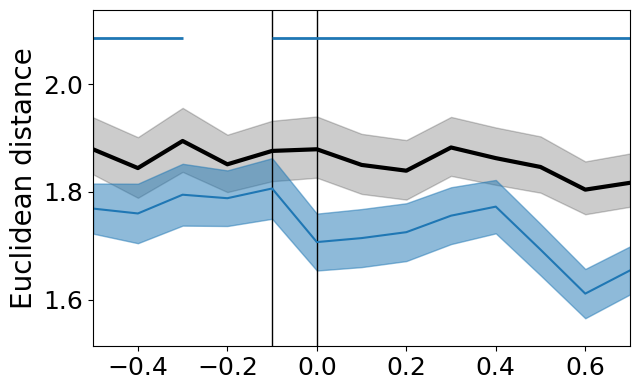

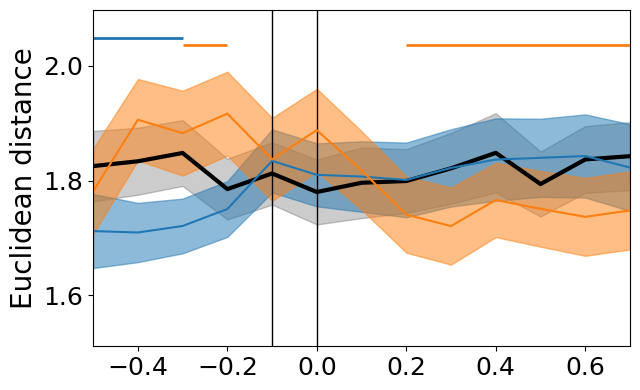

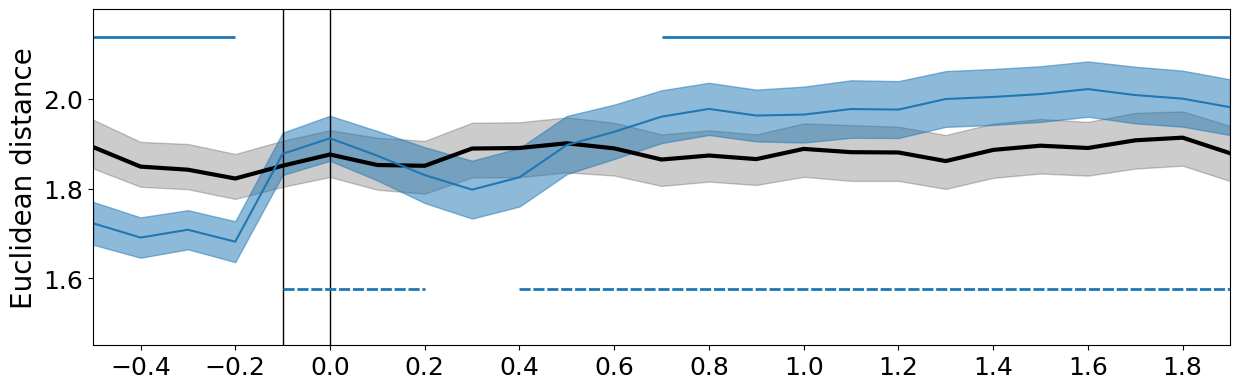

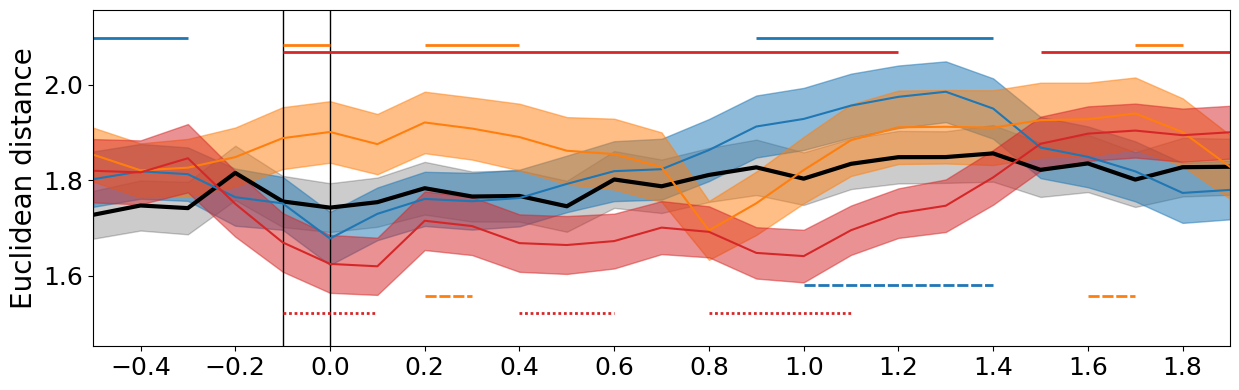

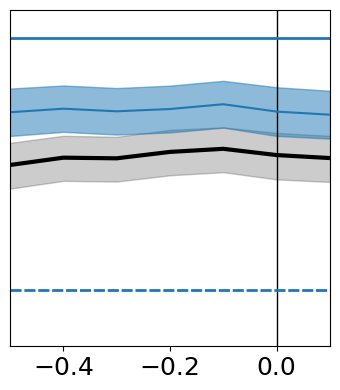

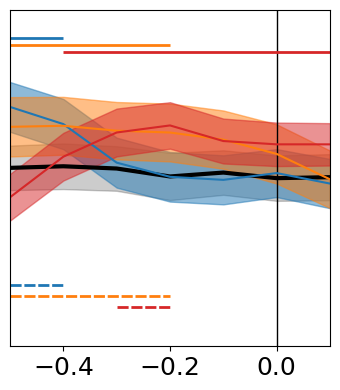

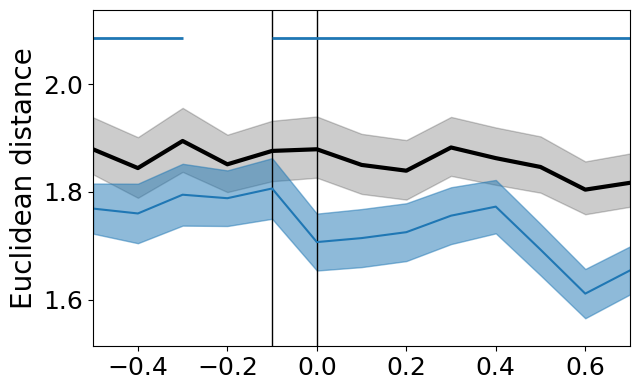

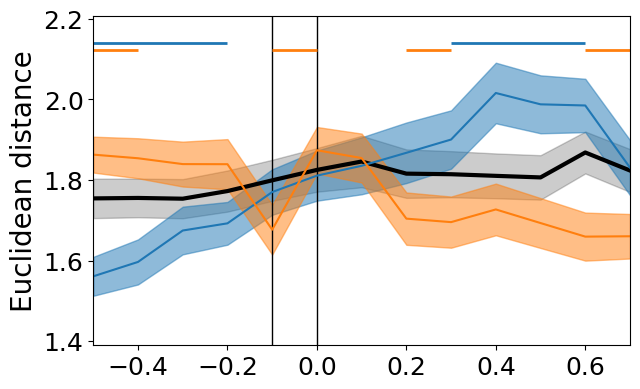

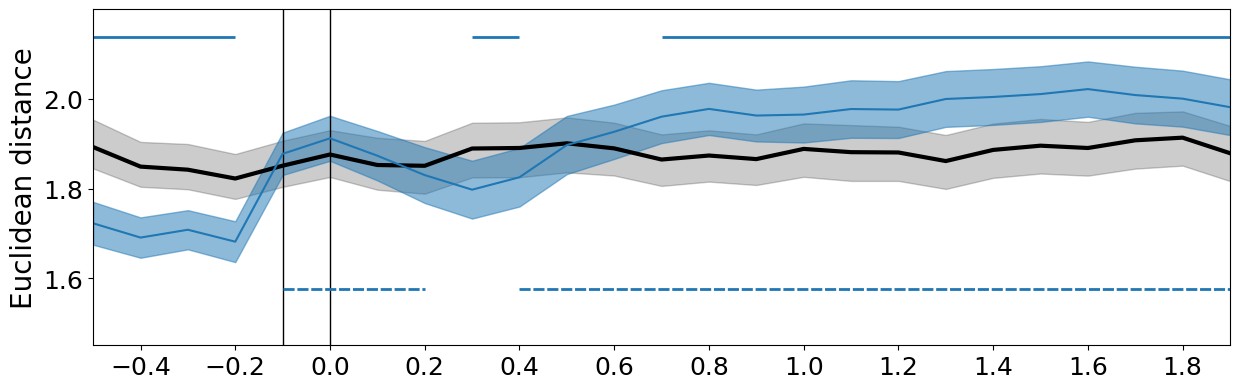

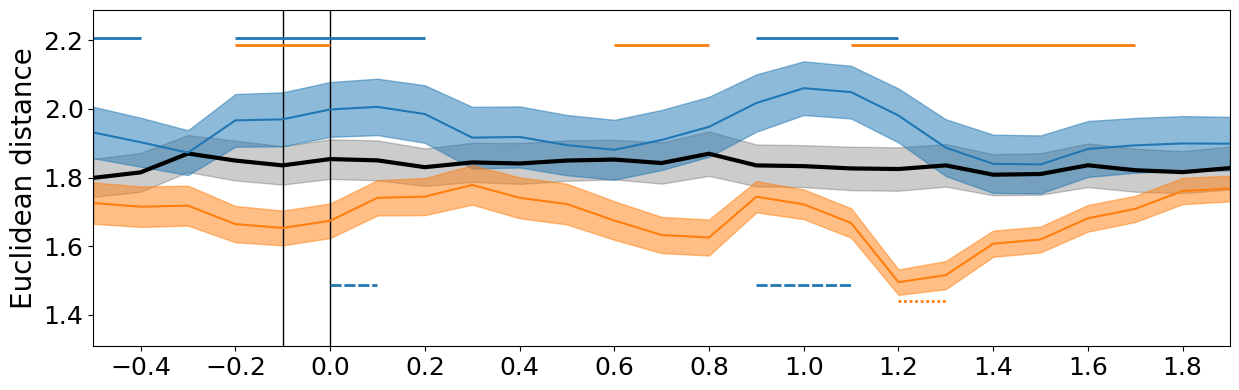

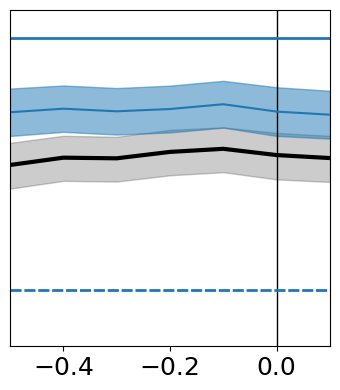

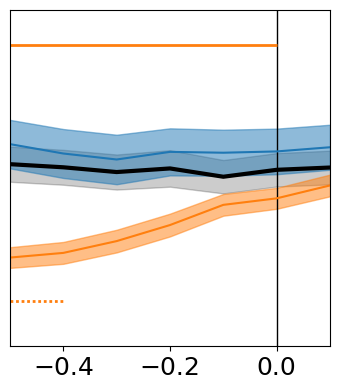

In [11]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'separability_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_03_gratings_pool_loads')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

### apply FDR to all the concatenated p_values (separately for each contrast)

p_values_uncorrected_list_surrogate_relevant = {}
p_values_uncorrected_list_surrogate_nonrelevant = {}
p_values_uncorrected_list_surrogate_control = {}
p_values_uncorrected_list_surrogate_nolonger = {}

p_values_uncorrected_list_cue_relevant = {}
p_values_uncorrected_list_cue_nonrelevant = {}
p_values_uncorrected_list_cue_control = {}
p_values_uncorrected_list_cue_nolonger = {}

p_values_corrected_list_surrogate_relevant = {}
p_values_corrected_list_surrogate_nonrelevant = {}
p_values_corrected_list_surrogate_control = {}
p_values_corrected_list_surrogate_nolonger = {}

p_values_corrected_list_cue_relevant = {}
p_values_corrected_list_cue_nonrelevant = {}
p_values_corrected_list_cue_control = {}
p_values_corrected_list_cue_nolonger = {}

t_values_list_cue_relevant = {}
t_values_list_cue_nonrelevant = {}
t_values_list_cue_control = {}
t_values_list_cue_nolonger = {}

for condition_i in conditions:

    for load_i in [12]:

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            load_ii = 1
            data_load1 = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            data_load2 = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control = np.concat((data_load1, data_load2), axis=0)

            # relevant
            load_ii = 1
            data_relevant_load1 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            data_relevant_load2 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_relevant = np.concat((data_relevant_load1, data_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            data_nonrelevant_load1 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            data_nonrelevant_load2 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_nonrelevant = np.concat((data_nonrelevant_load1, data_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                data_nolonger_load1 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                load_ii = 2
                data_nolonger_load2 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                data_nolonger = np.concat((data_nolonger_load1, data_nolonger_load2), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            load_ii = 1
            surrogate_load1 = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            surrogate_load2 = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control = np.concat((surrogate_load1, surrogate_load2), axis=0)

            # relevant
            load_ii = 1
            surrogate_relevant_load1 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            surrogate_relevant_load2 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_relevant = np.concat((surrogate_relevant_load1, surrogate_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            surrogate_nonrelevant_load1 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            surrogate_nonrelevant_load2 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_load1, surrogate_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                surrogate_nolonger_load1 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                load_ii = 2
                surrogate_nolonger_load2 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_load1, surrogate_nolonger_load2), axis=0)








            # -----------------------------------------
            # Run statistical tests - surrogate effect
            # -----------------------------------------
 
            ## control
            p_values = []
            for t in range(data_control.shape[1]):
                _, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## relevant
            p_values = []
            for t in range(data_relevant.shape[1]):
                _, p = ttest_rel(data_relevant[:, t], surrogate_relevant[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## nonrelevant
            p_values = []
            for t in range(data_nonrelevant.shape[1]):
                _, p = ttest_rel(data_nonrelevant[:, t], surrogate_nonrelevant[:, t])
                p_values.append(p)

            # pool p-values 
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            if condition_i == 'update':

                ## nolongerrelevant
                p_values = []
                for t in range(data_nolonger.shape[1]):
                    _, p = ttest_rel(data_nolonger[:, t], surrogate_nolonger[:, t])
                    p_values.append(p)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                p_values_uncorrected_list_surrogate_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values


            # -----------------------------------
            # Run statistical tests - cue effect
            # -----------------------------------

            if time_window == 'encode':

                data_encode_avg_control = data_control.copy()
                data_encode_avg_relevant = data_relevant.copy()
                data_encode_avg_nonrelevant = data_nonrelevant.copy()
                if condition_i == 'update':
                    data_encode_avg_nolonger = data_nolonger.copy()

            if time_window == 'maint':

                data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)
                data_encode_avg_control = np.mean(data_encode_avg_control[:,5:18], axis=1)

                data_encode_avg_relevant = np.concatenate((data_encode_avg_relevant, data_relevant), axis=1)
                data_encode_avg_nonrelevant = np.concatenate((data_encode_avg_nonrelevant, data_nonrelevant), axis=1)

                data_encode_avg_relevant = np.mean(data_encode_avg_relevant[:,5:18], axis=1)
                data_encode_avg_nonrelevant = np.mean(data_encode_avg_nonrelevant[:,5:18], axis=1)

                if condition_i == 'update':
                    data_encode_avg_nolonger = np.concatenate((data_encode_avg_nolonger, data_nolonger), axis=1)
                    data_encode_avg_nolonger = np.mean(data_encode_avg_nolonger[:,5:18], axis=1)

            if time_window != 'encode': # not used here

                ## control

                p_values = []
                t_values = []
                for t in range(data_control.shape[1]):
                    t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = t_values
                
                ## relevant

                p_values = []
                t_values = []
                for t in range(data_relevant.shape[1]):
                    t, p = ttest_rel(data_relevant[:, t], data_encode_avg_relevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values

                ## non-relevant

                p_values = []
                t_values = []
                for t in range(data_nonrelevant.shape[1]):
                    t, p = ttest_rel(data_nonrelevant[:, t], data_encode_avg_nonrelevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values


                ## nolonger

                if condition_i == 'update':

                    p_values = []
                    t_values = []
                    for t in range(data_nolonger.shape[1]):
                        t, p = ttest_rel(data_nolonger[:, t], data_encode_avg_nolonger)
                        p_values.append(p)
                        t_values.append(t)

                    # pool p-values
                    p_values = np.array(p_values)
                    p_values = np.nan_to_num(p_values, nan=1.0)

                    # pool t-values
                    t_values = np.array(t_values)
                    t_values = np.nan_to_num(t_values, nan=1.0)

                    p_values_uncorrected_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                    t_values_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = t_values





##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [12]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        for time_window in time_windows:

            base_key = f"{time_window}_{condition_i}_{load_i}"

            # control
            vals = p_values_uncorrected_list_surrogate_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))
                
            # relevant
            vals = p_values_uncorrected_list_surrogate_relevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("relevant", base_key, len(vals)))

            # nonrelevant
            vals = p_values_uncorrected_list_surrogate_nonrelevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("nonrelevant", base_key, len(vals)))


            # nolonger
            if condition_i == 'update':

                vals = p_values_uncorrected_list_surrogate_nolonger[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_surrogate_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_surrogate_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_surrogate_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_surrogate_nolonger[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [12]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        # vectorize uncorrected p_values
        for time_window in time_windows:

            if time_window != 'encode':

                base_key = f"{time_window}_{condition_i}_{load_i}"

                # control
                vals = p_values_uncorrected_list_cue_control[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("control", base_key, len(vals)))

                # relevant
                vals = p_values_uncorrected_list_cue_relevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("relevant", base_key, len(vals)))

                # nonrelevant
                vals = p_values_uncorrected_list_cue_nonrelevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nonrelevant", base_key, len(vals)))

                # nolonger
                if condition_i == 'update':

                    vals = p_values_uncorrected_list_cue_nolonger[base_key]
                    p_values_uncorrected.extend(vals)
                    keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_cue_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_cue_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_cue_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_cue_nolonger[key] = corrected_vals



















### plots

for condition_i in conditions:

    for load_i in [12]:

        # find common y-axis limits

        global_ymin = np.inf
        global_ymax = -np.inf

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            load_ii = 1
            data_load1 = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            data_load2 = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control = np.concat((data_load1, data_load2), axis=0)

            # relevant
            load_ii = 1
            data_relevant_load1 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            data_relevant_load2 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_relevant = np.concat((data_relevant_load1, data_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            data_nonrelevant_load1 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            data_nonrelevant_load2 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_nonrelevant = np.concat((data_nonrelevant_load1, data_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                data_nolonger_load1 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                load_ii = 2
                data_nolonger_load2 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                data_nolonger = np.concat((data_nolonger_load1, data_nolonger_load2), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            load_ii = 1
            surrogate_load1 = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            surrogate_load2 = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control = np.concat((surrogate_load1, surrogate_load2), axis=0)

            # relevant
            load_ii = 1
            surrogate_relevant_load1 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            surrogate_relevant_load2 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_relevant = np.concat((surrogate_relevant_load1, surrogate_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            surrogate_nonrelevant_load1 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            surrogate_nonrelevant_load2 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_load1, surrogate_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                surrogate_nolonger_load1 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                load_ii = 2
                surrogate_nolonger_load2 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_load1, surrogate_nolonger_load2), axis=0)



            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])


            # control limits

            ymax = np.max(((mean_control + std_control).max(), (mean_control_surrogate + std_control_surrogate).max()))
            ymin = np.min(((mean_control - std_control).min(), (mean_control_surrogate - std_control_surrogate).min()))

            if time_window == 'encode':

                global_ymin_control = ymin
                global_ymax_control = ymax

            else:

                if ymax > global_ymax_control:
                    global_ymax_control = ymax
                if ymin < global_ymin_control:
                    global_ymin_control = ymin

            # experimental limits

            if condition_i == 'update':

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_nolonger + std_nolonger).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max(), (mean_nolonger_surrogate + std_nolonger_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_nolonger - std_nolonger).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min(), (mean_nolonger_surrogate - std_nolonger_surrogate).min()))

            else:

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min()))

            if time_window == 'encode':

                global_ymin = ymin
                global_ymax = ymax

            else:

                if ymax > global_ymax:
                    global_ymax = ymax
                if ymin < global_ymin:
                    global_ymin = ymin


        # now, pass the code to do the actual plots

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)


            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            load_ii = 1
            data_load1 = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            data_load2 = data_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            data_control = np.concat((data_load1, data_load2), axis=0)

            # relevant
            load_ii = 1
            data_relevant_load1 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            data_relevant_load2 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            data_relevant = np.concat((data_relevant_load1, data_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            data_nonrelevant_load1 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            data_nonrelevant_load2 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            data_nonrelevant = np.concat((data_nonrelevant_load1, data_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                data_nolonger_load1 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                load_ii = 2
                data_nolonger_load2 = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                data_nolonger = np.concat((data_nolonger_load1, data_nolonger_load2), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            load_ii = 1
            surrogate_load1 = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            load_ii = 2
            surrogate_load2 = surrogate_orientation[time_window + '_edistorient_control_' + str(load_ii) + 'gratings_' + str(load_ii) + 'polygons']
            surrogate_control = np.concat((surrogate_load1, surrogate_load2), axis=0)

            # relevant
            load_ii = 1
            surrogate_relevant_load1 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            load_ii = 2
            surrogate_relevant_load2 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_relevant_' + str(load_ii) + 'polygons_nonrelevant']
            surrogate_relevant = np.concat((surrogate_relevant_load1, surrogate_relevant_load2), axis=0)

            # non-relevant
            load_ii = 1
            surrogate_nonrelevant_load1 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            load_ii = 2
            surrogate_nonrelevant_load2 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nonrelevant_' + str(load_ii) + 'polygons_relevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_load1, surrogate_nonrelevant_load2), axis=0)

            if condition_i == 'update':

                # no longer relevant
                load_ii = 1
                surrogate_nolonger_load1 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                load_ii = 2
                surrogate_nolonger_load2 = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_ii) + 'gratings_nolongerrelevant_' + str(load_ii) + 'polygons_nonrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_load1, surrogate_nolonger_load2), axis=0)


            # ------------------------------------------
            # FDR corrected p-values - surrogate effect
            # ------------------------------------------

            ## relevant

            p_values_corrected_list = p_values_corrected_list_surrogate_relevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_relevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## nonrelevant

            p_values_corrected_list = p_values_corrected_list_surrogate_nonrelevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_nonrelevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## control

            p_values_corrected_list = p_values_corrected_list_surrogate_control.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_control_surrogate = np.where(p_corrected < 0.025)[0]

            ## nolonger

            if condition_i == 'update':

                p_values_corrected_list = p_values_corrected_list_surrogate_nolonger.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]

                # Find significant timepoints
                significant_timepoints_nolonger_surrogate = np.where(p_corrected < 0.025)[0]







            # ------------------------------------
            # FDR corrected p-values - cue effect
            # ------------------------------------

            if time_window != 'encode':

                ## relevant 

                p_values_corrected_list = p_values_corrected_list_cue_relevant.copy()
                t_values_list = t_values_list_cue_relevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_relevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_relevant) > 0:

                    significant_timepoints_relevant_cue_positive = []
                    significant_timepoints_relevant_cue_negative = []

                    for p_i in significant_timepoints_relevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_relevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_relevant_cue_negative.append(p_i)

                    significant_timepoints_relevant_cue_positive = np.array(significant_timepoints_relevant_cue_positive)
                    significant_timepoints_relevant_cue_negative = np.array(significant_timepoints_relevant_cue_negative)

                else:

                    significant_timepoints_relevant_cue_positive = np.array([])
                    significant_timepoints_relevant_cue_negative = np.array([])

                ## non-relevant 

                p_values_corrected_list = p_values_corrected_list_cue_nonrelevant.copy()
                t_values_list = t_values_list_cue_nonrelevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_nonrelevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_nonrelevant) > 0:

                    significant_timepoints_nonrelevant_cue_positive = []
                    significant_timepoints_nonrelevant_cue_negative = []

                    for p_i in significant_timepoints_nonrelevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_nonrelevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_nonrelevant_cue_negative.append(p_i)

                    significant_timepoints_nonrelevant_cue_positive = np.array(significant_timepoints_nonrelevant_cue_positive)
                    significant_timepoints_nonrelevant_cue_negative = np.array(significant_timepoints_nonrelevant_cue_negative)

                else:

                    significant_timepoints_nonrelevant_cue_positive = np.array([])
                    significant_timepoints_nonrelevant_cue_negative = np.array([])

                ## control 

                p_values_corrected_list = p_values_corrected_list_cue_control.copy()
                t_values_list = t_values_list_cue_control.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_control = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_control) > 0:

                    significant_timepoints_control_cue_positive = []
                    significant_timepoints_control_cue_negative = []

                    for p_i in significant_timepoints_control:
                        if t_values[p_i] > 0:
                            significant_timepoints_control_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_control_cue_negative.append(p_i)

                    significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                    significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

                else:

                    significant_timepoints_control_cue_positive = np.array([])
                    significant_timepoints_control_cue_negative = np.array([])

                ## no-longer-relevant 

                if condition_i == 'update':

                    p_values_corrected_list = p_values_corrected_list_cue_nolonger.copy()
                    t_values_list = t_values_list_cue_nolonger.copy()

                    key = f"{time_window}_{condition_i}_{load_i}"
                    p_corrected = p_values_corrected_list[key]
                    t_values = t_values_list[key]

                    # set to one the p-values from timepoints before the cue
                    if time_window == 'maint':
                        p_corrected[0:4] = 1

                    # Find significant timepoints
                    significant_timepoints_nolonger = np.where(p_corrected < 0.025)[0]

                    # split positive and negative t-values
                    if len(significant_timepoints_nolonger) > 0:

                        significant_timepoints_nolonger_cue_positive = []
                        significant_timepoints_nolonger_cue_negative = []

                        for p_i in significant_timepoints_nolonger:
                            if t_values[p_i] > 0:
                                significant_timepoints_nolonger_cue_positive.append(p_i)
                            elif t_values[p_i] < 0:
                                significant_timepoints_nolonger_cue_negative.append(p_i)

                        significant_timepoints_nolonger_cue_positive = np.array(significant_timepoints_nolonger_cue_positive)
                        significant_timepoints_nolonger_cue_negative = np.array(significant_timepoints_nolonger_cue_negative)

                    else:

                        significant_timepoints_nolonger_cue_positive = np.array([])
                        significant_timepoints_nolonger_cue_negative = np.array([])




            # ---------------------
            # Time axis
            # ---------------------
            time = (np.arange(data_relevant.shape[1]) - index_of_zero)* 0.1 # sec

            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])








            # ---------------------
            # Plot - control
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)


            ## surrogate

            # control condition
            plt.plot(time, mean_control_surrogate, label='Control', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_control_surrogate - std_control, mean_control_surrogate + std_control_surrogate, alpha=0.2, color='black')

            ## observed

            # control condition
            plt.plot(time, mean_control, label='Control', color='tab:blue')
            plt.fill_between(time, mean_control - std_control, mean_control + std_control, alpha=0.5, color='tab:blue')


            # y-axis limits
            padding = 0.1 * (global_ymax_control - global_ymin_control)
            global_ymin_control -= padding
            global_ymax_control += padding
            plt.ylim(global_ymin_control, global_ymax_control)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # control

            if significant_timepoints_control_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax_control - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # control positive

                if significant_timepoints_control_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  

                # control negative

                if significant_timepoints_control_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  

            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)

            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_control_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()





            # ---------------------
            # Plot - experimental conditions (inhibition or update)
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)

            ## surrogate

            # Relevant
            plt.plot(time, mean_rel_surrogate, label='Relevant', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_rel_surrogate - std_rel_surrogate, mean_rel_surrogate + std_rel_surrogate, alpha=0.2, color='black')

            ## observed

            # Relevant
            plt.plot(time, mean_rel, label='Relevant', color='tab:blue')
            plt.fill_between(time, mean_rel - std_rel, mean_rel + std_rel, alpha=0.5, color='tab:blue')

            # Nonrelevant
            plt.plot(time, mean_nonrel, label='Nonrelevant', color='tab:orange')
            plt.fill_between(time, mean_nonrel - std_nonrel, mean_nonrel + std_nonrel, alpha=0.5, color='tab:orange')

            if condition_i == 'update' and time_window != 'encode':

                # no-longer-relevant
                plt.plot(time, mean_nolonger, label='Nolonger', color="tab:red")
                plt.fill_between(time, mean_nolonger - std_nolonger, mean_nolonger + std_nolonger, alpha=0.5, color="tab:red")



            # y-axis limits
            padding = 0.1 * (global_ymax - global_ymin)
            global_ymin -= padding
            global_ymax += padding
            plt.ylim(global_ymin, global_ymax)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # relevant

            if significant_timepoints_relevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_relevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            # nonrelevant

            if significant_timepoints_nonrelevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding - (padding * 0.25)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_nonrelevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2)

            # nolonger

            if condition_i == 'update' and time_window != 'encode':

                if significant_timepoints_nolonger_surrogate.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymax - padding - (padding * 0.5)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nolonger_surrogate), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # relevant - positive

                if significant_timepoints_relevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

                # relevant - negative

                if significant_timepoints_relevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  


                # non-relevant positive

                if significant_timepoints_nonrelevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.8)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (4, 1)))  

                # non-relevant negative

                if significant_timepoints_nonrelevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.6)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (1, 1)))  


                # nolonger positive

                if condition_i == 'update':

                    if significant_timepoints_nolonger_cue_positive.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.4)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_positive), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  

                    # nolonger negative

                    if significant_timepoints_nolonger_cue_negative.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.2)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_negative), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  




            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)


            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_' + condition_i + '_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()




# Pool features (polygons, gratings) - separate by load (1, 2)

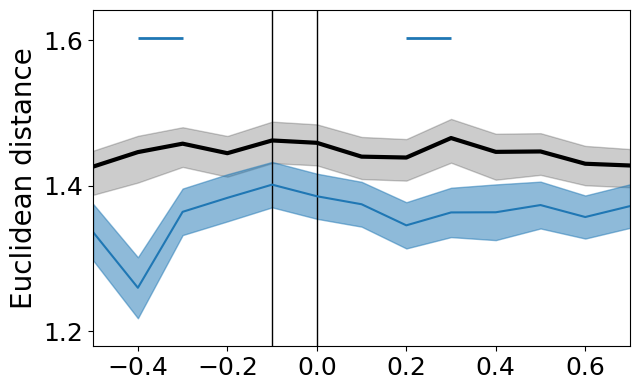

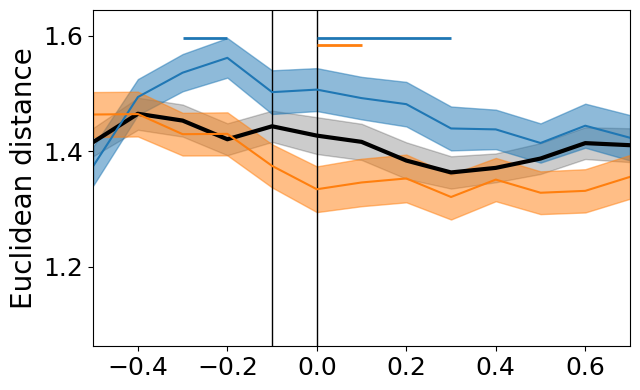

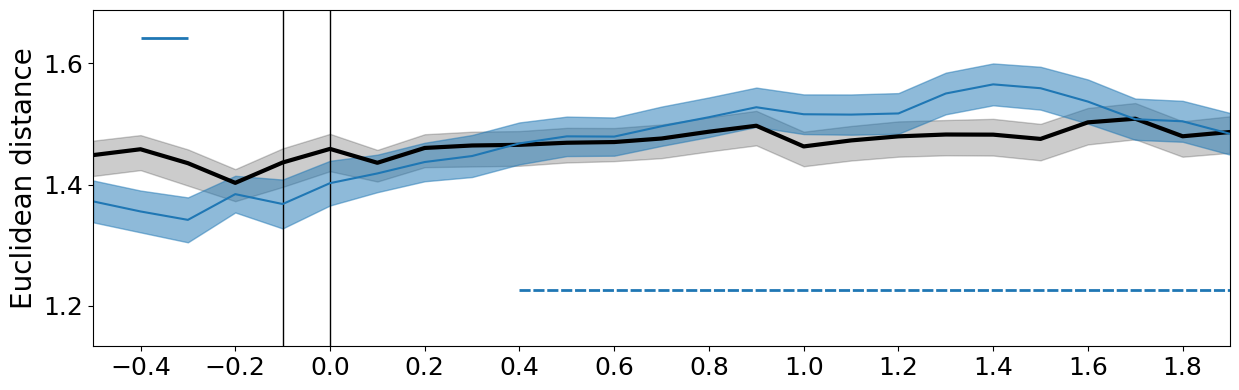

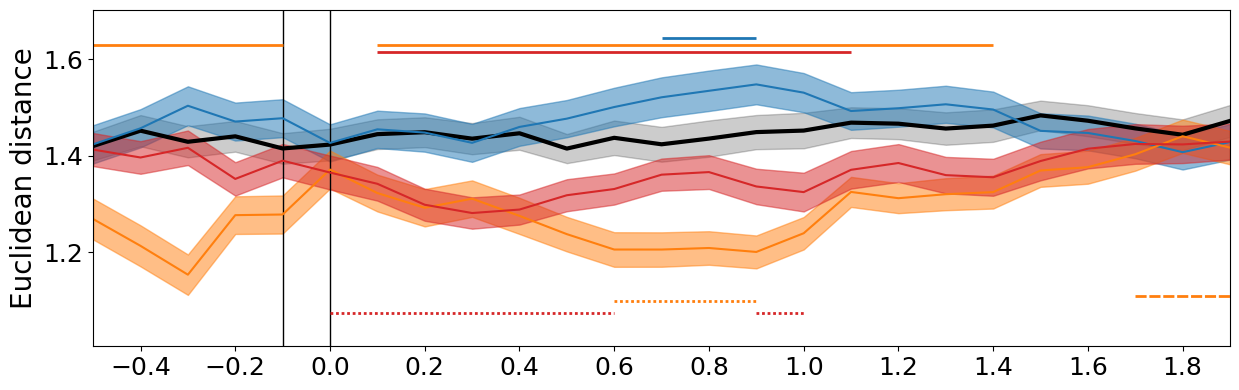

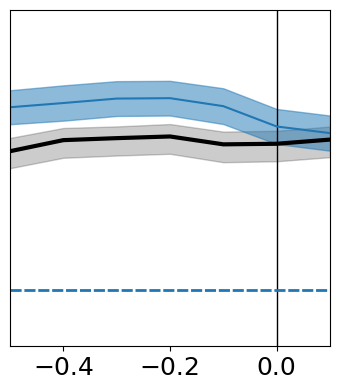

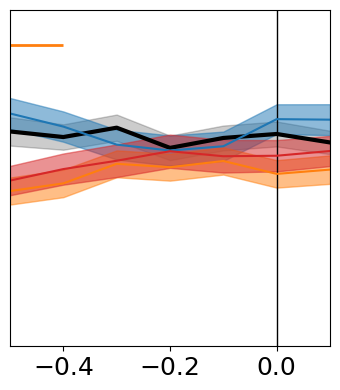

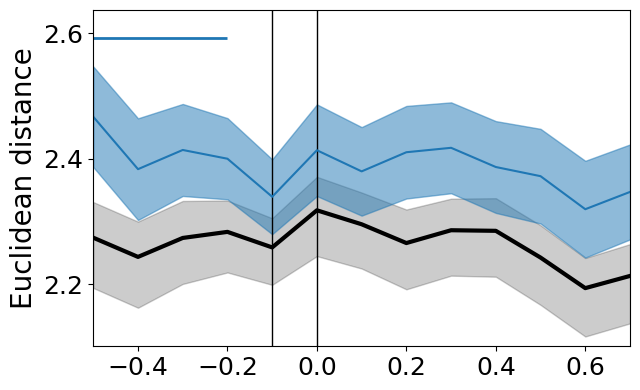

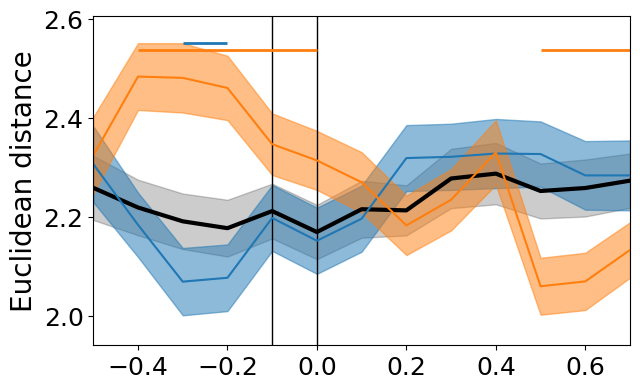

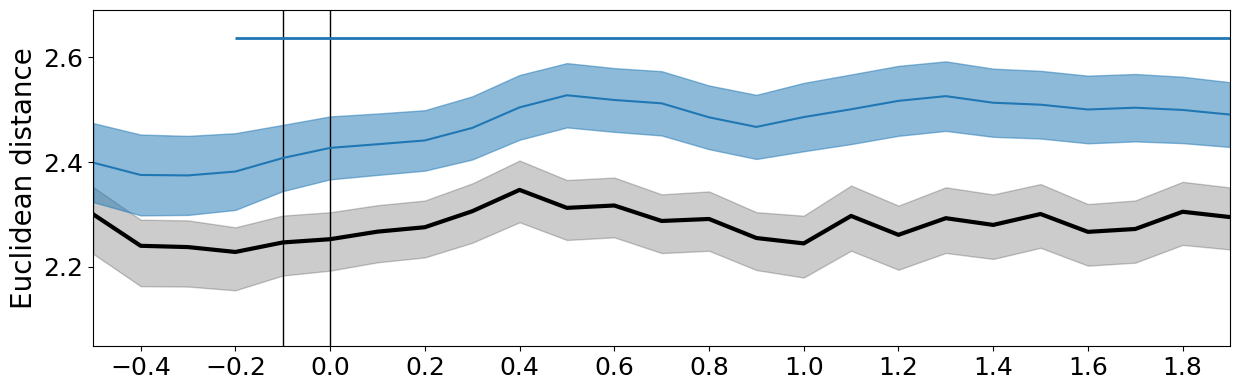

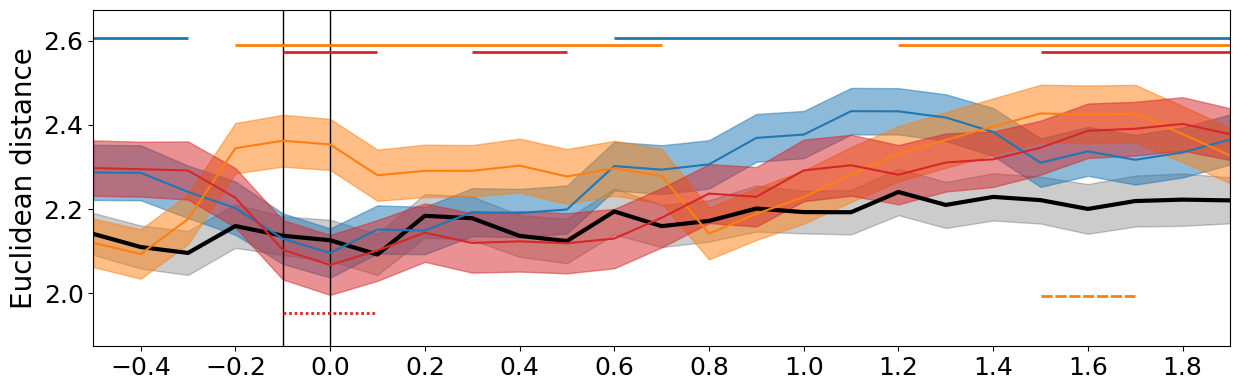

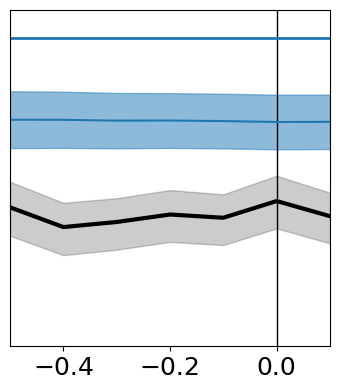

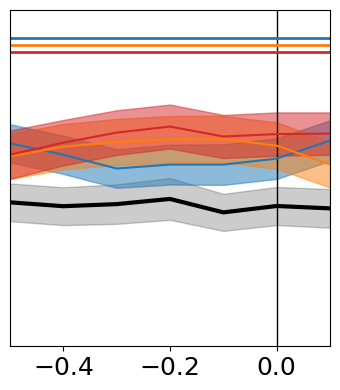

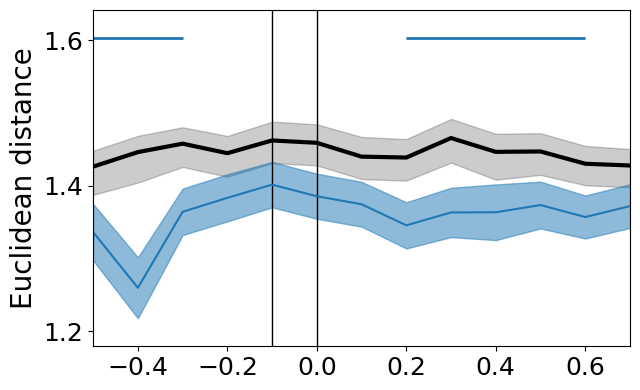

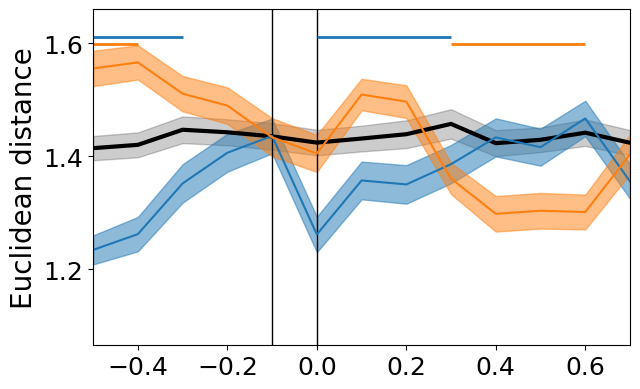

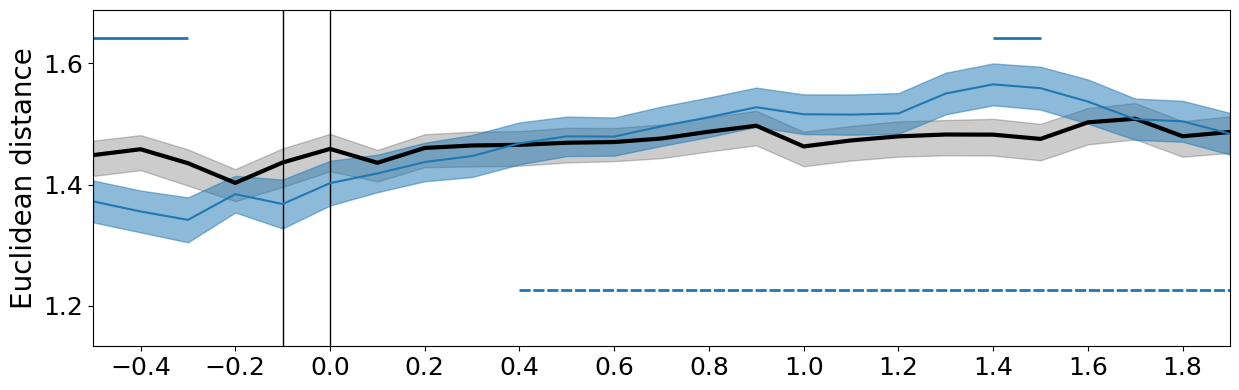

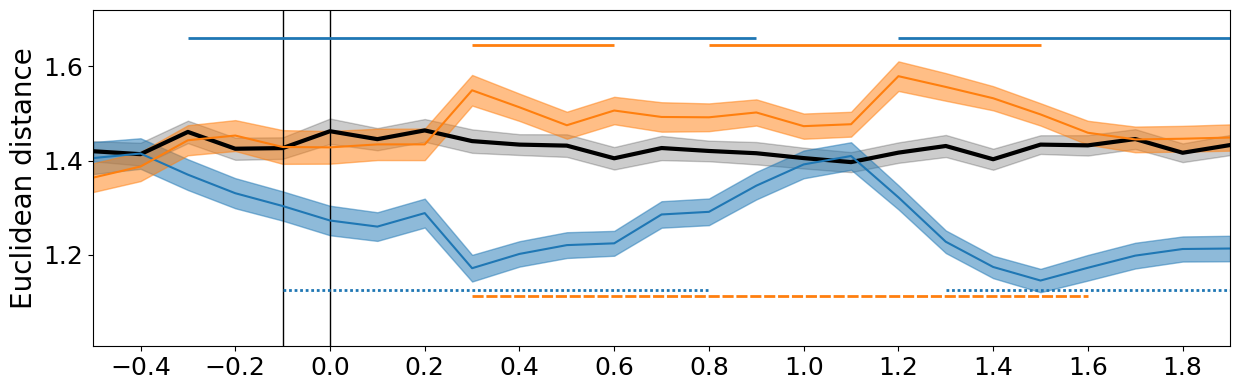

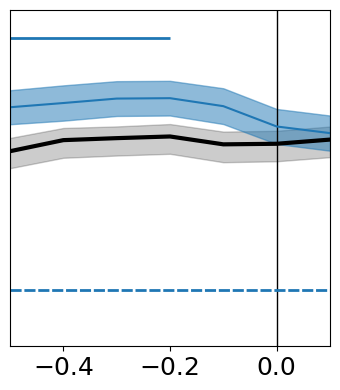

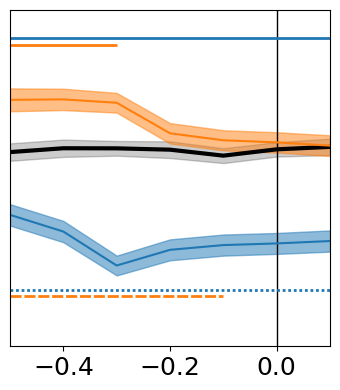

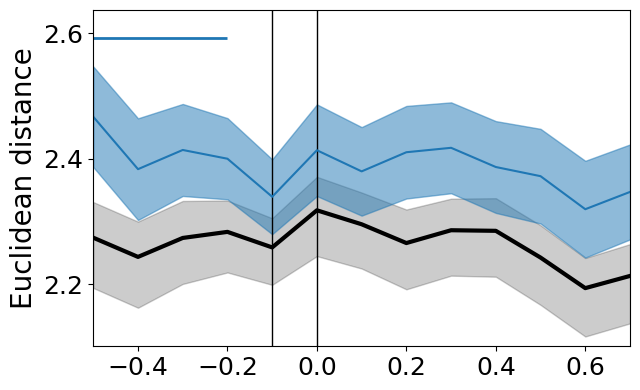

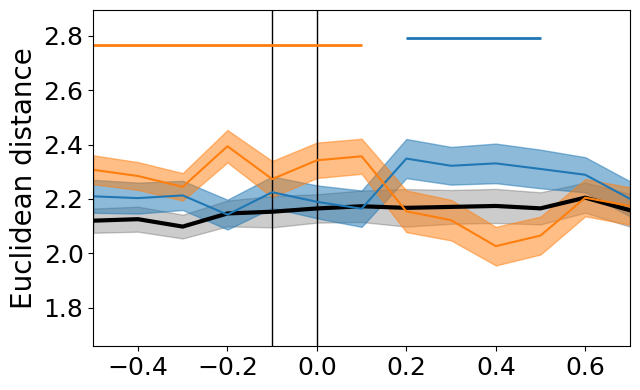

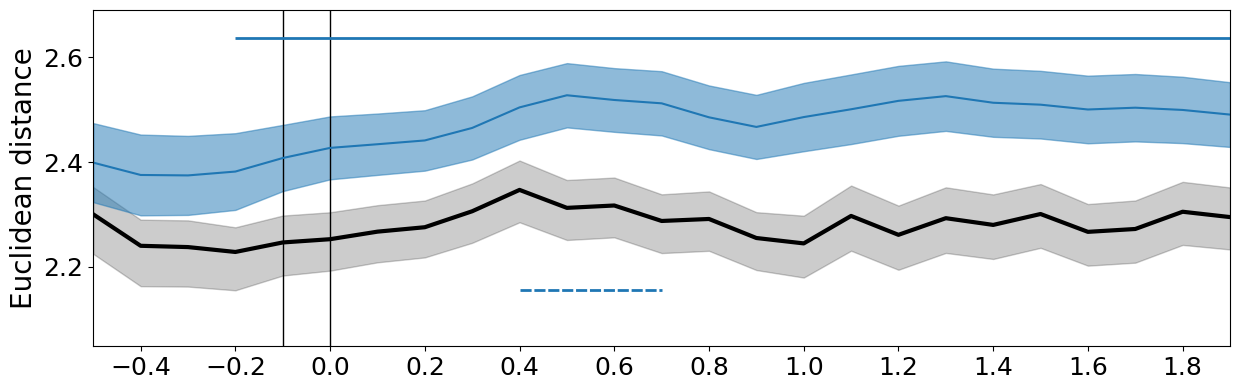

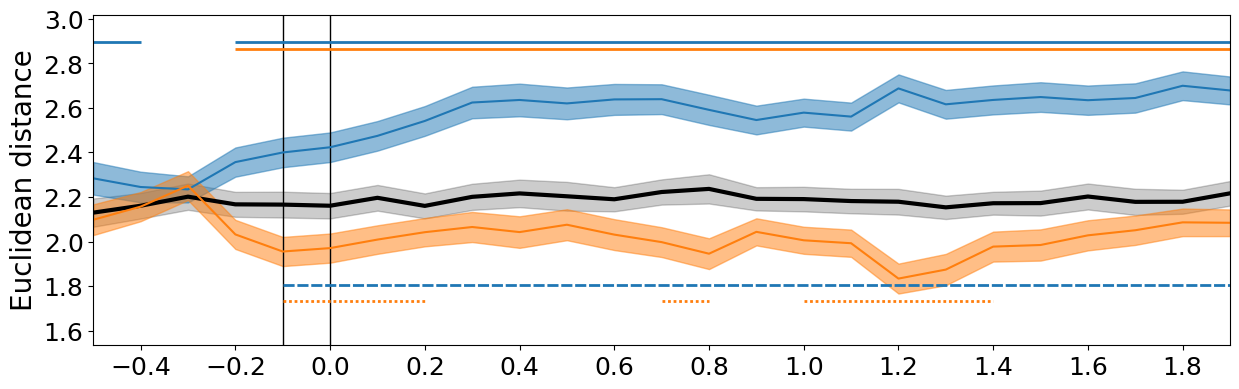

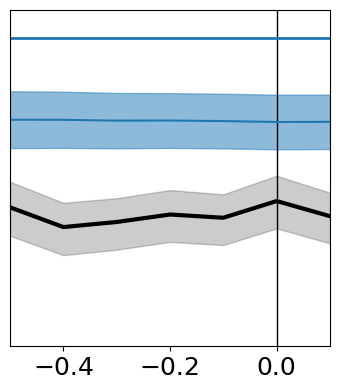

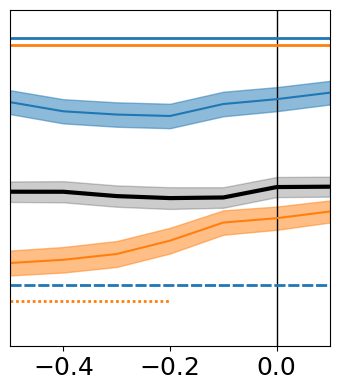

In [12]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'separability_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_04_pool_features_by_load')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

### apply FDR to all the concatenated p_values (separately for each contrast)

p_values_uncorrected_list_surrogate_relevant = {}
p_values_uncorrected_list_surrogate_nonrelevant = {}
p_values_uncorrected_list_surrogate_control = {}
p_values_uncorrected_list_surrogate_nolonger = {}

p_values_uncorrected_list_cue_relevant = {}
p_values_uncorrected_list_cue_nonrelevant = {}
p_values_uncorrected_list_cue_control = {}
p_values_uncorrected_list_cue_nolonger = {}

p_values_corrected_list_surrogate_relevant = {}
p_values_corrected_list_surrogate_nonrelevant = {}
p_values_corrected_list_surrogate_control = {}
p_values_corrected_list_surrogate_nolonger = {}

p_values_corrected_list_cue_relevant = {}
p_values_corrected_list_cue_nonrelevant = {}
p_values_corrected_list_cue_control = {}
p_values_corrected_list_cue_nolonger = {}

t_values_list_cue_relevant = {}
t_values_list_cue_nonrelevant = {}
t_values_list_cue_control = {}
t_values_list_cue_nolonger = {}

for condition_i in conditions:

    for load_i in [1, 2]:

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control = np.concat((data_control_orientation, data_control_shape), axis=0)

            # relevant
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_relevant = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)

            # non-relevant
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_nonrelevant = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                data_nolonger = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)

            # relevant
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_relevant = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)

            # non-relevant
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)








            # -----------------------------------------
            # Run statistical tests - surrogate effect
            # -----------------------------------------
 
            ## control
            p_values = []
            for t in range(data_control.shape[1]):
                _, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## relevant
            p_values = []
            for t in range(data_relevant.shape[1]):
                _, p = ttest_rel(data_relevant[:, t], surrogate_relevant[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## nonrelevant
            p_values = []
            for t in range(data_nonrelevant.shape[1]):
                _, p = ttest_rel(data_nonrelevant[:, t], surrogate_nonrelevant[:, t])
                p_values.append(p)

            # pool p-values 
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            if condition_i == 'update':

                ## nolongerrelevant
                p_values = []
                for t in range(data_nolonger.shape[1]):
                    _, p = ttest_rel(data_nolonger[:, t], surrogate_nolonger[:, t])
                    p_values.append(p)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                p_values_uncorrected_list_surrogate_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values


            # -----------------------------------
            # Run statistical tests - cue effect
            # -----------------------------------

            if time_window == 'encode':

                data_encode_avg_control = data_control.copy()
                data_encode_avg_relevant = data_relevant.copy()
                data_encode_avg_nonrelevant = data_nonrelevant.copy()
                if condition_i == 'update':
                    data_encode_avg_nolonger = data_nolonger.copy()

            if time_window == 'maint':

                data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)
                data_encode_avg_control = np.mean(data_encode_avg_control[:,5:18], axis=1)

                data_encode_avg_relevant = np.concatenate((data_encode_avg_relevant, data_relevant), axis=1)
                data_encode_avg_nonrelevant = np.concatenate((data_encode_avg_nonrelevant, data_nonrelevant), axis=1)

                data_encode_avg_relevant = np.mean(data_encode_avg_relevant[:,5:18], axis=1)
                data_encode_avg_nonrelevant = np.mean(data_encode_avg_nonrelevant[:,5:18], axis=1)

                if condition_i == 'update':
                    data_encode_avg_nolonger = np.concatenate((data_encode_avg_nolonger, data_nolonger), axis=1)
                    data_encode_avg_nolonger = np.mean(data_encode_avg_nolonger[:,5:18], axis=1)

            if time_window != 'encode': # not used here

                ## control

                p_values = []
                t_values = []
                for t in range(data_control.shape[1]):
                    t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = t_values
                
                ## relevant

                p_values = []
                t_values = []
                for t in range(data_relevant.shape[1]):
                    t, p = ttest_rel(data_relevant[:, t], data_encode_avg_relevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values

                ## non-relevant

                p_values = []
                t_values = []
                for t in range(data_nonrelevant.shape[1]):
                    t, p = ttest_rel(data_nonrelevant[:, t], data_encode_avg_nonrelevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values


                ## nolonger

                if condition_i == 'update':

                    p_values = []
                    t_values = []
                    for t in range(data_nolonger.shape[1]):
                        t, p = ttest_rel(data_nolonger[:, t], data_encode_avg_nolonger)
                        p_values.append(p)
                        t_values.append(t)

                    # pool p-values
                    p_values = np.array(p_values)
                    p_values = np.nan_to_num(p_values, nan=1.0)

                    # pool t-values
                    t_values = np.array(t_values)
                    t_values = np.nan_to_num(t_values, nan=1.0)

                    p_values_uncorrected_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                    t_values_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = t_values





##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [1, 2]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        for time_window in time_windows:

            base_key = f"{time_window}_{condition_i}_{load_i}"

            # control
            vals = p_values_uncorrected_list_surrogate_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))
                
            # relevant
            vals = p_values_uncorrected_list_surrogate_relevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("relevant", base_key, len(vals)))

            # nonrelevant
            vals = p_values_uncorrected_list_surrogate_nonrelevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("nonrelevant", base_key, len(vals)))


            # nolonger
            if condition_i == 'update':

                vals = p_values_uncorrected_list_surrogate_nolonger[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_surrogate_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_surrogate_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_surrogate_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_surrogate_nolonger[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [1, 2]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        # vectorize uncorrected p_values
        for time_window in time_windows:

            if time_window != 'encode':

                base_key = f"{time_window}_{condition_i}_{load_i}"

                # control
                vals = p_values_uncorrected_list_cue_control[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("control", base_key, len(vals)))

                # relevant
                vals = p_values_uncorrected_list_cue_relevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("relevant", base_key, len(vals)))

                # nonrelevant
                vals = p_values_uncorrected_list_cue_nonrelevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nonrelevant", base_key, len(vals)))

                # nolonger
                if condition_i == 'update':

                    vals = p_values_uncorrected_list_cue_nolonger[base_key]
                    p_values_uncorrected.extend(vals)
                    keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_cue_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_cue_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_cue_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_cue_nolonger[key] = corrected_vals



















### plots

for condition_i in conditions:

    for load_i in [1, 2]:

        # find common y-axis limits

        global_ymin = np.inf
        global_ymax = -np.inf

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control = np.concat((data_control_orientation, data_control_shape), axis=0)

            # relevant
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_relevant = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)

            # non-relevant
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_nonrelevant = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                data_nolonger = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)

            # relevant
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_relevant = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)

            # non-relevant
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)




            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])


            # control limits

            ymax = np.max(((mean_control + std_control).max(), (mean_control_surrogate + std_control_surrogate).max()))
            ymin = np.min(((mean_control - std_control).min(), (mean_control_surrogate - std_control_surrogate).min()))

            if time_window == 'encode':

                global_ymin_control = ymin
                global_ymax_control = ymax

            else:

                if ymax > global_ymax_control:
                    global_ymax_control = ymax
                if ymin < global_ymin_control:
                    global_ymin_control = ymin

            # experimental limits

            if condition_i == 'update':

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_nolonger + std_nolonger).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max(), (mean_nolonger_surrogate + std_nolonger_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_nolonger - std_nolonger).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min(), (mean_nolonger_surrogate - std_nolonger_surrogate).min()))

            else:

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min()))

            if time_window == 'encode':

                global_ymin = ymin
                global_ymax = ymax

            else:

                if ymax > global_ymax:
                    global_ymax = ymax
                if ymin < global_ymin:
                    global_ymin = ymin


        # now, pass the code to do the actual plots

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control = np.concat((data_control_orientation, data_control_shape), axis=0)

            # relevant
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_relevant = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)

            # non-relevant
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_nonrelevant = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                data_nolonger = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)

            # relevant
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_relevant = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)

            # non-relevant
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)


            # ------------------------------------------
            # FDR corrected p-values - surrogate effect
            # ------------------------------------------

            ## relevant

            p_values_corrected_list = p_values_corrected_list_surrogate_relevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_relevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## nonrelevant

            p_values_corrected_list = p_values_corrected_list_surrogate_nonrelevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_nonrelevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## control

            p_values_corrected_list = p_values_corrected_list_surrogate_control.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_control_surrogate = np.where(p_corrected < 0.025)[0]

            ## nolonger

            if condition_i == 'update':

                p_values_corrected_list = p_values_corrected_list_surrogate_nolonger.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]

                # Find significant timepoints
                significant_timepoints_nolonger_surrogate = np.where(p_corrected < 0.025)[0]







            # ------------------------------------
            # FDR corrected p-values - cue effect
            # ------------------------------------

            if time_window != 'encode':

                ## relevant 

                p_values_corrected_list = p_values_corrected_list_cue_relevant.copy()
                t_values_list = t_values_list_cue_relevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_relevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_relevant) > 0:

                    significant_timepoints_relevant_cue_positive = []
                    significant_timepoints_relevant_cue_negative = []

                    for p_i in significant_timepoints_relevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_relevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_relevant_cue_negative.append(p_i)

                    significant_timepoints_relevant_cue_positive = np.array(significant_timepoints_relevant_cue_positive)
                    significant_timepoints_relevant_cue_negative = np.array(significant_timepoints_relevant_cue_negative)

                else:

                    significant_timepoints_relevant_cue_positive = np.array([])
                    significant_timepoints_relevant_cue_negative = np.array([])

                ## non-relevant 

                p_values_corrected_list = p_values_corrected_list_cue_nonrelevant.copy()
                t_values_list = t_values_list_cue_nonrelevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_nonrelevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_nonrelevant) > 0:

                    significant_timepoints_nonrelevant_cue_positive = []
                    significant_timepoints_nonrelevant_cue_negative = []

                    for p_i in significant_timepoints_nonrelevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_nonrelevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_nonrelevant_cue_negative.append(p_i)

                    significant_timepoints_nonrelevant_cue_positive = np.array(significant_timepoints_nonrelevant_cue_positive)
                    significant_timepoints_nonrelevant_cue_negative = np.array(significant_timepoints_nonrelevant_cue_negative)

                else:

                    significant_timepoints_nonrelevant_cue_positive = np.array([])
                    significant_timepoints_nonrelevant_cue_negative = np.array([])

                ## control 

                p_values_corrected_list = p_values_corrected_list_cue_control.copy()
                t_values_list = t_values_list_cue_control.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_control = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_control) > 0:

                    significant_timepoints_control_cue_positive = []
                    significant_timepoints_control_cue_negative = []

                    for p_i in significant_timepoints_control:
                        if t_values[p_i] > 0:
                            significant_timepoints_control_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_control_cue_negative.append(p_i)

                    significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                    significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

                else:

                    significant_timepoints_control_cue_positive = np.array([])
                    significant_timepoints_control_cue_negative = np.array([])

                ## no-longer-relevant 

                if condition_i == 'update':

                    p_values_corrected_list = p_values_corrected_list_cue_nolonger.copy()
                    t_values_list = t_values_list_cue_nolonger.copy()

                    key = f"{time_window}_{condition_i}_{load_i}"
                    p_corrected = p_values_corrected_list[key]
                    t_values = t_values_list[key]

                    # set to one the p-values from timepoints before the cue
                    if time_window == 'maint':
                        p_corrected[0:4] = 1

                    # Find significant timepoints
                    significant_timepoints_nolonger = np.where(p_corrected < 0.025)[0]

                    # split positive and negative t-values
                    if len(significant_timepoints_nolonger) > 0:

                        significant_timepoints_nolonger_cue_positive = []
                        significant_timepoints_nolonger_cue_negative = []

                        for p_i in significant_timepoints_nolonger:
                            if t_values[p_i] > 0:
                                significant_timepoints_nolonger_cue_positive.append(p_i)
                            elif t_values[p_i] < 0:
                                significant_timepoints_nolonger_cue_negative.append(p_i)

                        significant_timepoints_nolonger_cue_positive = np.array(significant_timepoints_nolonger_cue_positive)
                        significant_timepoints_nolonger_cue_negative = np.array(significant_timepoints_nolonger_cue_negative)

                    else:

                        significant_timepoints_nolonger_cue_positive = np.array([])
                        significant_timepoints_nolonger_cue_negative = np.array([])




            # ---------------------
            # Time axis
            # ---------------------
            time = (np.arange(data_relevant.shape[1]) - index_of_zero)* 0.1 # sec

            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])








            # ---------------------
            # Plot - control
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)


            ## surrogate

            # control condition
            plt.plot(time, mean_control_surrogate, label='Control', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_control_surrogate - std_control, mean_control_surrogate + std_control_surrogate, alpha=0.2, color='black')

            ## observed

            # control condition
            plt.plot(time, mean_control, label='Control', color='tab:blue')
            plt.fill_between(time, mean_control - std_control, mean_control + std_control, alpha=0.5, color='tab:blue')


            # y-axis limits
            padding = 0.1 * (global_ymax_control - global_ymin_control)
            global_ymin_control -= padding
            global_ymax_control += padding
            plt.ylim(global_ymin_control, global_ymax_control)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # control

            if significant_timepoints_control_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax_control - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # control positive

                if significant_timepoints_control_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  

                # control negative

                if significant_timepoints_control_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  

            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)

            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_control_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()





            # ---------------------
            # Plot - experimental conditions (inhibition or update)
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)

            ## surrogate

            # Relevant
            plt.plot(time, mean_rel_surrogate, label='Relevant', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_rel_surrogate - std_rel_surrogate, mean_rel_surrogate + std_rel_surrogate, alpha=0.2, color='black')

            ## observed

            # Relevant
            plt.plot(time, mean_rel, label='Relevant', color='tab:blue')
            plt.fill_between(time, mean_rel - std_rel, mean_rel + std_rel, alpha=0.5, color='tab:blue')

            # Nonrelevant
            plt.plot(time, mean_nonrel, label='Nonrelevant', color='tab:orange')
            plt.fill_between(time, mean_nonrel - std_nonrel, mean_nonrel + std_nonrel, alpha=0.5, color='tab:orange')

            if condition_i == 'update' and time_window != 'encode':

                # no-longer-relevant
                plt.plot(time, mean_nolonger, label='Nolonger', color="tab:red")
                plt.fill_between(time, mean_nolonger - std_nolonger, mean_nolonger + std_nolonger, alpha=0.5, color="tab:red")



            # y-axis limits
            padding = 0.1 * (global_ymax - global_ymin)
            global_ymin -= padding
            global_ymax += padding
            plt.ylim(global_ymin, global_ymax)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # relevant

            if significant_timepoints_relevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_relevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            # nonrelevant

            if significant_timepoints_nonrelevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding - (padding * 0.25)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_nonrelevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2)

            # nolonger

            if condition_i == 'update' and time_window != 'encode':

                if significant_timepoints_nolonger_surrogate.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymax - padding - (padding * 0.5)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nolonger_surrogate), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # relevant - positive

                if significant_timepoints_relevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

                # relevant - negative

                if significant_timepoints_relevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  


                # non-relevant positive

                if significant_timepoints_nonrelevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.8)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (4, 1)))  

                # non-relevant negative

                if significant_timepoints_nonrelevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.6)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (1, 1)))  


                # nolonger positive

                if condition_i == 'update':

                    if significant_timepoints_nolonger_cue_positive.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.4)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_positive), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  

                    # nolonger negative

                    if significant_timepoints_nolonger_cue_negative.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.2)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_negative), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  




            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)


            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_' + condition_i + '_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()




# Polygons - separate by load (1, 2)

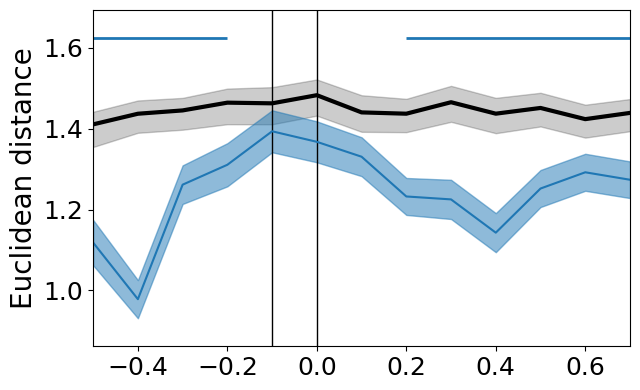

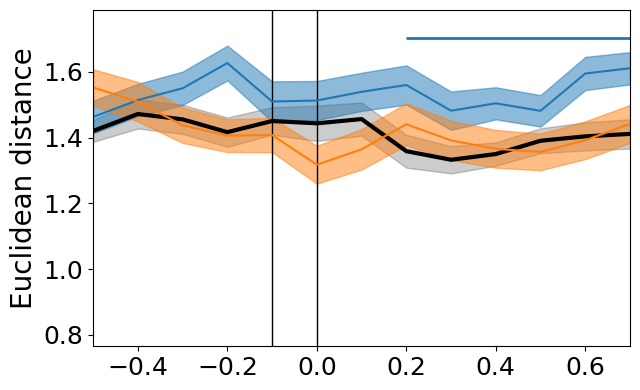

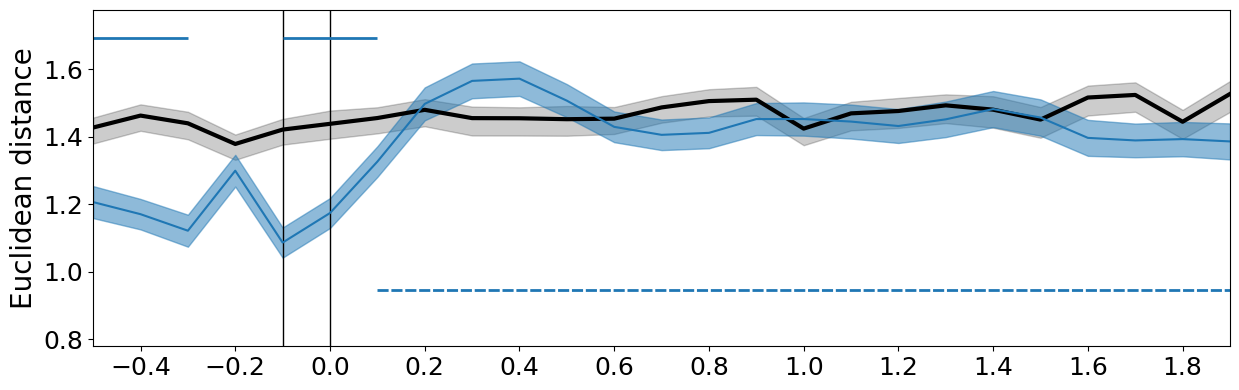

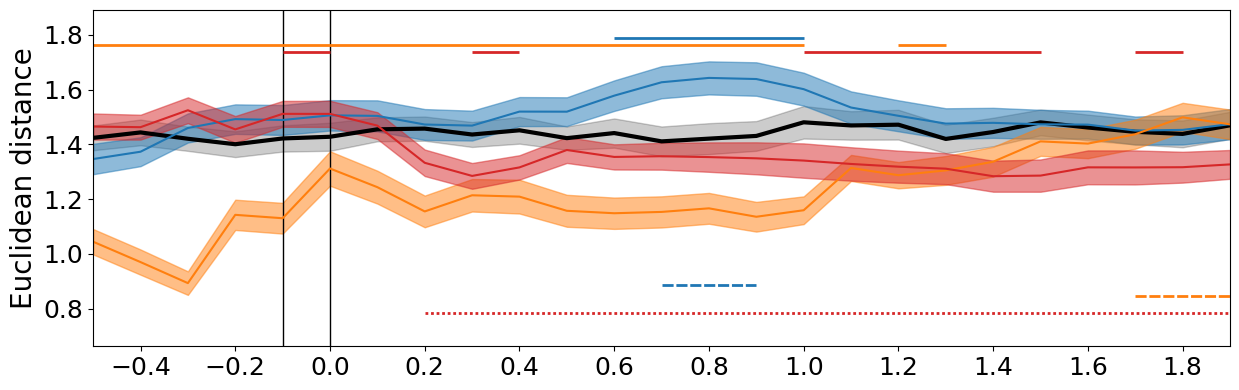

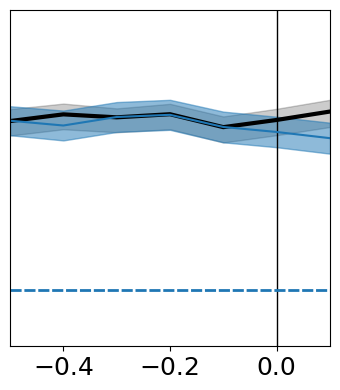

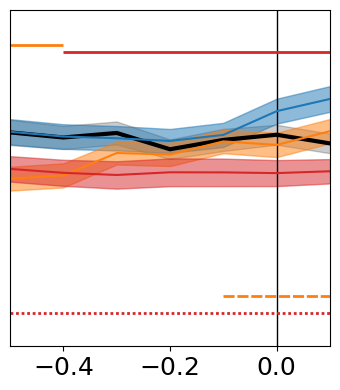

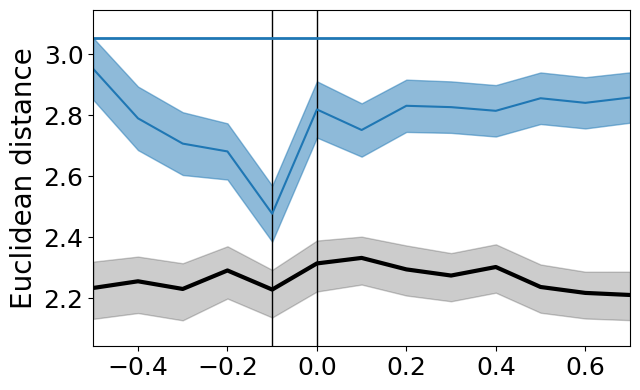

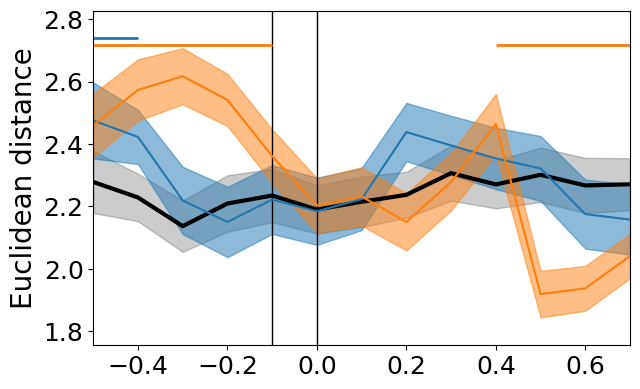

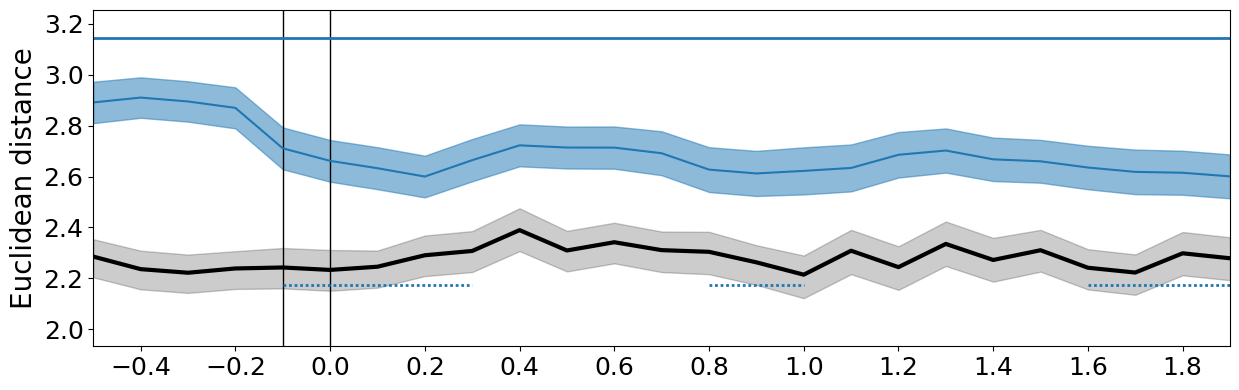

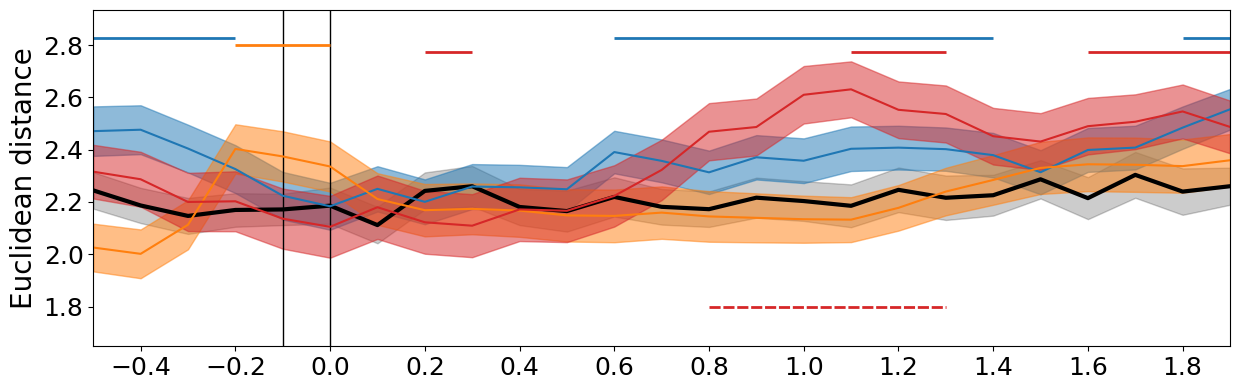

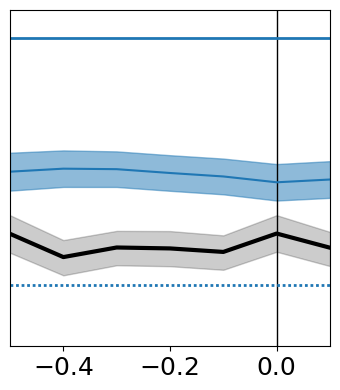

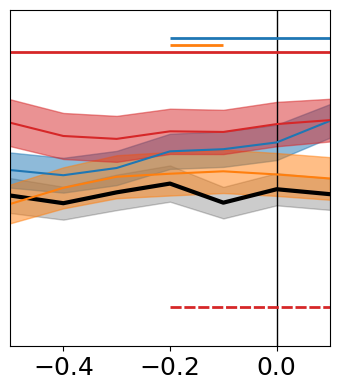

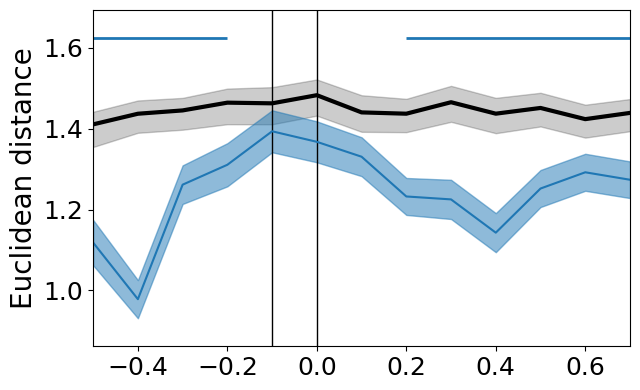

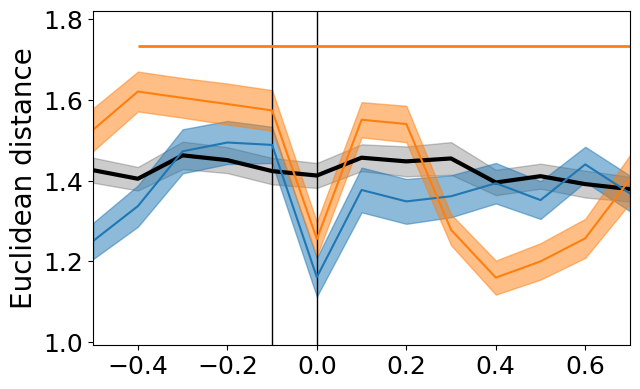

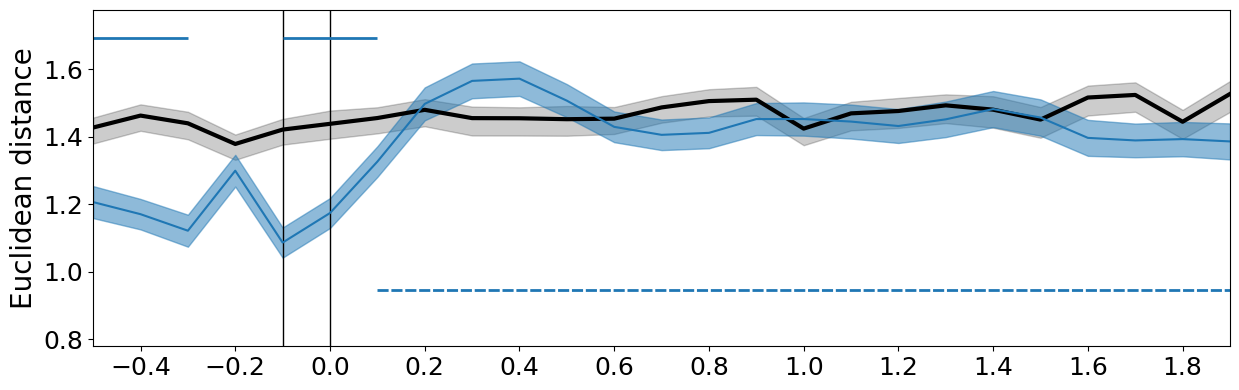

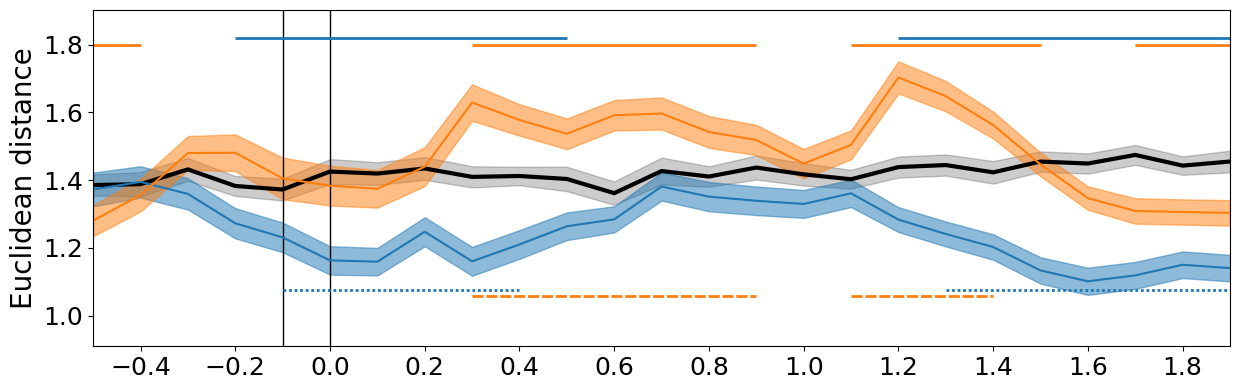

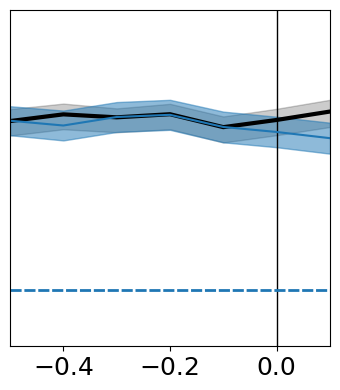

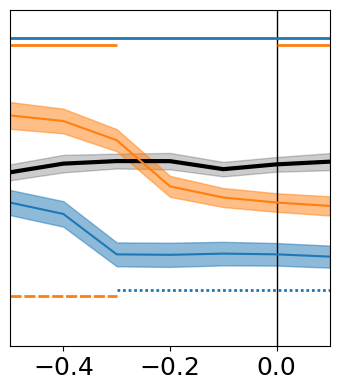

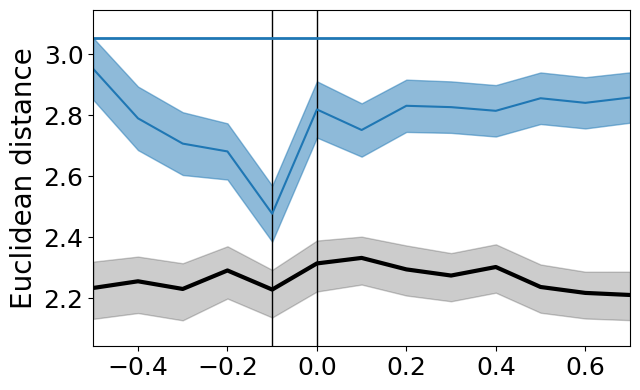

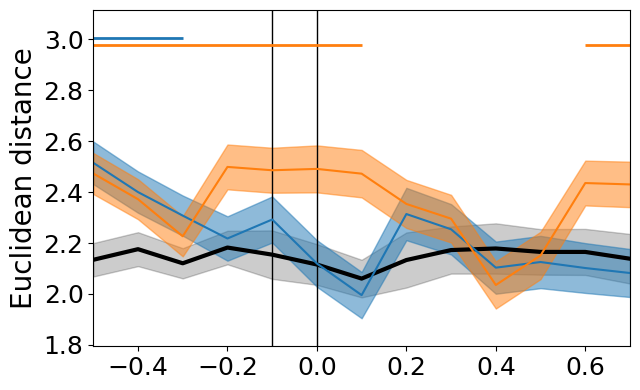

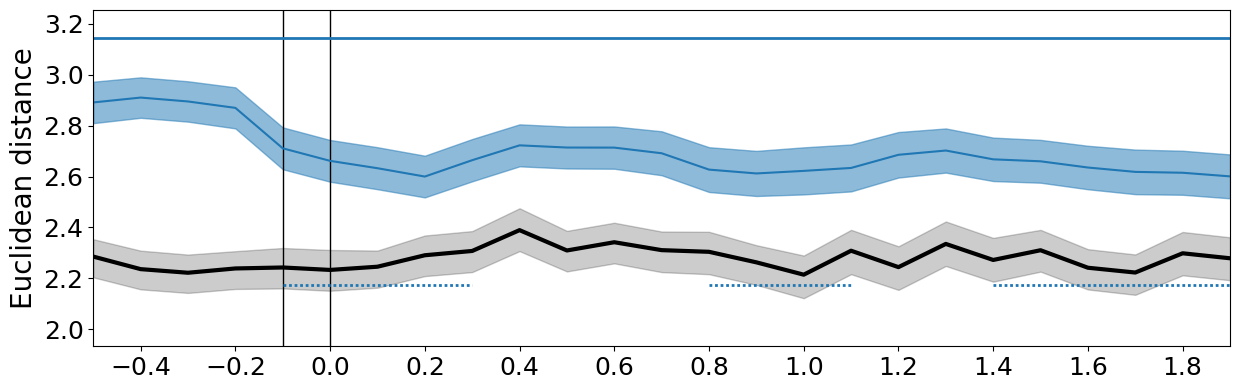

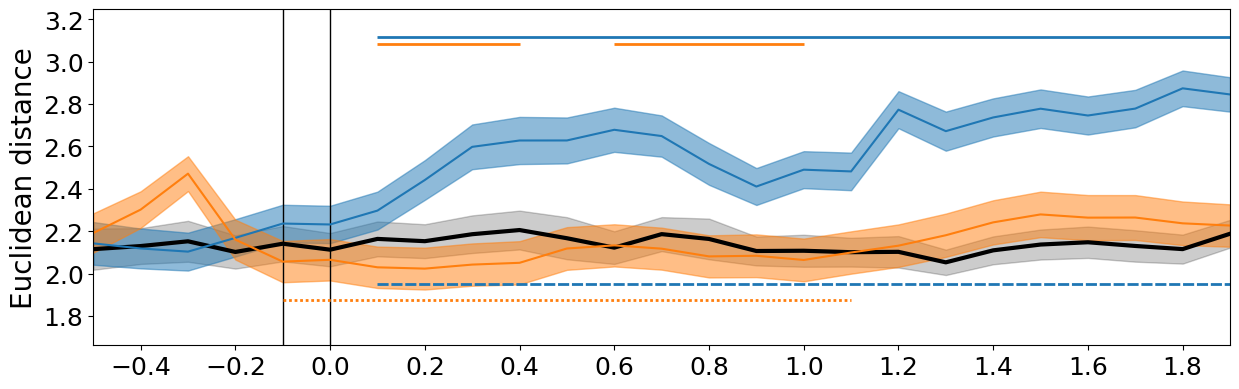

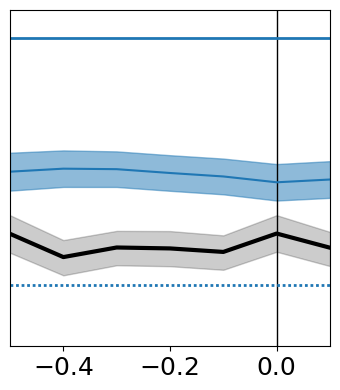

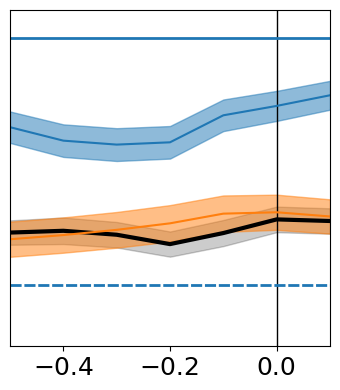

In [13]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'separability_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_05_polygons_by_load')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

### apply FDR to all the concatenated p_values (separately for each contrast)

p_values_uncorrected_list_surrogate_relevant = {}
p_values_uncorrected_list_surrogate_nonrelevant = {}
p_values_uncorrected_list_surrogate_control = {}
p_values_uncorrected_list_surrogate_nolonger = {}

p_values_uncorrected_list_cue_relevant = {}
p_values_uncorrected_list_cue_nonrelevant = {}
p_values_uncorrected_list_cue_control = {}
p_values_uncorrected_list_cue_nolonger = {}

p_values_corrected_list_surrogate_relevant = {}
p_values_corrected_list_surrogate_nonrelevant = {}
p_values_corrected_list_surrogate_control = {}
p_values_corrected_list_surrogate_nolonger = {}

p_values_corrected_list_cue_relevant = {}
p_values_corrected_list_cue_nonrelevant = {}
p_values_corrected_list_cue_control = {}
p_values_corrected_list_cue_nolonger = {}

t_values_list_cue_relevant = {}
t_values_list_cue_nonrelevant = {}
t_values_list_cue_control = {}
t_values_list_cue_nolonger = {}

for condition_i in conditions:

    for load_i in [1, 2]:

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control = data_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            data_relevant = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            # non-relevant
            data_nonrelevant = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            if condition_i == 'update':

                # no longer relevant
                data_nolonger = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control = surrogate_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            surrogate_relevant = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            # non-relevant
            surrogate_nonrelevant = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']








            # -----------------------------------------
            # Run statistical tests - surrogate effect
            # -----------------------------------------
 
            ## control
            p_values = []
            for t in range(data_control.shape[1]):
                _, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## relevant
            p_values = []
            for t in range(data_relevant.shape[1]):
                _, p = ttest_rel(data_relevant[:, t], surrogate_relevant[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## nonrelevant
            p_values = []
            for t in range(data_nonrelevant.shape[1]):
                _, p = ttest_rel(data_nonrelevant[:, t], surrogate_nonrelevant[:, t])
                p_values.append(p)

            # pool p-values 
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            if condition_i == 'update':

                ## nolongerrelevant
                p_values = []
                for t in range(data_nolonger.shape[1]):
                    _, p = ttest_rel(data_nolonger[:, t], surrogate_nolonger[:, t])
                    p_values.append(p)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                p_values_uncorrected_list_surrogate_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values


            # -----------------------------------
            # Run statistical tests - cue effect
            # -----------------------------------

            if time_window == 'encode':

                data_encode_avg_control = data_control.copy()
                data_encode_avg_relevant = data_relevant.copy()
                data_encode_avg_nonrelevant = data_nonrelevant.copy()
                if condition_i == 'update':
                    data_encode_avg_nolonger = data_nolonger.copy()

            if time_window == 'maint':

                data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)
                data_encode_avg_control = np.mean(data_encode_avg_control[:,5:18], axis=1)

                data_encode_avg_relevant = np.concatenate((data_encode_avg_relevant, data_relevant), axis=1)
                data_encode_avg_nonrelevant = np.concatenate((data_encode_avg_nonrelevant, data_nonrelevant), axis=1)

                data_encode_avg_relevant = np.mean(data_encode_avg_relevant[:,5:18], axis=1)
                data_encode_avg_nonrelevant = np.mean(data_encode_avg_nonrelevant[:,5:18], axis=1)

                if condition_i == 'update':
                    data_encode_avg_nolonger = np.concatenate((data_encode_avg_nolonger, data_nolonger), axis=1)
                    data_encode_avg_nolonger = np.mean(data_encode_avg_nolonger[:,5:18], axis=1)

            if time_window != 'encode': # not used here

                ## control

                p_values = []
                t_values = []
                for t in range(data_control.shape[1]):
                    t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = t_values
                
                ## relevant

                p_values = []
                t_values = []
                for t in range(data_relevant.shape[1]):
                    t, p = ttest_rel(data_relevant[:, t], data_encode_avg_relevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values

                ## non-relevant

                p_values = []
                t_values = []
                for t in range(data_nonrelevant.shape[1]):
                    t, p = ttest_rel(data_nonrelevant[:, t], data_encode_avg_nonrelevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values


                ## nolonger

                if condition_i == 'update':

                    p_values = []
                    t_values = []
                    for t in range(data_nolonger.shape[1]):
                        t, p = ttest_rel(data_nolonger[:, t], data_encode_avg_nolonger)
                        p_values.append(p)
                        t_values.append(t)

                    # pool p-values
                    p_values = np.array(p_values)
                    p_values = np.nan_to_num(p_values, nan=1.0)

                    # pool t-values
                    t_values = np.array(t_values)
                    t_values = np.nan_to_num(t_values, nan=1.0)

                    p_values_uncorrected_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                    t_values_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = t_values





##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [1, 2]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        for time_window in time_windows:

            base_key = f"{time_window}_{condition_i}_{load_i}"

            # control
            vals = p_values_uncorrected_list_surrogate_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))
                
            # relevant
            vals = p_values_uncorrected_list_surrogate_relevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("relevant", base_key, len(vals)))

            # nonrelevant
            vals = p_values_uncorrected_list_surrogate_nonrelevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("nonrelevant", base_key, len(vals)))


            # nolonger
            if condition_i == 'update':

                vals = p_values_uncorrected_list_surrogate_nolonger[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_surrogate_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_surrogate_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_surrogate_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_surrogate_nolonger[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [1, 2]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        # vectorize uncorrected p_values
        for time_window in time_windows:

            if time_window != 'encode':

                base_key = f"{time_window}_{condition_i}_{load_i}"

                # control
                vals = p_values_uncorrected_list_cue_control[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("control", base_key, len(vals)))

                # relevant
                vals = p_values_uncorrected_list_cue_relevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("relevant", base_key, len(vals)))

                # nonrelevant
                vals = p_values_uncorrected_list_cue_nonrelevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nonrelevant", base_key, len(vals)))

                # nolonger
                if condition_i == 'update':

                    vals = p_values_uncorrected_list_cue_nolonger[base_key]
                    p_values_uncorrected.extend(vals)
                    keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_cue_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_cue_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_cue_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_cue_nolonger[key] = corrected_vals



















### plots

for condition_i in conditions:

    for load_i in [1, 2]:

        # find common y-axis limits

        global_ymin = np.inf
        global_ymax = -np.inf

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control = data_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            data_relevant = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            # non-relevant
            data_nonrelevant = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            if condition_i == 'update':

                # no longer relevant
                data_nolonger = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control = surrogate_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            surrogate_relevant = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            # non-relevant
            surrogate_nonrelevant = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']



            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])


            # control limits

            ymax = np.max(((mean_control + std_control).max(), (mean_control_surrogate + std_control_surrogate).max()))
            ymin = np.min(((mean_control - std_control).min(), (mean_control_surrogate - std_control_surrogate).min()))

            if time_window == 'encode':

                global_ymin_control = ymin
                global_ymax_control = ymax

            else:

                if ymax > global_ymax_control:
                    global_ymax_control = ymax
                if ymin < global_ymin_control:
                    global_ymin_control = ymin

            # experimental limits

            if condition_i == 'update':

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_nolonger + std_nolonger).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max(), (mean_nolonger_surrogate + std_nolonger_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_nolonger - std_nolonger).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min(), (mean_nolonger_surrogate - std_nolonger_surrogate).min()))

            else:

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min()))

            if time_window == 'encode':

                global_ymin = ymin
                global_ymax = ymax

            else:

                if ymax > global_ymax:
                    global_ymax = ymax
                if ymin < global_ymin:
                    global_ymin = ymin


        # now, pass the code to do the actual plots

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control = data_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            data_relevant = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            # non-relevant
            data_nonrelevant = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            if condition_i == 'update':

                # no longer relevant
                data_nolonger = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control = surrogate_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            surrogate_relevant = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            # non-relevant
            surrogate_nonrelevant = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']


            # ------------------------------------------
            # FDR corrected p-values - surrogate effect
            # ------------------------------------------

            ## relevant

            p_values_corrected_list = p_values_corrected_list_surrogate_relevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_relevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## nonrelevant

            p_values_corrected_list = p_values_corrected_list_surrogate_nonrelevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_nonrelevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## control

            p_values_corrected_list = p_values_corrected_list_surrogate_control.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_control_surrogate = np.where(p_corrected < 0.025)[0]

            ## nolonger

            if condition_i == 'update':

                p_values_corrected_list = p_values_corrected_list_surrogate_nolonger.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]

                # Find significant timepoints
                significant_timepoints_nolonger_surrogate = np.where(p_corrected < 0.025)[0]







            # ------------------------------------
            # FDR corrected p-values - cue effect
            # ------------------------------------

            if time_window != 'encode':

                ## relevant 

                p_values_corrected_list = p_values_corrected_list_cue_relevant.copy()
                t_values_list = t_values_list_cue_relevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_relevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_relevant) > 0:

                    significant_timepoints_relevant_cue_positive = []
                    significant_timepoints_relevant_cue_negative = []

                    for p_i in significant_timepoints_relevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_relevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_relevant_cue_negative.append(p_i)

                    significant_timepoints_relevant_cue_positive = np.array(significant_timepoints_relevant_cue_positive)
                    significant_timepoints_relevant_cue_negative = np.array(significant_timepoints_relevant_cue_negative)

                else:

                    significant_timepoints_relevant_cue_positive = np.array([])
                    significant_timepoints_relevant_cue_negative = np.array([])

                ## non-relevant 

                p_values_corrected_list = p_values_corrected_list_cue_nonrelevant.copy()
                t_values_list = t_values_list_cue_nonrelevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_nonrelevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_nonrelevant) > 0:

                    significant_timepoints_nonrelevant_cue_positive = []
                    significant_timepoints_nonrelevant_cue_negative = []

                    for p_i in significant_timepoints_nonrelevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_nonrelevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_nonrelevant_cue_negative.append(p_i)

                    significant_timepoints_nonrelevant_cue_positive = np.array(significant_timepoints_nonrelevant_cue_positive)
                    significant_timepoints_nonrelevant_cue_negative = np.array(significant_timepoints_nonrelevant_cue_negative)

                else:

                    significant_timepoints_nonrelevant_cue_positive = np.array([])
                    significant_timepoints_nonrelevant_cue_negative = np.array([])

                ## control 

                p_values_corrected_list = p_values_corrected_list_cue_control.copy()
                t_values_list = t_values_list_cue_control.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_control = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_control) > 0:

                    significant_timepoints_control_cue_positive = []
                    significant_timepoints_control_cue_negative = []

                    for p_i in significant_timepoints_control:
                        if t_values[p_i] > 0:
                            significant_timepoints_control_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_control_cue_negative.append(p_i)

                    significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                    significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

                else:

                    significant_timepoints_control_cue_positive = np.array([])
                    significant_timepoints_control_cue_negative = np.array([])

                ## no-longer-relevant 

                if condition_i == 'update':

                    p_values_corrected_list = p_values_corrected_list_cue_nolonger.copy()
                    t_values_list = t_values_list_cue_nolonger.copy()

                    key = f"{time_window}_{condition_i}_{load_i}"
                    p_corrected = p_values_corrected_list[key]
                    t_values = t_values_list[key]

                    # set to one the p-values from timepoints before the cue
                    if time_window == 'maint':
                        p_corrected[0:4] = 1

                    # Find significant timepoints
                    significant_timepoints_nolonger = np.where(p_corrected < 0.025)[0]

                    # split positive and negative t-values
                    if len(significant_timepoints_nolonger) > 0:

                        significant_timepoints_nolonger_cue_positive = []
                        significant_timepoints_nolonger_cue_negative = []

                        for p_i in significant_timepoints_nolonger:
                            if t_values[p_i] > 0:
                                significant_timepoints_nolonger_cue_positive.append(p_i)
                            elif t_values[p_i] < 0:
                                significant_timepoints_nolonger_cue_negative.append(p_i)

                        significant_timepoints_nolonger_cue_positive = np.array(significant_timepoints_nolonger_cue_positive)
                        significant_timepoints_nolonger_cue_negative = np.array(significant_timepoints_nolonger_cue_negative)

                    else:

                        significant_timepoints_nolonger_cue_positive = np.array([])
                        significant_timepoints_nolonger_cue_negative = np.array([])




            # ---------------------
            # Time axis
            # ---------------------
            time = (np.arange(data_relevant.shape[1]) - index_of_zero)* 0.1 # sec

            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])








            # ---------------------
            # Plot - control
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)


            ## surrogate

            # control condition
            plt.plot(time, mean_control_surrogate, label='Control', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_control_surrogate - std_control, mean_control_surrogate + std_control_surrogate, alpha=0.2, color='black')

            ## observed

            # control condition
            plt.plot(time, mean_control, label='Control', color='tab:blue')
            plt.fill_between(time, mean_control - std_control, mean_control + std_control, alpha=0.5, color='tab:blue')


            # y-axis limits
            padding = 0.1 * (global_ymax_control - global_ymin_control)
            global_ymin_control -= padding
            global_ymax_control += padding
            plt.ylim(global_ymin_control, global_ymax_control)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # control

            if significant_timepoints_control_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax_control - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # control positive

                if significant_timepoints_control_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  

                # control negative

                if significant_timepoints_control_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  

            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)

            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_control_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()





            # ---------------------
            # Plot - experimental conditions (inhibition or update)
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)

            ## surrogate

            # Relevant
            plt.plot(time, mean_rel_surrogate, label='Relevant', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_rel_surrogate - std_rel_surrogate, mean_rel_surrogate + std_rel_surrogate, alpha=0.2, color='black')

            ## observed

            # Relevant
            plt.plot(time, mean_rel, label='Relevant', color='tab:blue')
            plt.fill_between(time, mean_rel - std_rel, mean_rel + std_rel, alpha=0.5, color='tab:blue')

            # Nonrelevant
            plt.plot(time, mean_nonrel, label='Nonrelevant', color='tab:orange')
            plt.fill_between(time, mean_nonrel - std_nonrel, mean_nonrel + std_nonrel, alpha=0.5, color='tab:orange')

            if condition_i == 'update' and time_window != 'encode':

                # no-longer-relevant
                plt.plot(time, mean_nolonger, label='Nolonger', color="tab:red")
                plt.fill_between(time, mean_nolonger - std_nolonger, mean_nolonger + std_nolonger, alpha=0.5, color="tab:red")



            # y-axis limits
            padding = 0.1 * (global_ymax - global_ymin)
            global_ymin -= padding
            global_ymax += padding
            plt.ylim(global_ymin, global_ymax)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # relevant

            if significant_timepoints_relevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_relevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            # nonrelevant

            if significant_timepoints_nonrelevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding - (padding * 0.25)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_nonrelevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2)

            # nolonger

            if condition_i == 'update' and time_window != 'encode':

                if significant_timepoints_nolonger_surrogate.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymax - padding - (padding * 0.5)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nolonger_surrogate), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # relevant - positive

                if significant_timepoints_relevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

                # relevant - negative

                if significant_timepoints_relevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  


                # non-relevant positive

                if significant_timepoints_nonrelevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.8)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (4, 1)))  

                # non-relevant negative

                if significant_timepoints_nonrelevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.6)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (1, 1)))  


                # nolonger positive

                if condition_i == 'update':

                    if significant_timepoints_nolonger_cue_positive.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.4)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_positive), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  

                    # nolonger negative

                    if significant_timepoints_nolonger_cue_negative.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.2)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_negative), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  




            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)


            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_' + condition_i + '_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()




# Gratings - separate by load (1, 2)

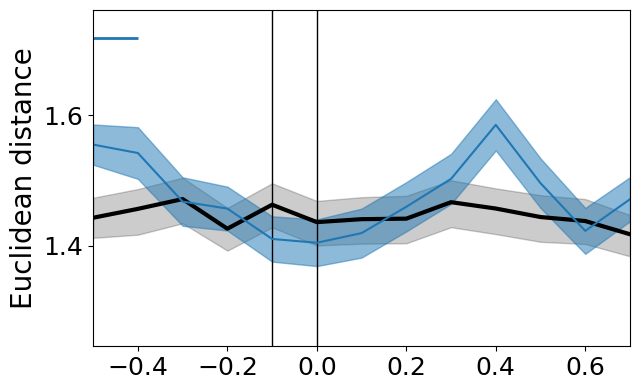

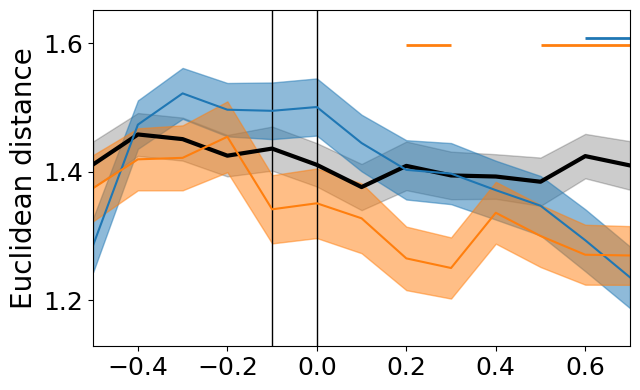

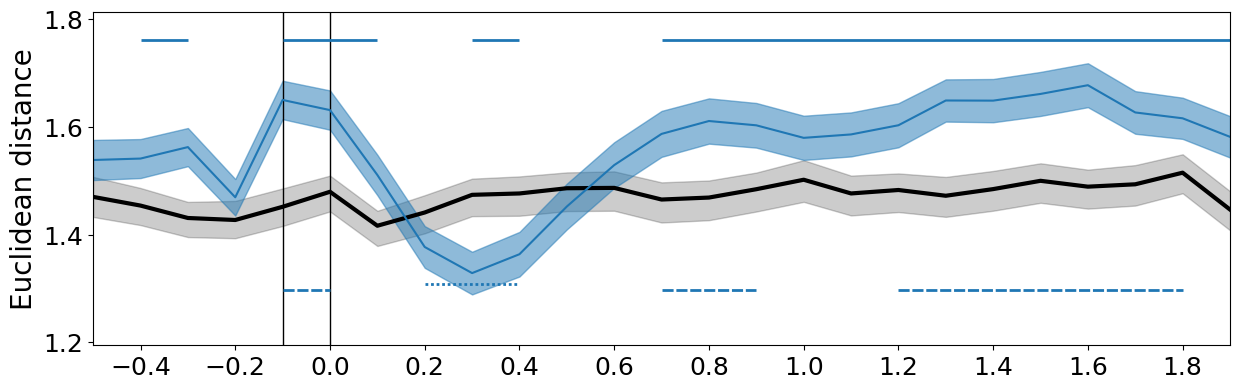

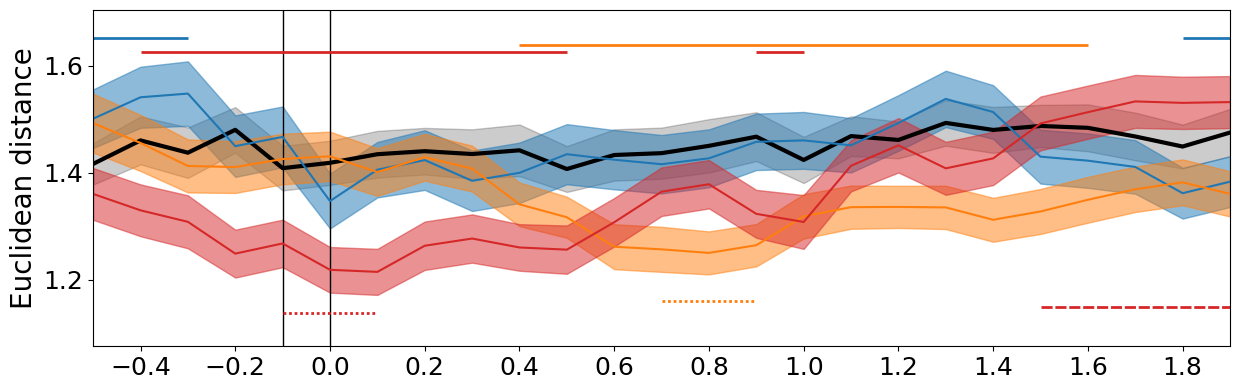

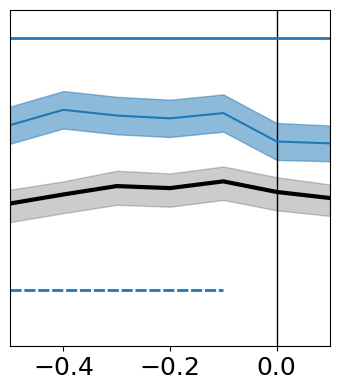

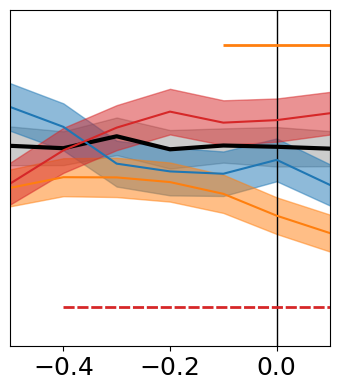

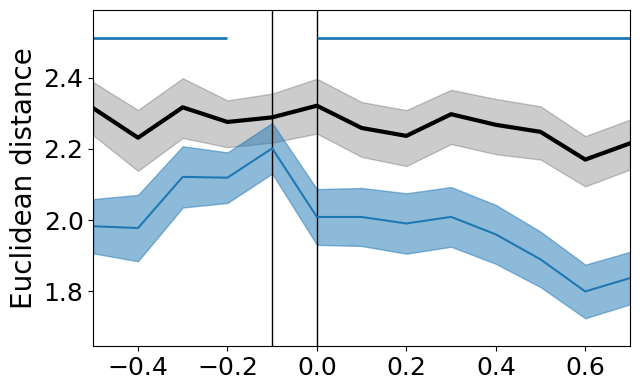

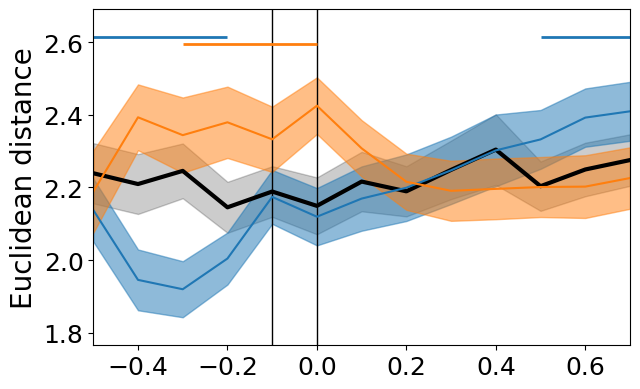

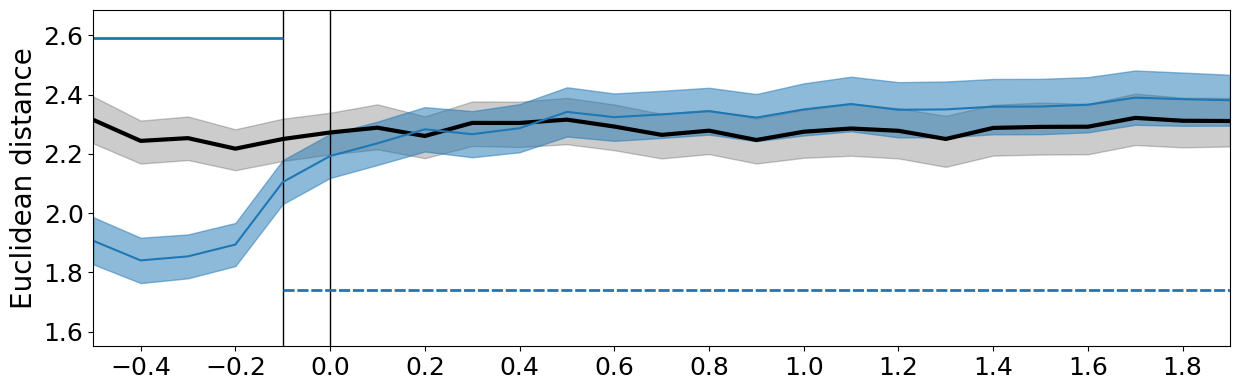

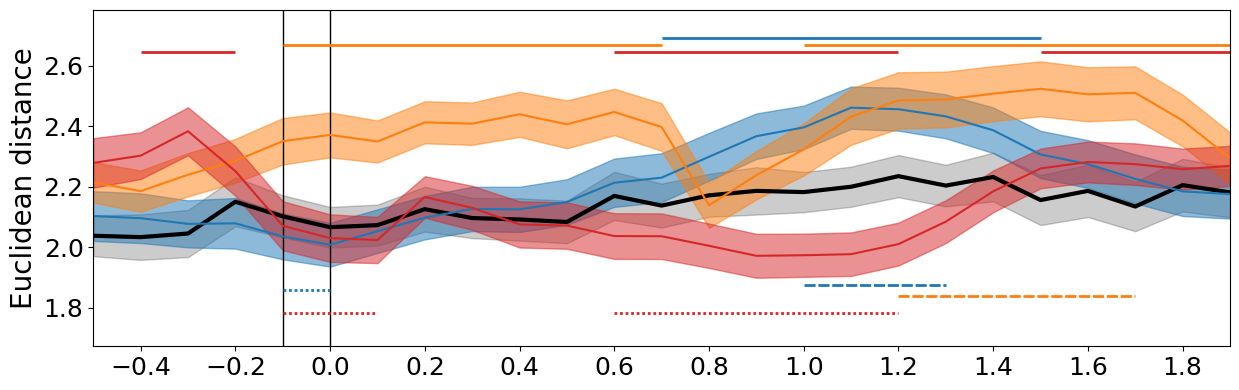

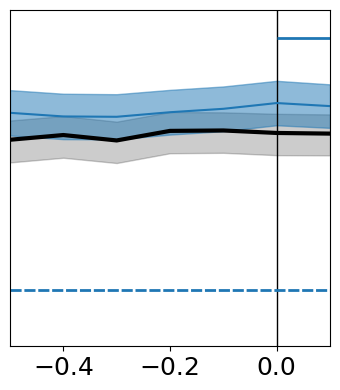

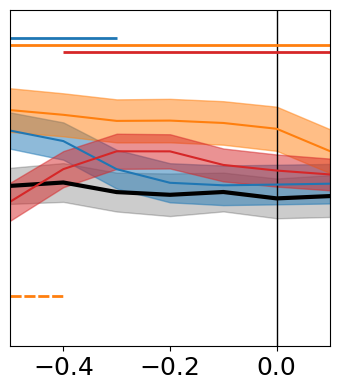

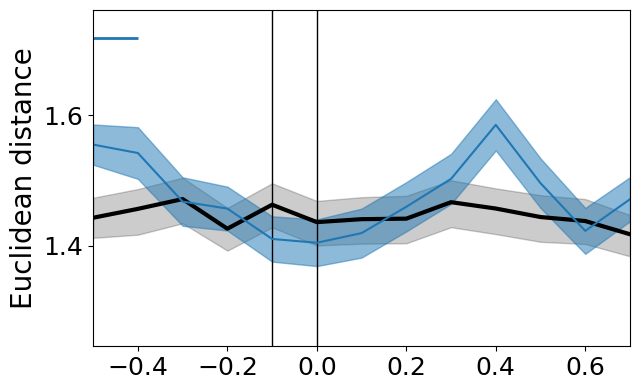

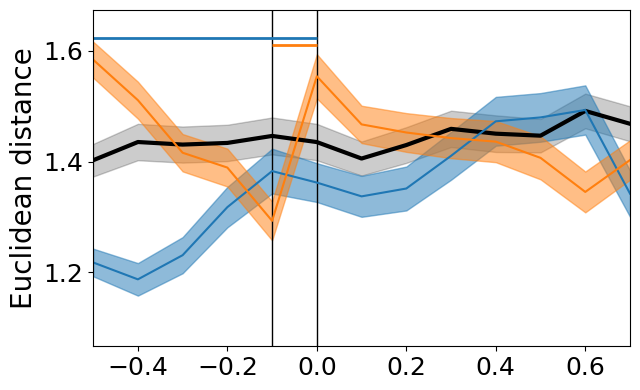

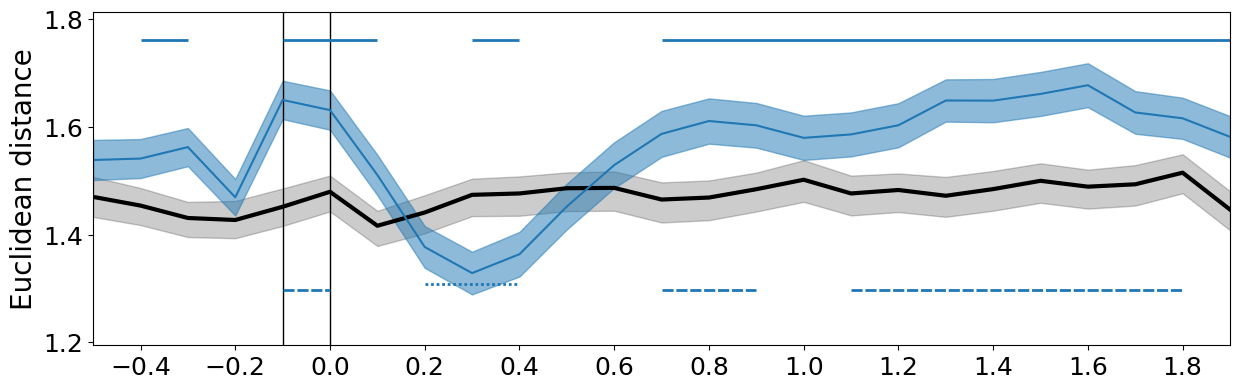

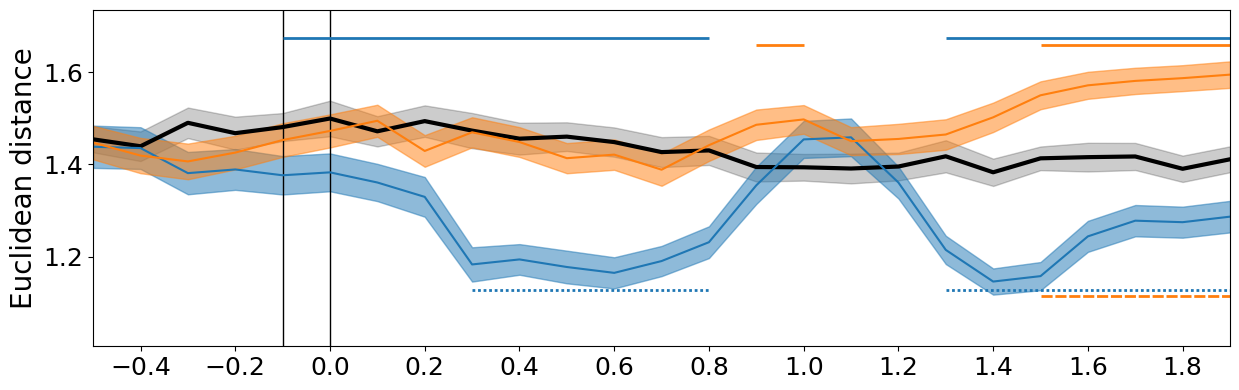

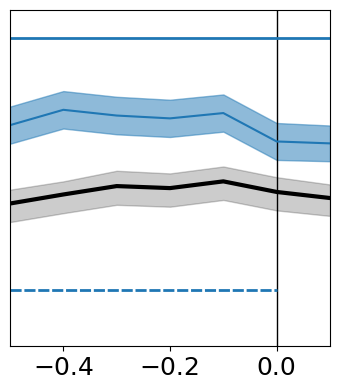

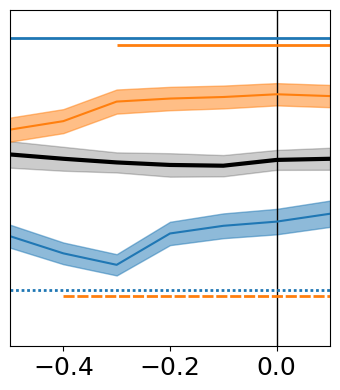

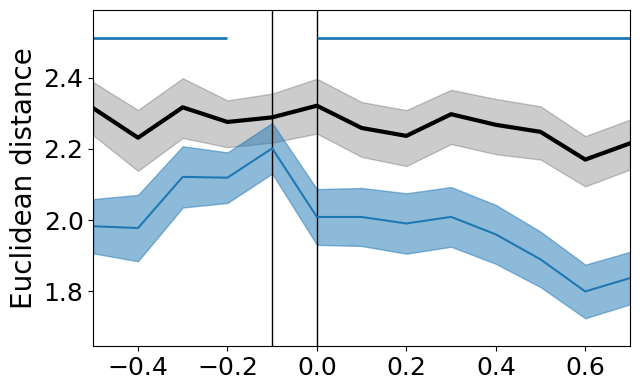

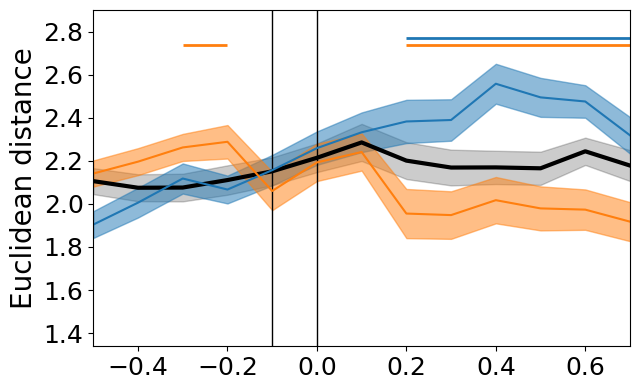

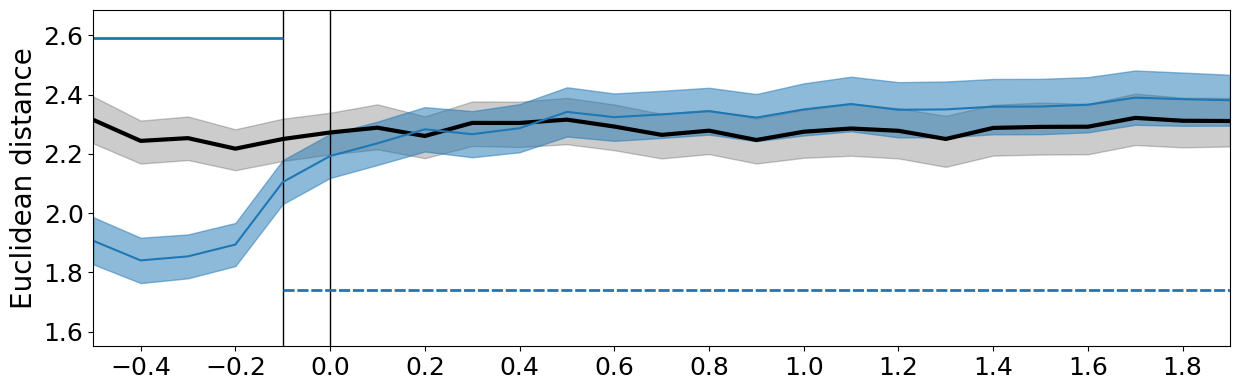

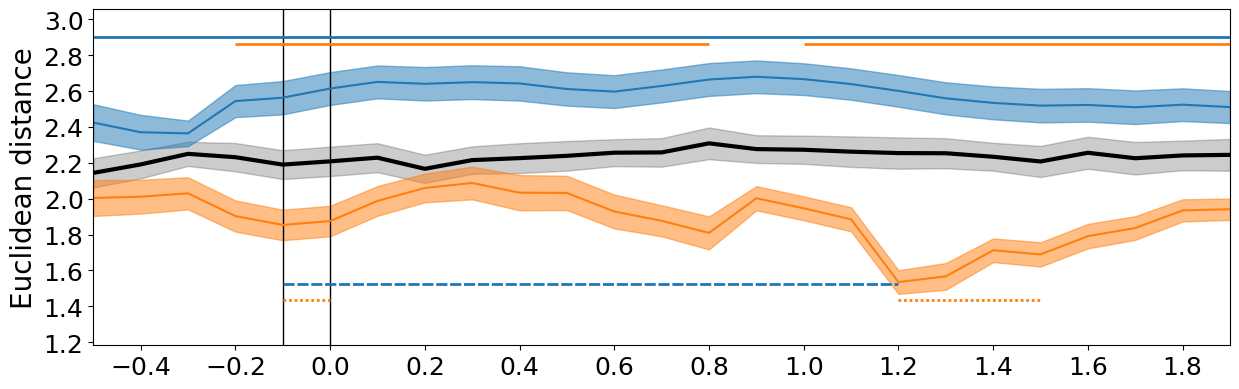

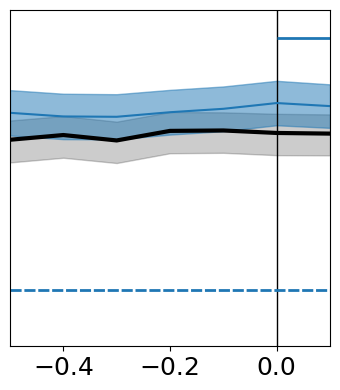

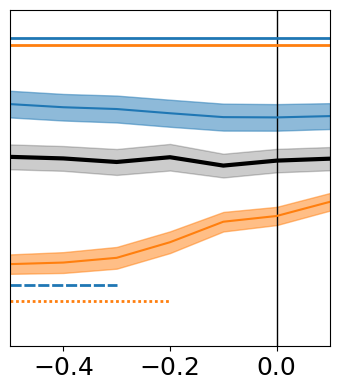

In [14]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'separability_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_06_gratings_by_load')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

### apply FDR to all the concatenated p_values (separately for each contrast)

p_values_uncorrected_list_surrogate_relevant = {}
p_values_uncorrected_list_surrogate_nonrelevant = {}
p_values_uncorrected_list_surrogate_control = {}
p_values_uncorrected_list_surrogate_nolonger = {}

p_values_uncorrected_list_cue_relevant = {}
p_values_uncorrected_list_cue_nonrelevant = {}
p_values_uncorrected_list_cue_control = {}
p_values_uncorrected_list_cue_nolonger = {}

p_values_corrected_list_surrogate_relevant = {}
p_values_corrected_list_surrogate_nonrelevant = {}
p_values_corrected_list_surrogate_control = {}
p_values_corrected_list_surrogate_nolonger = {}

p_values_corrected_list_cue_relevant = {}
p_values_corrected_list_cue_nonrelevant = {}
p_values_corrected_list_cue_control = {}
p_values_corrected_list_cue_nolonger = {}

t_values_list_cue_relevant = {}
t_values_list_cue_nonrelevant = {}
t_values_list_cue_control = {}
t_values_list_cue_nolonger = {}

for condition_i in conditions:

    for load_i in [1, 2]:

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control = data_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            data_relevant = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            # non-relevant
            data_nonrelevant = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            if condition_i == 'update':

                # no longer relevant
                data_nolonger = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control = surrogate_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            surrogate_relevant = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            # non-relevant
            surrogate_nonrelevant = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']








            # -----------------------------------------
            # Run statistical tests - surrogate effect
            # -----------------------------------------
 
            ## control
            p_values = []
            for t in range(data_control.shape[1]):
                _, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## relevant
            p_values = []
            for t in range(data_relevant.shape[1]):
                _, p = ttest_rel(data_relevant[:, t], surrogate_relevant[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## nonrelevant
            p_values = []
            for t in range(data_nonrelevant.shape[1]):
                _, p = ttest_rel(data_nonrelevant[:, t], surrogate_nonrelevant[:, t])
                p_values.append(p)

            # pool p-values 
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            if condition_i == 'update':

                ## nolongerrelevant
                p_values = []
                for t in range(data_nolonger.shape[1]):
                    _, p = ttest_rel(data_nolonger[:, t], surrogate_nolonger[:, t])
                    p_values.append(p)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                p_values_uncorrected_list_surrogate_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values


            # -----------------------------------
            # Run statistical tests - cue effect
            # -----------------------------------

            if time_window == 'encode':

                data_encode_avg_control = data_control.copy()
                data_encode_avg_relevant = data_relevant.copy()
                data_encode_avg_nonrelevant = data_nonrelevant.copy()
                if condition_i == 'update':
                    data_encode_avg_nolonger = data_nolonger.copy()

            if time_window == 'maint':

                data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)
                data_encode_avg_control = np.mean(data_encode_avg_control[:,5:18], axis=1)

                data_encode_avg_relevant = np.concatenate((data_encode_avg_relevant, data_relevant), axis=1)
                data_encode_avg_nonrelevant = np.concatenate((data_encode_avg_nonrelevant, data_nonrelevant), axis=1)

                data_encode_avg_relevant = np.mean(data_encode_avg_relevant[:,5:18], axis=1)
                data_encode_avg_nonrelevant = np.mean(data_encode_avg_nonrelevant[:,5:18], axis=1)

                if condition_i == 'update':
                    data_encode_avg_nolonger = np.concatenate((data_encode_avg_nolonger, data_nolonger), axis=1)
                    data_encode_avg_nolonger = np.mean(data_encode_avg_nolonger[:,5:18], axis=1)

            if time_window != 'encode': # not used here

                ## control

                p_values = []
                t_values = []
                for t in range(data_control.shape[1]):
                    t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = t_values
                
                ## relevant

                p_values = []
                t_values = []
                for t in range(data_relevant.shape[1]):
                    t, p = ttest_rel(data_relevant[:, t], data_encode_avg_relevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values

                ## non-relevant

                p_values = []
                t_values = []
                for t in range(data_nonrelevant.shape[1]):
                    t, p = ttest_rel(data_nonrelevant[:, t], data_encode_avg_nonrelevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values


                ## nolonger

                if condition_i == 'update':

                    p_values = []
                    t_values = []
                    for t in range(data_nolonger.shape[1]):
                        t, p = ttest_rel(data_nolonger[:, t], data_encode_avg_nolonger)
                        p_values.append(p)
                        t_values.append(t)

                    # pool p-values
                    p_values = np.array(p_values)
                    p_values = np.nan_to_num(p_values, nan=1.0)

                    # pool t-values
                    t_values = np.array(t_values)
                    t_values = np.nan_to_num(t_values, nan=1.0)

                    p_values_uncorrected_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                    t_values_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = t_values





##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [1, 2]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        for time_window in time_windows:

            base_key = f"{time_window}_{condition_i}_{load_i}"

            # control
            vals = p_values_uncorrected_list_surrogate_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))
                
            # relevant
            vals = p_values_uncorrected_list_surrogate_relevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("relevant", base_key, len(vals)))

            # nonrelevant
            vals = p_values_uncorrected_list_surrogate_nonrelevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("nonrelevant", base_key, len(vals)))


            # nolonger
            if condition_i == 'update':

                vals = p_values_uncorrected_list_surrogate_nolonger[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_surrogate_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_surrogate_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_surrogate_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_surrogate_nolonger[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [1, 2]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        # vectorize uncorrected p_values
        for time_window in time_windows:

            if time_window != 'encode':

                base_key = f"{time_window}_{condition_i}_{load_i}"

                # control
                vals = p_values_uncorrected_list_cue_control[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("control", base_key, len(vals)))

                # relevant
                vals = p_values_uncorrected_list_cue_relevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("relevant", base_key, len(vals)))

                # nonrelevant
                vals = p_values_uncorrected_list_cue_nonrelevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nonrelevant", base_key, len(vals)))

                # nolonger
                if condition_i == 'update':

                    vals = p_values_uncorrected_list_cue_nolonger[base_key]
                    p_values_uncorrected.extend(vals)
                    keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_cue_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_cue_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_cue_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_cue_nolonger[key] = corrected_vals



















### plots

for condition_i in conditions:

    for load_i in [1, 2]:

        # find common y-axis limits

        global_ymin = np.inf
        global_ymax = -np.inf

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control = data_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            data_relevant = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            # non-relevant
            data_nonrelevant = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            if condition_i == 'update':

                # no longer relevant
                data_nolonger = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control = surrogate_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            surrogate_relevant = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            # non-relevant
            surrogate_nonrelevant = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']




            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])


            # control limits

            ymax = np.max(((mean_control + std_control).max(), (mean_control_surrogate + std_control_surrogate).max()))
            ymin = np.min(((mean_control - std_control).min(), (mean_control_surrogate - std_control_surrogate).min()))

            if time_window == 'encode':

                global_ymin_control = ymin
                global_ymax_control = ymax

            else:

                if ymax > global_ymax_control:
                    global_ymax_control = ymax
                if ymin < global_ymin_control:
                    global_ymin_control = ymin

            # experimental limits

            if condition_i == 'update':

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_nolonger + std_nolonger).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max(), (mean_nolonger_surrogate + std_nolonger_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_nolonger - std_nolonger).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min(), (mean_nolonger_surrogate - std_nolonger_surrogate).min()))

            else:

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min()))

            if time_window == 'encode':

                global_ymin = ymin
                global_ymax = ymax

            else:

                if ymax > global_ymax:
                    global_ymax = ymax
                if ymin < global_ymin:
                    global_ymin = ymin


        # now, pass the code to do the actual plots

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control = data_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            data_relevant = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            # non-relevant
            data_nonrelevant = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            if condition_i == 'update':

                # no longer relevant
                data_nolonger = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control = surrogate_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

            # relevant
            surrogate_relevant = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']

            # non-relevant
            surrogate_nonrelevant = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']



            # ------------------------------------------
            # FDR corrected p-values - surrogate effect
            # ------------------------------------------

            ## relevant

            p_values_corrected_list = p_values_corrected_list_surrogate_relevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_relevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## nonrelevant

            p_values_corrected_list = p_values_corrected_list_surrogate_nonrelevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_nonrelevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## control

            p_values_corrected_list = p_values_corrected_list_surrogate_control.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_control_surrogate = np.where(p_corrected < 0.025)[0]

            ## nolonger

            if condition_i == 'update':

                p_values_corrected_list = p_values_corrected_list_surrogate_nolonger.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]

                # Find significant timepoints
                significant_timepoints_nolonger_surrogate = np.where(p_corrected < 0.025)[0]







            # ------------------------------------
            # FDR corrected p-values - cue effect
            # ------------------------------------

            if time_window != 'encode':

                ## relevant 

                p_values_corrected_list = p_values_corrected_list_cue_relevant.copy()
                t_values_list = t_values_list_cue_relevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_relevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_relevant) > 0:

                    significant_timepoints_relevant_cue_positive = []
                    significant_timepoints_relevant_cue_negative = []

                    for p_i in significant_timepoints_relevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_relevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_relevant_cue_negative.append(p_i)

                    significant_timepoints_relevant_cue_positive = np.array(significant_timepoints_relevant_cue_positive)
                    significant_timepoints_relevant_cue_negative = np.array(significant_timepoints_relevant_cue_negative)

                else:

                    significant_timepoints_relevant_cue_positive = np.array([])
                    significant_timepoints_relevant_cue_negative = np.array([])

                ## non-relevant 

                p_values_corrected_list = p_values_corrected_list_cue_nonrelevant.copy()
                t_values_list = t_values_list_cue_nonrelevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_nonrelevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_nonrelevant) > 0:

                    significant_timepoints_nonrelevant_cue_positive = []
                    significant_timepoints_nonrelevant_cue_negative = []

                    for p_i in significant_timepoints_nonrelevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_nonrelevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_nonrelevant_cue_negative.append(p_i)

                    significant_timepoints_nonrelevant_cue_positive = np.array(significant_timepoints_nonrelevant_cue_positive)
                    significant_timepoints_nonrelevant_cue_negative = np.array(significant_timepoints_nonrelevant_cue_negative)

                else:

                    significant_timepoints_nonrelevant_cue_positive = np.array([])
                    significant_timepoints_nonrelevant_cue_negative = np.array([])

                ## control 

                p_values_corrected_list = p_values_corrected_list_cue_control.copy()
                t_values_list = t_values_list_cue_control.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_control = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_control) > 0:

                    significant_timepoints_control_cue_positive = []
                    significant_timepoints_control_cue_negative = []

                    for p_i in significant_timepoints_control:
                        if t_values[p_i] > 0:
                            significant_timepoints_control_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_control_cue_negative.append(p_i)

                    significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                    significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

                else:

                    significant_timepoints_control_cue_positive = np.array([])
                    significant_timepoints_control_cue_negative = np.array([])

                ## no-longer-relevant 

                if condition_i == 'update':

                    p_values_corrected_list = p_values_corrected_list_cue_nolonger.copy()
                    t_values_list = t_values_list_cue_nolonger.copy()

                    key = f"{time_window}_{condition_i}_{load_i}"
                    p_corrected = p_values_corrected_list[key]
                    t_values = t_values_list[key]

                    # set to one the p-values from timepoints before the cue
                    if time_window == 'maint':
                        p_corrected[0:4] = 1

                    # Find significant timepoints
                    significant_timepoints_nolonger = np.where(p_corrected < 0.025)[0]

                    # split positive and negative t-values
                    if len(significant_timepoints_nolonger) > 0:

                        significant_timepoints_nolonger_cue_positive = []
                        significant_timepoints_nolonger_cue_negative = []

                        for p_i in significant_timepoints_nolonger:
                            if t_values[p_i] > 0:
                                significant_timepoints_nolonger_cue_positive.append(p_i)
                            elif t_values[p_i] < 0:
                                significant_timepoints_nolonger_cue_negative.append(p_i)

                        significant_timepoints_nolonger_cue_positive = np.array(significant_timepoints_nolonger_cue_positive)
                        significant_timepoints_nolonger_cue_negative = np.array(significant_timepoints_nolonger_cue_negative)

                    else:

                        significant_timepoints_nolonger_cue_positive = np.array([])
                        significant_timepoints_nolonger_cue_negative = np.array([])




            # ---------------------
            # Time axis
            # ---------------------
            time = (np.arange(data_relevant.shape[1]) - index_of_zero)* 0.1 # sec

            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])








            # ---------------------
            # Plot - control
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)


            ## surrogate

            # control condition
            plt.plot(time, mean_control_surrogate, label='Control', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_control_surrogate - std_control, mean_control_surrogate + std_control_surrogate, alpha=0.2, color='black')

            ## observed

            # control condition
            plt.plot(time, mean_control, label='Control', color='tab:blue')
            plt.fill_between(time, mean_control - std_control, mean_control + std_control, alpha=0.5, color='tab:blue')


            # y-axis limits
            padding = 0.1 * (global_ymax_control - global_ymin_control)
            global_ymin_control -= padding
            global_ymax_control += padding
            plt.ylim(global_ymin_control, global_ymax_control)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # control

            if significant_timepoints_control_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax_control - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # control positive

                if significant_timepoints_control_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  

                # control negative

                if significant_timepoints_control_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin_control + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_control_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  

            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)

            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_control_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()





            # ---------------------
            # Plot - experimental conditions (inhibition or update)
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)

            ## surrogate

            # Relevant
            plt.plot(time, mean_rel_surrogate, label='Relevant', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_rel_surrogate - std_rel_surrogate, mean_rel_surrogate + std_rel_surrogate, alpha=0.2, color='black')

            ## observed

            # Relevant
            plt.plot(time, mean_rel, label='Relevant', color='tab:blue')
            plt.fill_between(time, mean_rel - std_rel, mean_rel + std_rel, alpha=0.5, color='tab:blue')

            # Nonrelevant
            plt.plot(time, mean_nonrel, label='Nonrelevant', color='tab:orange')
            plt.fill_between(time, mean_nonrel - std_nonrel, mean_nonrel + std_nonrel, alpha=0.5, color='tab:orange')

            if condition_i == 'update' and time_window != 'encode':

                # no-longer-relevant
                plt.plot(time, mean_nolonger, label='Nolonger', color="tab:red")
                plt.fill_between(time, mean_nolonger - std_nolonger, mean_nolonger + std_nolonger, alpha=0.5, color="tab:red")



            # y-axis limits
            padding = 0.1 * (global_ymax - global_ymin)
            global_ymin -= padding
            global_ymax += padding
            plt.ylim(global_ymin, global_ymax)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # relevant

            if significant_timepoints_relevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_relevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            # nonrelevant

            if significant_timepoints_nonrelevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding - (padding * 0.25)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_nonrelevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2)

            # nolonger

            if condition_i == 'update' and time_window != 'encode':

                if significant_timepoints_nolonger_surrogate.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymax - padding - (padding * 0.5)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nolonger_surrogate), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # relevant - positive

                if significant_timepoints_relevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

                # relevant - negative

                if significant_timepoints_relevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  


                # non-relevant positive

                if significant_timepoints_nonrelevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.8)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (4, 1)))  

                # non-relevant negative

                if significant_timepoints_nonrelevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.6)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (1, 1)))  


                # nolonger positive

                if condition_i == 'update':

                    if significant_timepoints_nolonger_cue_positive.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.4)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_positive), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  

                    # nolonger negative

                    if significant_timepoints_nolonger_cue_negative.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.2)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_negative), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  




            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)


            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_' + condition_i + '_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()




# INCORRECT TRIALS

In [15]:
trial_type = 'incorrect_trials'

# Pool features (polygons, gratings) - Load 2

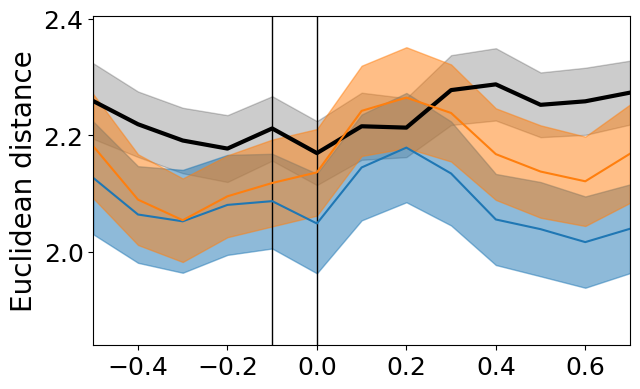

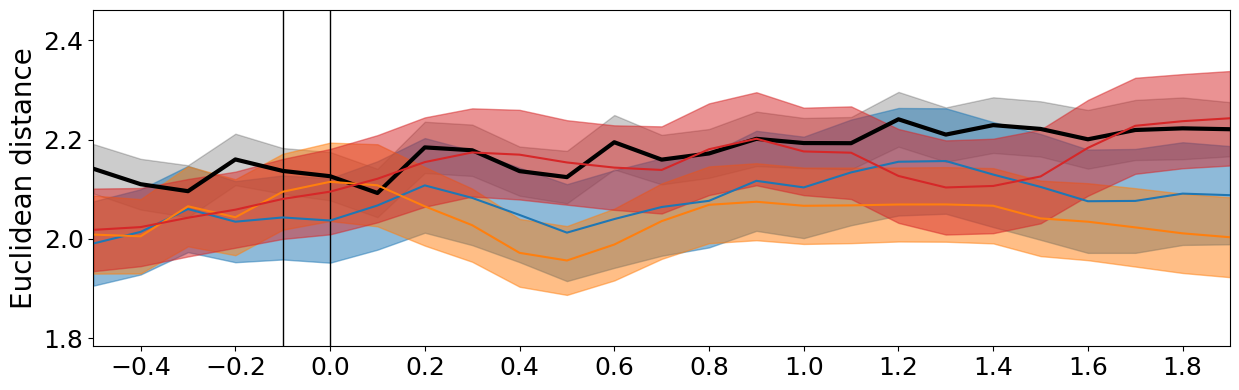

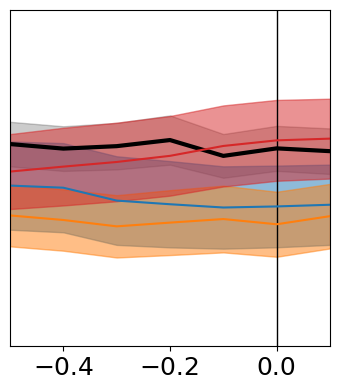

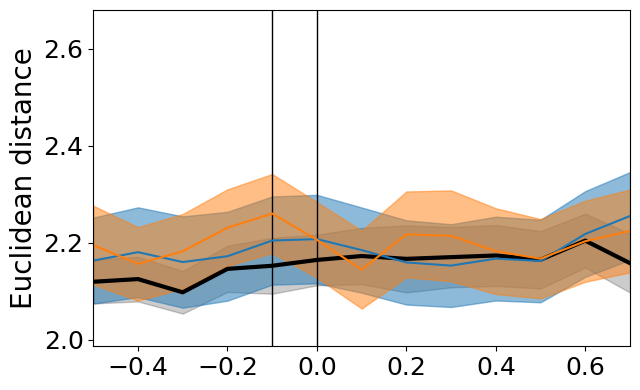

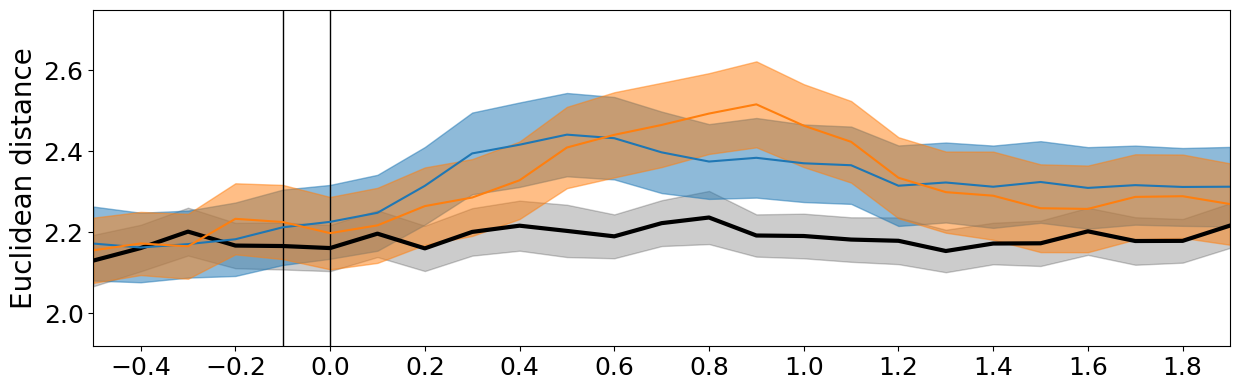

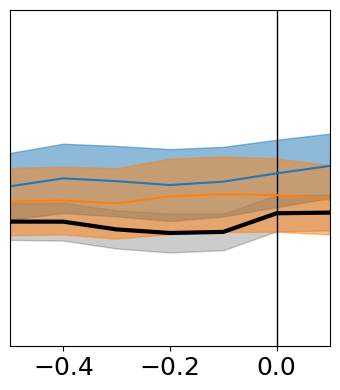

In [16]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'separability_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_01_pool_features_load2')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

### apply FDR to all the concatenated p_values (separately for each contrast)

p_values_uncorrected_list_surrogate_relevant = {}
p_values_uncorrected_list_surrogate_nonrelevant = {}
p_values_uncorrected_list_surrogate_control = {}
p_values_uncorrected_list_surrogate_nolonger = {}

p_values_uncorrected_list_cue_relevant = {}
p_values_uncorrected_list_cue_nonrelevant = {}
p_values_uncorrected_list_cue_control = {}
p_values_uncorrected_list_cue_nolonger = {}

p_values_corrected_list_surrogate_relevant = {}
p_values_corrected_list_surrogate_nonrelevant = {}
p_values_corrected_list_surrogate_control = {}
p_values_corrected_list_surrogate_nolonger = {}

p_values_corrected_list_cue_relevant = {}
p_values_corrected_list_cue_nonrelevant = {}
p_values_corrected_list_cue_control = {}
p_values_corrected_list_cue_nolonger = {}

t_values_list_cue_relevant = {}
t_values_list_cue_nonrelevant = {}
t_values_list_cue_control = {}
t_values_list_cue_nolonger = {}

for condition_i in conditions:

    for load_i in [2]:

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control = np.concat((data_control_orientation, data_control_shape), axis=0)

            # relevant
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_relevant = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)

            # non-relevant
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_nonrelevant = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                data_nolonger = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', 'correct_trials')

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)

            # relevant
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_relevant = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)

            # non-relevant
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)








            # -----------------------------------------
            # Run statistical tests - surrogate effect
            # -----------------------------------------
 
            ## control
            p_values = []
            for t in range(data_control.shape[1]):
                _, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## relevant
            p_values = []
            for t in range(data_relevant.shape[1]):
                _, p = ttest_rel(data_relevant[:, t], surrogate_relevant[:, t])
                p_values.append(p)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            ## nonrelevant
            p_values = []
            for t in range(data_nonrelevant.shape[1]):
                _, p = ttest_rel(data_nonrelevant[:, t], surrogate_nonrelevant[:, t])
                p_values.append(p)

            # pool p-values 
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            p_values_uncorrected_list_surrogate_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values

            if condition_i == 'update':

                ## nolongerrelevant
                p_values = []
                for t in range(data_nolonger.shape[1]):
                    _, p = ttest_rel(data_nolonger[:, t], surrogate_nolonger[:, t])
                    p_values.append(p)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                p_values_uncorrected_list_surrogate_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values


            # -----------------------------------
            # Run statistical tests - cue effect
            # -----------------------------------

            if time_window == 'encode':

                data_encode_avg_control = data_control.copy()
                data_encode_avg_relevant = data_relevant.copy()
                data_encode_avg_nonrelevant = data_nonrelevant.copy()
                if condition_i == 'update':
                    data_encode_avg_nolonger = data_nolonger.copy()

            if time_window == 'maint':

                data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)
                data_encode_avg_control = np.mean(data_encode_avg_control[:,5:18], axis=1)

                data_encode_avg_relevant = np.concatenate((data_encode_avg_relevant, data_relevant), axis=1)
                data_encode_avg_nonrelevant = np.concatenate((data_encode_avg_nonrelevant, data_nonrelevant), axis=1)

                data_encode_avg_relevant = np.mean(data_encode_avg_relevant[:,5:18], axis=1)
                data_encode_avg_nonrelevant = np.mean(data_encode_avg_nonrelevant[:,5:18], axis=1)

                if condition_i == 'update':
                    data_encode_avg_nolonger = np.concatenate((data_encode_avg_nolonger, data_nolonger), axis=1)
                    data_encode_avg_nolonger = np.mean(data_encode_avg_nolonger[:,5:18], axis=1)

            if time_window != 'encode': # not used here

                ## control

                p_values = []
                t_values = []
                for t in range(data_control.shape[1]):
                    t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_control[time_window + '_' + condition_i + '_' + str(load_i)] = t_values
                
                ## relevant

                p_values = []
                t_values = []
                for t in range(data_relevant.shape[1]):
                    t, p = ttest_rel(data_relevant[:, t], data_encode_avg_relevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_relevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values

                ## non-relevant

                p_values = []
                t_values = []
                for t in range(data_nonrelevant.shape[1]):
                    t, p = ttest_rel(data_nonrelevant[:, t], data_encode_avg_nonrelevant)
                    p_values.append(p)
                    t_values.append(t)

                # pool p-values
                p_values = np.array(p_values)
                p_values = np.nan_to_num(p_values, nan=1.0)

                # pool t-values
                t_values = np.array(t_values)
                t_values = np.nan_to_num(t_values, nan=1.0)

                p_values_uncorrected_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                t_values_list_cue_nonrelevant[time_window + '_' + condition_i + '_' + str(load_i)] = t_values


                ## nolonger

                if condition_i == 'update':

                    p_values = []
                    t_values = []
                    for t in range(data_nolonger.shape[1]):
                        t, p = ttest_rel(data_nolonger[:, t], data_encode_avg_nolonger)
                        p_values.append(p)
                        t_values.append(t)

                    # pool p-values
                    p_values = np.array(p_values)
                    p_values = np.nan_to_num(p_values, nan=1.0)

                    # pool t-values
                    t_values = np.array(t_values)
                    t_values = np.nan_to_num(t_values, nan=1.0)

                    p_values_uncorrected_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = p_values
                    t_values_list_cue_nolonger[time_window + '_' + condition_i + '_' + str(load_i)] = t_values





##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [2]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        for time_window in time_windows:

            base_key = f"{time_window}_{condition_i}_{load_i}"

            # control
            vals = p_values_uncorrected_list_surrogate_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))
                
            # relevant
            vals = p_values_uncorrected_list_surrogate_relevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("relevant", base_key, len(vals)))

            # nonrelevant
            vals = p_values_uncorrected_list_surrogate_nonrelevant[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("nonrelevant", base_key, len(vals)))


            # nolonger
            if condition_i == 'update':

                vals = p_values_uncorrected_list_surrogate_nolonger[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_surrogate_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_surrogate_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_surrogate_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_surrogate_nolonger[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for condition_i in conditions:

    for load_i in [2]:

        keys_order = []  # track (dict_name, key, n_vals)
        p_values_uncorrected = []

        # ------------------------------------------------------------------
        # vectorize uncorrected p_values
        # ------------------------------------------------------------------

        # vectorize uncorrected p_values
        for time_window in time_windows:

            if time_window != 'encode':

                base_key = f"{time_window}_{condition_i}_{load_i}"

                # control
                vals = p_values_uncorrected_list_cue_control[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("control", base_key, len(vals)))

                # relevant
                vals = p_values_uncorrected_list_cue_relevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("relevant", base_key, len(vals)))

                # nonrelevant
                vals = p_values_uncorrected_list_cue_nonrelevant[base_key]
                p_values_uncorrected.extend(vals)
                keys_order.append(("nonrelevant", base_key, len(vals)))

                # nolonger
                if condition_i == 'update':

                    vals = p_values_uncorrected_list_cue_nolonger[base_key]
                    p_values_uncorrected.extend(vals)
                    keys_order.append(("nolonger", base_key, len(vals)))

        p_values_uncorrected = np.array(p_values_uncorrected)

        # FDR correction
        _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

        # ------------------------------------------------------------------
        # Put corrected values back into dictionaries
        # ------------------------------------------------------------------
        idx = 0
        for kind, key, n_vals in keys_order:
            corrected_vals = p_values_fdr[idx:idx + n_vals]
            idx += n_vals

            if kind == "relevant":
                p_values_corrected_list_cue_relevant[key] = corrected_vals
            elif kind == "nonrelevant":
                p_values_corrected_list_cue_nonrelevant[key] = corrected_vals
            elif kind == "control":
                p_values_corrected_list_cue_control[key] = corrected_vals
            elif kind == "nolonger":
                p_values_corrected_list_cue_nolonger[key] = corrected_vals



















### plots

for condition_i in conditions:

    for load_i in [2]:

        # find common y-axis limits

        global_ymin = np.inf
        global_ymax = -np.inf

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control = np.concat((data_control_orientation, data_control_shape), axis=0)

            # relevant
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_relevant = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)

            # non-relevant
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_nonrelevant = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                data_nolonger = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', 'correct_trials')

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)

            # relevant
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_relevant = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)

            # non-relevant
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)




            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])


            # control limits

            ymax = np.max(((mean_control + std_control).max(), (mean_control_surrogate + std_control_surrogate).max()))
            ymin = np.min(((mean_control - std_control).min(), (mean_control_surrogate - std_control_surrogate).min()))

            if time_window == 'encode':

                global_ymin_control = ymin
                global_ymax_control = ymax

            else:

                if ymax > global_ymax_control:
                    global_ymax_control = ymax
                if ymin < global_ymin_control:
                    global_ymin_control = ymin

            # experimental limits

            if condition_i == 'update':

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_nolonger + std_nolonger).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max(), (mean_nolonger_surrogate + std_nolonger_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_nolonger - std_nolonger).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min(), (mean_nolonger_surrogate - std_nolonger_surrogate).min()))

            else:

                ymax = max(((mean_rel + std_rel).max(), (mean_nonrel + std_nonrel).max(), (mean_rel_surrogate + std_rel_surrogate).max(), (mean_nonrel_surrogate + std_nonrel_surrogate).max()))
                ymin = min(((mean_rel - std_rel).min(), (mean_nonrel - std_nonrel).min(), (mean_rel_surrogate - std_rel_surrogate).min(), (mean_nonrel_surrogate - std_nonrel_surrogate).min()))

            if time_window == 'encode':

                global_ymin = ymin
                global_ymax = ymax

            else:

                if ymax > global_ymax:
                    global_ymax = ymax
                if ymin < global_ymin:
                    global_ymin = ymin


        # now, pass the code to do the actual plots

        for time_window in time_windows:

            if time_window == 'encode':

                segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

            elif time_window == 'maint':

                segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

            elif time_window == 's2':

                segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

            index_of_zero = segments.index(0)

            ## observed

            # load edist
            path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                data_shape = pickle.load(file)

            # control condition
            data_control_orientation = data_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control_shape = data_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            data_control = np.concat((data_control_orientation, data_control_shape), axis=0)

            # relevant
            data_relevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_relevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_relevant = np.concat((data_relevant_orientation, data_relevant_shape), axis=0)

            # non-relevant
            data_nonrelevant_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            data_nonrelevant_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            data_nonrelevant = np.concat((data_nonrelevant_orientation, data_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                data_nolonger_orientation = data_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                data_nolonger_shape = data_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                data_nolonger = np.concat((data_nolonger_orientation, data_nolonger_shape), axis=0)

            ## surrogate

            # load edist
            path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', 'correct_trials')

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_orientation_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_orientation = pickle.load(file)

            file_path = os.path.join(path_outputs, 'edist_' + time_window + '_shape_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
            with open(file_path, 'rb') as file:
                surrogate_shape = pickle.load(file)

            # control condition
            surrogate_control_orientation = surrogate_orientation[time_window + '_edistorient_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control_shape = surrogate_shape[time_window + '_edistshape_control_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']
            surrogate_control = np.concat((surrogate_control_orientation, surrogate_control_shape), axis=0)

            # relevant
            surrogate_relevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_relevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_relevant = np.concat((surrogate_relevant_orientation, surrogate_relevant_shape), axis=0)

            # non-relevant
            surrogate_nonrelevant_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
            surrogate_nonrelevant_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
            surrogate_nonrelevant = np.concat((surrogate_nonrelevant_orientation, surrogate_nonrelevant_shape), axis=0)

            if condition_i == 'update':

                # no longer relevant
                surrogate_nolonger_orientation = surrogate_orientation[time_window + '_edistorient_' + condition_i + '_' + str(load_i) + 'gratings_nolongerrelevant_' + str(load_i) + 'polygons_nonrelevant']
                surrogate_nolonger_shape = surrogate_shape[time_window + '_edistshape_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_nolongerrelevant']
                surrogate_nolonger = np.concat((surrogate_nolonger_orientation, surrogate_nolonger_shape), axis=0)


            # ------------------------------------------
            # FDR corrected p-values - surrogate effect
            # ------------------------------------------

            ## relevant

            p_values_corrected_list = p_values_corrected_list_surrogate_relevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_relevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## nonrelevant

            p_values_corrected_list = p_values_corrected_list_surrogate_nonrelevant.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_nonrelevant_surrogate = np.where(p_corrected < 0.025)[0]

            ## control

            p_values_corrected_list = p_values_corrected_list_surrogate_control.copy()

            key = f"{time_window}_{condition_i}_{load_i}"
            p_corrected = p_values_corrected_list[key]

            # Find significant timepoints
            significant_timepoints_control_surrogate = np.where(p_corrected < 0.025)[0]

            ## nolonger

            if condition_i == 'update':

                p_values_corrected_list = p_values_corrected_list_surrogate_nolonger.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]

                # Find significant timepoints
                significant_timepoints_nolonger_surrogate = np.where(p_corrected < 0.025)[0]







            # ------------------------------------
            # FDR corrected p-values - cue effect
            # ------------------------------------

            if time_window != 'encode':

                ## relevant 

                p_values_corrected_list = p_values_corrected_list_cue_relevant.copy()
                t_values_list = t_values_list_cue_relevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_relevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_relevant) > 0:

                    significant_timepoints_relevant_cue_positive = []
                    significant_timepoints_relevant_cue_negative = []

                    for p_i in significant_timepoints_relevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_relevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_relevant_cue_negative.append(p_i)

                    significant_timepoints_relevant_cue_positive = np.array(significant_timepoints_relevant_cue_positive)
                    significant_timepoints_relevant_cue_negative = np.array(significant_timepoints_relevant_cue_negative)

                else:

                    significant_timepoints_relevant_cue_positive = np.array([])
                    significant_timepoints_relevant_cue_negative = np.array([])

                ## non-relevant 

                p_values_corrected_list = p_values_corrected_list_cue_nonrelevant.copy()
                t_values_list = t_values_list_cue_nonrelevant.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_nonrelevant = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_nonrelevant) > 0:

                    significant_timepoints_nonrelevant_cue_positive = []
                    significant_timepoints_nonrelevant_cue_negative = []

                    for p_i in significant_timepoints_nonrelevant:
                        if t_values[p_i] > 0:
                            significant_timepoints_nonrelevant_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_nonrelevant_cue_negative.append(p_i)

                    significant_timepoints_nonrelevant_cue_positive = np.array(significant_timepoints_nonrelevant_cue_positive)
                    significant_timepoints_nonrelevant_cue_negative = np.array(significant_timepoints_nonrelevant_cue_negative)

                else:

                    significant_timepoints_nonrelevant_cue_positive = np.array([])
                    significant_timepoints_nonrelevant_cue_negative = np.array([])

                ## control 

                p_values_corrected_list = p_values_corrected_list_cue_control.copy()
                t_values_list = t_values_list_cue_control.copy()

                key = f"{time_window}_{condition_i}_{load_i}"
                p_corrected = p_values_corrected_list[key]
                t_values = t_values_list[key]

                # set to one the p-values from timepoints before the cue
                if time_window == 'maint':
                    p_corrected[0:4] = 1

                # Find significant timepoints
                significant_timepoints_control = np.where(p_corrected < 0.025)[0]

                # split positive and negative t-values
                if len(significant_timepoints_control) > 0:

                    significant_timepoints_control_cue_positive = []
                    significant_timepoints_control_cue_negative = []

                    for p_i in significant_timepoints_control:
                        if t_values[p_i] > 0:
                            significant_timepoints_control_cue_positive.append(p_i)
                        elif t_values[p_i] < 0:
                            significant_timepoints_control_cue_negative.append(p_i)

                    significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                    significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

                else:

                    significant_timepoints_control_cue_positive = np.array([])
                    significant_timepoints_control_cue_negative = np.array([])

                ## no-longer-relevant 

                if condition_i == 'update':

                    p_values_corrected_list = p_values_corrected_list_cue_nolonger.copy()
                    t_values_list = t_values_list_cue_nolonger.copy()

                    key = f"{time_window}_{condition_i}_{load_i}"
                    p_corrected = p_values_corrected_list[key]
                    t_values = t_values_list[key]

                    # set to one the p-values from timepoints before the cue
                    if time_window == 'maint':
                        p_corrected[0:4] = 1

                    # Find significant timepoints
                    significant_timepoints_nolonger = np.where(p_corrected < 0.025)[0]

                    # split positive and negative t-values
                    if len(significant_timepoints_nolonger) > 0:

                        significant_timepoints_nolonger_cue_positive = []
                        significant_timepoints_nolonger_cue_negative = []

                        for p_i in significant_timepoints_nolonger:
                            if t_values[p_i] > 0:
                                significant_timepoints_nolonger_cue_positive.append(p_i)
                            elif t_values[p_i] < 0:
                                significant_timepoints_nolonger_cue_negative.append(p_i)

                        significant_timepoints_nolonger_cue_positive = np.array(significant_timepoints_nolonger_cue_positive)
                        significant_timepoints_nolonger_cue_negative = np.array(significant_timepoints_nolonger_cue_negative)

                    else:

                        significant_timepoints_nolonger_cue_positive = np.array([])
                        significant_timepoints_nolonger_cue_negative = np.array([])




            # ---------------------
            # Time axis
            # ---------------------
            time = (np.arange(data_relevant.shape[1]) - index_of_zero)* 0.1 # sec

            ## Compute means and SEM

            # control condition
            mean_control = np.mean(data_control, axis=0)
            std_control = np.std(data_control, axis=0) / np.sqrt(data_control.shape[0])

            # relevant
            mean_rel = np.mean(data_relevant, axis=0)
            std_rel = np.std(data_relevant, axis=0) / np.sqrt(data_relevant.shape[0])

            # non-relevant
            mean_nonrel = np.mean(data_nonrelevant, axis=0)
            std_nonrel = np.std(data_nonrelevant, axis=0) / np.sqrt(data_nonrelevant.shape[0])

            if condition_i == 'update':

                # no-longer-relevant
                mean_nolonger = np.mean(data_nolonger, axis=0)
                std_nolonger = np.std(data_nolonger, axis=0) / np.sqrt(data_nolonger.shape[0])

            ## surrogate

            mean_rel_surrogate = np.mean(surrogate_relevant, axis=0)
            std_rel_surrogate = np.std(surrogate_relevant, axis=0) / np.sqrt(surrogate_relevant.shape[0])

            mean_nonrel_surrogate = np.mean(surrogate_nonrelevant, axis=0)
            std_nonrel_surrogate = np.std(surrogate_nonrelevant, axis=0) / np.sqrt(surrogate_nonrelevant.shape[0])

            mean_control_surrogate = np.mean(surrogate_control, axis=0)
            std_control_surrogate = np.std(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

            if condition_i == 'update':

                mean_nolonger_surrogate = np.mean(surrogate_nolonger, axis=0)
                std_nolonger_surrogate = np.std(surrogate_nolonger, axis=0) / np.sqrt(surrogate_nolonger.shape[0])











            # ---------------------
            # Plot - experimental conditions (inhibition or update)
            # ---------------------

            plt.figure(figsize=(len(segments)/2, 4))

            if time_window == 'encode':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 'maint':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
                plt.axvline(x=-0.1, color='k', linestyle='-', linewidth=1)
            elif time_window == 's2':
                plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

            if time_window == 'encode':
                plt.xlim(-0.5, 0.7)
            elif time_window == 'maint':
                plt.xlim(-0.5, 1.9)
            elif time_window == 's2':
                plt.xlim(-0.5, 0.1)

            ## surrogate

            # Relevant
            plt.plot(time, mean_rel_surrogate, label='Relevant', color='black', linestyle='-', linewidth=3)
            plt.fill_between(time, mean_rel_surrogate - std_rel_surrogate, mean_rel_surrogate + std_rel_surrogate, alpha=0.2, color='black')

            ## observed

            # Relevant
            plt.plot(time, mean_rel, label='Relevant', color='tab:blue')
            plt.fill_between(time, mean_rel - std_rel, mean_rel + std_rel, alpha=0.5, color='tab:blue')

            # Nonrelevant
            plt.plot(time, mean_nonrel, label='Nonrelevant', color='tab:orange')
            plt.fill_between(time, mean_nonrel - std_nonrel, mean_nonrel + std_nonrel, alpha=0.5, color='tab:orange')

            if condition_i == 'update' and time_window != 'encode':

                # no-longer-relevant
                plt.plot(time, mean_nolonger, label='Nolonger', color="tab:red")
                plt.fill_between(time, mean_nolonger - std_nolonger, mean_nolonger + std_nolonger, alpha=0.5, color="tab:red")



            # y-axis limits
            padding = 0.1 * (global_ymax - global_ymin)
            global_ymin -= padding
            global_ymax += padding
            plt.ylim(global_ymin, global_ymax)

            ### Stats - surrogate effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            # relevant

            if significant_timepoints_relevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_relevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2)

            # nonrelevant

            if significant_timepoints_nonrelevant_surrogate.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymax - padding - (padding * 0.25)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_nonrelevant_surrogate), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2)

            # nolonger

            if condition_i == 'update' and time_window != 'encode':

                if significant_timepoints_nolonger_surrogate.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymax - padding - (padding * 0.5)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nolonger_surrogate), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

            ### Stats - cue effect

            ## Significant timepoints (continuous line on top) - separately for each contrast

            if time_window != 'encode':

                # relevant - positive

                if significant_timepoints_relevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1.2)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

                # relevant - negative

                if significant_timepoints_relevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 1)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_relevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:blue', linewidth=2, linestyles=(0, (1, 1)))  


                # non-relevant positive

                if significant_timepoints_nonrelevant_cue_positive.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.8)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_positive), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (4, 1)))  

                # non-relevant negative

                if significant_timepoints_nonrelevant_cue_negative.size > 0:

                    from itertools import groupby
                    from operator import itemgetter

                    # Get y-limit for top position
                    y_line = global_ymin + padding + (padding * 0.6)

                    # Group consecutive timepoints
                    groups = []
                    for k, g in groupby(enumerate(significant_timepoints_nonrelevant_cue_negative), lambda x: x[0] - x[1]):
                        group = list(map(itemgetter(1), g))
                        groups.append(group)

                    # Plot continuous lines over each group
                    for group in groups:
                        plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:orange', linewidth=2, linestyles=(0, (1, 1)))  


                # nolonger positive

                if condition_i == 'update':

                    if significant_timepoints_nolonger_cue_positive.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.4)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_positive), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  

                    # nolonger negative

                    if significant_timepoints_nolonger_cue_negative.size > 0:

                        from itertools import groupby
                        from operator import itemgetter

                        # Get y-limit for top position
                        y_line = global_ymin + padding + (padding * 0.2)

                        # Group consecutive timepoints
                        groups = []
                        for k, g in groupby(enumerate(significant_timepoints_nolonger_cue_negative), lambda x: x[0] - x[1]):
                            group = list(map(itemgetter(1), g))
                            groups.append(group)

                        # Plot continuous lines over each group
                        for group in groups:
                            plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  




            # Labels and legend
            if yaxis_labels == 1:
                if time_window == 'encode':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])
            elif yaxis_labels == 2:
                if time_window == 'encode' or time_window == 'maint':
                    plt.ylabel('Euclidean distance', fontsize=20)
                    ax = plt.gca()
                    ax.yaxis.set_major_locator(MultipleLocator(0.2))
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                    ax.tick_params(axis='y', labelsize=18)
                else:
                    plt.yticks([])

            if xaxis_labels == False:
                plt.xticks([])
            else:
                if time_window == 'encode':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
                elif time_window == 'maint':
                    plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
                elif time_window == 's2':
                    plt.xticks([-0.4, -0.2, 0], fontsize=18)


            plt.tight_layout()

            # Save figure before showing it
            output_filename = os.path.join(path_figures, 'figure_' + condition_i + '_load' + str(load_i) + '_' + time_window + '.png')
            plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
            
            plt.show()


